In [81]:
import pandas as pd
import numpy as np
import scipy as sp
from tqdm import tqdm
tqdm.pandas()
from dateutil.relativedelta import relativedelta
pd.set_option("display.max_columns", None)
from dateutil.relativedelta import relativedelta
from itertools import accumulate

from sklearn.decomposition import PCA
from sklearn import preprocessing
import matplotlib.pyplot as plt

# Date format = "%Y-%m-%d" @ datetime type

In [82]:
input_folder_path = r"Individual years data\director_merge_output"
output_folder_path = "director_wrangle_output"
supporting_folder_path = "supporting_datafiles"

## BALANCE CALCULATIONS

### 1 READING DATA AND CLARIFYING DATA TYPES 1

In [83]:
mainDirect0 = pd.read_pickle(rf"{input_folder_path}\Main_Director_incl Cess.pkl")    # Manager level data from 2006 to 2024

In [84]:
mainDirect0

,Symbol,Company,AsOnDate,ISIN,Person Code,Director Salutation,Director First Name,Director Middle Name,Director Surname,Date of Birth,Gender,Nationality,Appointment Date,Member of Civil Services,Promoter Director (Yes/No),Position on Board,Independent (Yes/No),Education1,Education2,Education3,Education4,Education5,Education6,Education7,Education8,Education9,Education10,Skills/Competencies,Occupation,Cessation Date,Cessation Reason,Other Directorship 1,Other Directorship 2,Other Directorship 3,Other Directorship 4,Other Directorship 5,Other Directorship 6,Other Directorship 7,Other Directorship 8,Other Directorship 9,Other Directorship 10,Other Directorship 11,Other Directorship 12,Other Directorship 13,Other Directorship 14,Other Directorship 15,Brief Profile,Tenure Valid till
0,20MICRONS,20 MICRONS LTD.,2009-03-31,INE144J01027,P00027662,MR.,DIPTIMOY,DINESHCHANDRA,BHATTACHARJEE,09-DEC-1955,M,NaN,29-APR-2005,NaN,NaN,NaN,NaN,GRADUATE: B.SC.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,02-MAR-2009,NOMINATION ENDED,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MR.D.D.BHATTACHARJEE, IDBI-NOMINEE DIRECTOR HO...",NaN
1,20MICRONS,20 MICRONS LTD.,2009-03-31,INE144J01027,P00027633,MR.,RAMKISHAN,AMIRCHAND,DEVIDAYAL,08-DEC-1950,M,INDIA,13-OCT-2007,NONE,NaN,NaN,NaN,POST GRADUATE: M.B.A.,"POST GRADUATE: M.COM.,MAHARAJA SAYAJIRAO UNIVE...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"ACCOUNTS/AUDIT/TAXATION,CONSUMER DISCRETIONARY...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MR.RAM DEVIDAYAL HAS A MASTER'S DEGREE IN COMM...,NaN
2,20MICRONS,20 MICRONS LTD.,2009-03-31,INE144J01027,P00027664,MR.,MIHIR,ARVIND,JOSHI,12-JUN-1977,M,NaN,23-AUG-2007,NaN,NaN,NaN,NaN,"GRADUATE: ASSOCIATE MEMBER,INSTITUTE OF COMPAN...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MR.MIHIR JOSHI, GVFL- NOMINEE DIRECTOR HOLDS D...",NaN
3,20MICRONS,20 MICRONS LTD.,2009-03-31,INE144J01027,P00029006,MR.,ATIL,CHANDRESH,PARIKH,04-SEP-1977,M,INDIA,29-JAN-2001,NaN,NaN,NaN,NaN,"GRADUATE: B.E.-CHEMICAL,GUJARAT UNIVERSITY,AHM...","POST GRADUATE: M.B.A.-FINANCE,CALIFORNIA",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"ACCOUNTS/AUDIT/TAXATION,CORPORATE GOVERNANCE,F...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MR. ATIL C. PARIKH, HOLDS A BACHELOR'S DEGREE ...",NaN
4,20MICRONS,20 MICRONS LTD.,2009-03-31,INE144J01027,P00027661,LATE MR.,CHANDRESH,SHANTILAL,PARIKH,06-MAR-1946,M,INDIA,29-MAR-1988,NaN,NaN,NaN,NaN,POST GRADUATE: M.SC.-CHEMISTRY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"ACCOUNTS/AUDIT/TAXATION,CORPORATE GOVERNANCE,F...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MR.CHANDRESH S. PARIKH, OUR CHAIRMAN AND MANAG...",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
446904,ZYLOG,ZYLOG SYSTEMS LTD.,2018-03-31,INE225I01026,P00001781,MR.,RAJAGOPAL,NaN,SRINIVASACHARI,10-MAR-1940,M,INDIA,28-JAN-2007,NONE,NO,NON-EXECUTIVE DIRECTOR,YES,"GRADUATE: B.COM.,GUJARAT UNIVERSITY,AHMEDABAD",GRADUATE: C.A.I.I.B.(CERTIFIED ASSOCIATE OF IN...,"GRADUATE: DIPLOMA-INDUSTRIAL FINANCE,INDIAN IN...","GRADUATE: LL.B.,GUJARAT UNIVERSITY,AHMEDABAD","POST GRADUATE: M.A.-ECONOMICS,GUJARAT UNIVERSI...",NaN,NaN,NaN,NaN,NaN,"CORPORATE GOVERNANCE,CORPORATE SOCIAL RESPONSI...",RETIRED,07-DEC-2012,RESIGNED (NO REASON STATED),GMR AIRPORTS LTD.,SREI INFRASTRUCTURE FINANCE LTD.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MR.S RAJAGOPAL, FORMER CHAIRMAN & MANAGING DIR...",NaN
446905,ZYLOG,ZYLOG SYSTEMS LTD.,2018-03-31,INE225I01026,P00062851,MR.,K.,S.,SUBRAMANIAN,17-SEP-1943,M,NaN,14-FEB-2014,NaN,NO,NON-EXECUTIVE DIRECTOR,YES,POST GRADUATE: F.C.M.A.(FELLOW COST & MANAGEME...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30-JUN-2016,RESIGNED (NO REASON STATED),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ACCOUN

In [85]:
# Mixed Data Type problematic columns

mixedDataColNum = [15,16,17,29,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,48]
date = [48]
mixedDataColNum2 = [x for x in mixedDataColNum if x not in date]

mixedDataCol = mainDirect0.columns[mixedDataColNum2]
mixedDataCol

Index(['Position on Board', 'Independent (Yes/No)', 'Education1',
       'Cessation Date', 'Other Directorship 2', 'Other Directorship 3',
       'Other Directorship 4', 'Other Directorship 5', 'Other Directorship 6',
       'Other Directorship 7', 'Other Directorship 8', 'Other Directorship 9',
       'Other Directorship 10', 'Other Directorship 11',
       'Other Directorship 12', 'Other Directorship 13',
       'Other Directorship 14', 'Other Directorship 15', 'Brief Profile'],
      dtype='object')

In [86]:
# Mentioning key data types

mainDirect0[mixedDataCol] = mainDirect0[mixedDataCol].astype("string")

mainDirect0["Cessation Reason"] = mainDirect0["Cessation Reason"].astype("string")

mainDirect0["AsOnDate"] = pd.to_datetime( mainDirect0["AsOnDate"], format = "%Y-%m-%d" )
mainDirect0["Date of Birth"] = pd.to_datetime( mainDirect0["Date of Birth"], format = "%d-%b-%Y" )
mainDirect0["Appointment Date"] = pd.to_datetime( mainDirect0["Appointment Date"], format = "%d-%b-%Y" )
mainDirect0["Cessation Date"] = pd.to_datetime( mainDirect0["Cessation Date"], format = "%d-%b-%Y", errors = "coerce" )
mainDirect0["Tenure Valid till"] = pd.to_datetime( mainDirect0["Tenure Valid till"], format = "%d-%b-%Y", errors = "coerce" )

mainDirect0.insert( loc = 3, column = "AsOnYear", value = 0 )
mainDirect0["AsOnYear"] = [x.year for x in mainDirect0["AsOnDate"]]
mainDirect = mainDirect0.copy()

In [87]:
mainDirect

,Symbol,Company,AsOnDate,AsOnYear,ISIN,Person Code,Director Salutation,Director First Name,Director Middle Name,Director Surname,Date of Birth,Gender,Nationality,Appointment Date,Member of Civil Services,Promoter Director (Yes/No),Position on Board,Independent (Yes/No),Education1,Education2,Education3,Education4,Education5,Education6,Education7,Education8,Education9,Education10,Skills/Competencies,Occupation,Cessation Date,Cessation Reason,Other Directorship 1,Other Directorship 2,Other Directorship 3,Other Directorship 4,Other Directorship 5,Other Directorship 6,Other Directorship 7,Other Directorship 8,Other Directorship 9,Other Directorship 10,Other Directorship 11,Other Directorship 12,Other Directorship 13,Other Directorship 14,Other Directorship 15,Brief Profile,Tenure Valid till
0,20MICRONS,20 MICRONS LTD.,2009-03-31,2009,INE144J01027,P00027662,MR.,DIPTIMOY,DINESHCHANDRA,BHATTACHARJEE,1955-12-09,M,NaN,2005-04-29,NaN,NaN,<NA>,<NA>,GRADUATE: B.SC.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2009-03-02,NOMINATION ENDED,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"MR.D.D.BHATTACHARJEE, IDBI-NOMINEE DIRECTOR HO...",NaT
1,20MICRONS,20 MICRONS LTD.,2009-03-31,2009,INE144J01027,P00027633,MR.,RAMKISHAN,AMIRCHAND,DEVIDAYAL,1950-12-08,M,INDIA,2007-10-13,NONE,NaN,<NA>,<NA>,POST GRADUATE: M.B.A.,"POST GRADUATE: M.COM.,MAHARAJA SAYAJIRAO UNIVE...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"ACCOUNTS/AUDIT/TAXATION,CONSUMER DISCRETIONARY...",NaN,NaT,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,MR.RAM DEVIDAYAL HAS A MASTER'S DEGREE IN COMM...,NaT
2,20MICRONS,20 MICRONS LTD.,2009-03-31,2009,INE144J01027,P00027664,MR.,MIHIR,ARVIND,JOSHI,1977-06-12,M,NaN,2007-08-23,NaN,NaN,<NA>,<NA>,"GRADUATE: ASSOCIATE MEMBER,INSTITUTE OF COMPAN...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"MR.MIHIR JOSHI, GVFL- NOMINEE DIRECTOR HOLDS D...",NaT
3,20MICRONS,20 MICRONS LTD.,2009-03-31,2009,INE144J01027,P00029006,MR.,ATIL,CHANDRESH,PARIKH,1977-09-04,M,INDIA,2001-01-29,NaN,NaN,<NA>,<NA>,"GRADUATE: B.E.-CHEMICAL,GUJARAT UNIVERSITY,AHM...","POST GRADUATE: M.B.A.-FINANCE,CALIFORNIA",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"ACCOUNTS/AUDIT/TAXATION,CORPORATE GOVERNANCE,F...",NaN,NaT,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"MR. ATIL C. PARIKH, HOLDS A BACHELOR'S DEGREE ...",NaT
4,20MICRONS,20 MICRONS LTD.,2009-03-31,2009,INE144J01027,P00027661,LATE MR.,CHANDRESH,SHANTILAL,PARIKH,1946-03-06,M,INDIA,1988-03-29,NaN,NaN,<NA>,<NA>,POST GRADUATE: M.SC.-CHEMISTRY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"ACCOUNTS/AUDIT/TAXATION,CORPORATE GOVERNANCE,F...",NaN,NaT,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"MR.CHANDRESH S. PARIKH, OUR CHAIRMAN AND MANAG...",NaT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
446904,ZYLOG,ZYLOG SYSTEMS LTD.,2018-03-31,2018,INE225I01026,P00001781,MR.,RAJAGOPAL,NaN,SRINIVASACHARI,1940-03-10,M,INDIA,2007-01-28,NONE,NO,NON-EXECUTIVE DIRECTOR,YES,"GRADUATE: B.COM.,GUJARAT UNIVERSITY,AHMEDABAD",GRADUATE: C.A.I.I.B.(CERTIFIED ASSOCIATE OF IN...,"GRADUATE: DIPLOMA-INDUSTRIAL FINANCE,INDIAN IN...","GRADUATE: LL.B.,GUJARAT UNIVERSITY,AHMEDABAD","POST GRADUATE: M.A.-ECONOMICS,GUJARAT UNIVERSI...",NaN,NaN,NaN,NaN,NaN,"CORPORATE GOVERNANCE,CORPORATE SOCIAL RESPONSI...",RETIRED,2012-12-07,RESIGNED (NO REASON STATED),GMR AIRPORTS LTD.,SREI INFRASTRUCTURE FINANCE LTD.,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"MR.S RAJAGOPAL, FORMER CHAIRMAN & MANAGING DIR...",NaT
446905,ZYLOG,ZYLOG SYSTEMS LTD.,2018-03-31,2018,INE225I01026,P00062851,MR.,K.,S.,SUBRAMANIAN,1943-09-17,M,NaN,2014-02-14,NaN,NO,NON-EXECUTIVE DIRECTOR,YES,POST GRADUATE: F.C.M.A.(FELLOW COST & MANAGEME...,NaN,NaN,NaN,NaN,NaN,N

In [88]:
# mainDirect.loc[ (mainDirect0["Symbol"] == "ASIANELEC") & (mainDirect0["AsOnDate"] == "2006-03-31")]

### 1 Date of demise populating 1

In [89]:
mainDirect.loc[ mainDirect["Cessation Reason"].apply(lambda x: "DEMISE" in x if isinstance(x, str) else False), "Date of Demise"] = mainDirect.loc[ mainDirect["Cessation Reason"].apply(lambda x: "DEMISE" in x if isinstance(x, str) else False), "Cessation Date"]

In [90]:
mainDirect.loc[ mainDirect["Cessation Reason"].apply(lambda x: "DEMISE" in x if isinstance(x, str) else False)]

,Symbol,Company,AsOnDate,AsOnYear,ISIN,Person Code,Director Salutation,Director First Name,Director Middle Name,Director Surname,Date of Birth,Gender,Nationality,Appointment Date,Member of Civil Services,Promoter Director (Yes/No),Position on Board,Independent (Yes/No),Education1,Education2,Education3,Education4,Education5,Education6,Education7,Education8,Education9,Education10,Skills/Competencies,Occupation,Cessation Date,Cessation Reason,Other Directorship 1,Other Directorship 2,Other Directorship 3,Other Directorship 4,Other Directorship 5,Other Directorship 6,Other Directorship 7,Other Directorship 8,Other Directorship 9,Other Directorship 10,Other Directorship 11,Other Directorship 12,Other Directorship 13,Other Directorship 14,Other Directorship 15,Brief Profile,Tenure Valid till,Date of Demise
24,20MICRONS,20 MICRONS LTD.,2010-03-31,2010,INE144J01027,P00027669,LATE MR.,VISHNU,RAJARAM,VARSHNEY,1947-04-11,M,NaN,2000-04-10,NaN,NaN,<NA>,<NA>,POST GRADUATE: M.E.-ELECTRICAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2009-07-29,DEMISE,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,MR.VISHNU VARSHNEY HOLDS BACHELOR'S DEGREE OF ...,NaT,2009-07-29
37,20MICRONS,20 MICRONS LTD.,2011-03-31,2011,INE144J01027,P00027669,LATE MR.,VISHNU,RAJARAM,VARSHNEY,1947-04-11,M,NaN,2000-04-10,NaN,NaN,<NA>,<NA>,POST GRADUATE: M.E.-ELECTRICAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2009-07-29,DEMISE,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,MR.VISHNU VARSHNEY HOLDS BACHELOR'S DEGREE OF ...,NaT,2009-07-29
51,20MICRONS,20 MICRONS LTD.,2012-03-31,2012,INE144J01027,P00027669,LATE MR.,VISHNU,RAJARAM,VARSHNEY,1947-04-11,M,NaN,2000-04-10,NaN,NaN,<NA>,<NA>,POST GRADUATE: M.E.-ELECTRICAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2009-07-29,DEMISE,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,MR.VISHNU VARSHNEY HOLDS BACHELOR'S DEGREE OF ...,NaT,2009-07-29
65,20MICRONS,20 MICRONS LTD.,2013-03-31,2013,INE144J01027,P00027669,LATE MR.,VISHNU,RAJARAM,VARSHNEY,1947-04-11,M,NaN,2000-04-10,NaN,NO,"NOMINEE DIRECTOR, NON-EXECUTIVE DIRECTOR",NO,POST GRADUATE: M.E.-ELECTRICAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2009-07-29,DEMISE,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,MR.VISHNU VARSHNEY HOLDS BACHELOR'S DEGREE OF ...,NaT,2009-07-29
79,20MICRONS,20 MICRONS LTD.,2014-03-31,2014,INE144J01027,P00027669,LATE MR.,VISHNU,RAJARAM,VARSHNEY,1947-04-11,M,NaN,2000-04-10,NaN,NO,"NOMINEE DIRECTOR, NON-EXECUTIVE DIRECTOR",NO,POST GRADUATE: M.E.-ELECTRICAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2009-07-29,DEMISE,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,MR.VISHNU VARSHNEY HOLDS BACHELOR'S DEGREE OF ...,NaT,2009-07-29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
446634,ZYDUSWELL,ZYDUS WELLNESS LTD.,2020-03-31,2020,INE768C01010,P00005669,LATE MR.,ASHISH,JAYANTI,AMIN,1968-01-08,M,NaN,1994-11-01,NaN,NO,"MANAGING DIRECTOR, EXECUTIVE DIRECTOR",NO,GRADUATE: BACHELORS-PHARMACY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"FINANCE,LEADERSHIP/MANAGEMENT,MARKETING",NaN,2007-02-27,DEMISE,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,SHRI ASHISH JAYANTIBHAI AMIN IS A GRADUATE IN ...,NaT,2007-02-27
446657,ZYDUSWELL,ZYDUS WELLNESS LTD.,2021-03-31,2021,INE768C01010,P00005669,LATE MR.,ASHISH,JAYANTI,AMIN,1968-01-08,M,NaN,1994-11-01,NaN,NO,"MANAGING DIRECTOR, EXECUTIVE DIRECTOR",NO,GRADUATE: BACHELORS-PHARMACY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"FINANCE,LEADERSHIP/MANAGEMENT,MARKETING",NaN,2007-02-27,DEMISE,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,SHRI ASHISH JAYANTIBHAI AMIN IS A GRADUATE IN ...,NaT,2007-02-27
446680,ZYDUSWELL,ZYDUS WELLNESS LTD.,2022-03-31,2022,INE768C01010,P00005669,LATE MR.,ASHISH,JAYANTI,AMIN,1968-01-08,M

### 1 INDEP POPULATING 1

In [91]:
# Slicing the dataframe for eefficiency

balDirect = mainDirect[["Symbol", "AsOnDate", "Person Code", "Appointment Date", "Cessation Date", "Independent (Yes/No)"]]
balDirect = balDirect.sort_values(by = ["Symbol", "Person Code", "AsOnDate"]).set_index(["Symbol", "Person Code", "AsOnDate"], drop = False)

In [92]:
# IsIndep populating based on pre existing column as a dummy

balDirect.insert(column = "Indep", loc = 3, value = "U")
balDirect.loc[(balDirect["Independent (Yes/No)"] == "YES"), "Indep"] = "Y"
balDirect.loc[(balDirect["Independent (Yes/No)"] == "NO"), "Indep"] = "N"

balDirect.reset_index(drop = True, inplace = True)

# balDirect.loc[:, "Indep"] = balDirect.groupby(["Symbol", "Person Code"])["Indep"].bfill(), PROVABLY not right, ghiven below

balDirect = balDirect.drop("Independent (Yes/No)", axis = 1)

In [93]:
balDirect

,Symbol,AsOnDate,Person Code,Indep,Appointment Date,Cessation Date
0,20MICRONS,2024-03-31,P00004449,Y,2023-05-16,NaT
1,20MICRONS,2009-03-31,P00027633,U,2007-10-13,NaT
2,20MICRONS,2010-03-31,P00027633,U,2007-10-13,NaT
3,20MICRONS,2011-03-31,P00027633,U,2007-10-13,NaT
4,20MICRONS,2012-03-31,P00027633,U,2007-10-13,NaT
...,...,...,...,...,...,...
446904,ZYLOG,2014-03-31,P00114429,U,2003-12-30,NaT
446905,ZYLOG,2015-03-31,P00114429,U,2003-12-30,NaT
446906,ZYLOG,2016-03-31,P00114429,U,2003-12-30,NaT
446907,ZYLOG,2017-03-31,P00114429,U,2003-12-30,NaT


In [94]:
# testing = balDirect.copy()
# testing2 = testing.sort_values(["Person Code", "AsOnDate"]).groupby(
#     ["Person Code", "Symbol"])["Indep"].progress_apply(lambda x: 1 if any(s in "".join(x) for s in ["NY"]) else 0)
# testing2[ testing2 == 1]
# testing.loc[ (testing["Person Code"] == "P00000076") & (testing["Symbol"] == "ELECTCAST") ]

# Y---> N and N ---> Y occur in many places

### 1 PREVIOUS LAST SERVED, NEXT SERVED AND HANDLING CESSATION and APPOINTMENT DATES 5

In [95]:
# prevLastServed = previous record
# nextServed = Next record

balDirect = balDirect.reset_index(drop = True).sort_values(["Symbol", "Person Code", "AsOnDate"])
prevLastServed = balDirect.groupby(["Symbol", "Person Code"])["AsOnDate"].shift( periods = 1 )
nextServed = balDirect.groupby(["Symbol", "Person Code"])["AsOnDate"].shift( periods = -1 )

balDirect["PrevLastServed"] = prevLastServed
balDirect["NextServed"] = nextServed

In [96]:
balDirect

,Symbol,AsOnDate,Person Code,Indep,Appointment Date,Cessation Date,PrevLastServed,NextServed
0,20MICRONS,2024-03-31,P00004449,Y,2023-05-16,NaT,NaT,NaT
1,20MICRONS,2009-03-31,P00027633,U,2007-10-13,NaT,NaT,2010-03-31
2,20MICRONS,2010-03-31,P00027633,U,2007-10-13,NaT,2009-03-31,2011-03-31
3,20MICRONS,2011-03-31,P00027633,U,2007-10-13,NaT,2010-03-31,2012-03-31
4,20MICRONS,2012-03-31,P00027633,U,2007-10-13,NaT,2011-03-31,2013-03-31
...,...,...,...,...,...,...,...,...
446904,ZYLOG,2014-03-31,P00114429,U,2003-12-30,NaT,2013-03-31,2015-03-31
446905,ZYLOG,2015-03-31,P00114429,U,2003-12-30,NaT,2014-03-31,2016-03-31
446906,ZYLOG,2016-03-31,P00114429,U,2003-12-30,NaT,2015-03-31,2017-03-31
446907,ZYLOG,2017-03-31,P00114429,U,2003-12-30,NaT,2016-03-31,2018-03-31


#### Cessation Dates and Dummy

In [97]:
# Cessation dates only start occuring, on the year of resignation and after, therefore, we try to identify those places 
# where there is a prev last served (if not, we shouldn't remove it as its the only record) and where there is a cessation date for removal
# However, Cessation dates stop appearing from the year a director is reappointed. But, when that happens, the Appointment Date
# doesnt' change. This data is ASS

# Adding cessation dates as AsOnDate - 6 months where there is no next served and no cessation date

mask = (pd.isnull(balDirect["NextServed"]))&(pd.isnull(balDirect["Cessation Date"]))
balDirect.loc[ mask, "Cessation Date"] = [x for x in balDirect.loc[mask]["AsOnDate"]]

# removing entries where cessation dates fall farther than one year before as on date - these cases are basically, past directorships 
# when the company wasn't listed, and anyway, those years for those companies are not being worked on
balDirect = balDirect.loc[ ~((balDirect["AsOnDate"] - balDirect["Cessation Date"]).dt.days > 365) ].sort_values(["Symbol", "Person Code", "AsOnDate"])

balDirect["CessationDummy"] = np.where( pd.notnull(balDirect["Cessation Date"]) , 1, 0)
CessationCumDummy = balDirect.groupby( ["Symbol", "Person Code", "Cessation Date"]).CessationDummy.cumsum()
balDirect["CessationCumDummy"] = CessationCumDummy.fillna(0)
balDirect2 = balDirect.loc[ ~ (balDirect["CessationCumDummy"] > 1)].copy().reset_index(drop = True)

# here we redo the prev last served and next served, as the cessation date rows are removed:
balDirect2 = balDirect2.reset_index(drop = True).sort_values(["Symbol", "Person Code", "AsOnDate"])
prevLastServed = balDirect2.groupby(["Symbol", "Person Code"])["AsOnDate"].shift( periods = 1 )
nextServed = balDirect2.groupby(["Symbol", "Person Code"])["AsOnDate"].shift( periods = -1 )

balDirect2["PrevLastServed"] = prevLastServed
balDirect2["NextServed"] = nextServed

#### Appointment Dates and Dummy

In [98]:
ReappointDummy = balDirect2.groupby( ["Symbol", "Person Code"]).CessationDummy.shift(periods = 1)

balDirect2.loc[:, "ReappointDummy"] = ReappointDummy

In [99]:
ReappointDummy = balDirect2.groupby( ["Symbol", "Person Code"]).CessationDummy.shift(periods = 1)

balDirect2.loc[:, "ReappointDummy"] = ReappointDummy
balDirect2.loc[ balDirect2["ReappointDummy"] == 1, "Appointment Date"] = [x - relativedelta(months = 6) # this is causing issues where cessation date falls before this 6 months mark, not a lot but, still
                                                                          for x in # OTOH, I think its good to have them, as they have a mean-ing effect overall......you know, the -ve extremesn handle the +ve.
                                                                          balDirect2.loc[ balDirect2["ReappointDummy"] == 1, "AsOnDate"]]
# na only occurs at the first value, where they have been appointed
balDirect2["TermStartDummy"] = balDirect2["ReappointDummy"].fillna(1)
balDirect2["ReappointDummy"] = balDirect2["ReappointDummy"].fillna(0)

In [100]:
balDirect2

,Symbol,AsOnDate,Person Code,Indep,Appointment Date,Cessation Date,PrevLastServed,NextServed,CessationDummy,CessationCumDummy,ReappointDummy,TermStartDummy
0,20MICRONS,2024-03-31,P00004449,Y,2023-05-16,2024-03-31,NaT,NaT,1,1.0,0.0,1.0
1,20MICRONS,2009-03-31,P00027633,U,2007-10-13,NaT,NaT,2010-03-31,0,0.0,0.0,1.0
2,20MICRONS,2010-03-31,P00027633,U,2007-10-13,NaT,2009-03-31,2011-03-31,0,0.0,0.0,0.0
3,20MICRONS,2011-03-31,P00027633,U,2007-10-13,NaT,2010-03-31,2012-03-31,0,0.0,0.0,0.0
4,20MICRONS,2012-03-31,P00027633,U,2007-10-13,NaT,2011-03-31,2013-03-31,0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
255133,ZYLOG,2014-03-31,P00114429,U,2003-12-30,NaT,2013-03-31,2015-03-31,0,0.0,0.0,0.0
255134,ZYLOG,2015-03-31,P00114429,U,2003-12-30,NaT,2014-03-31,2016-03-31,0,0.0,0.0,0.0
255135,ZYLOG,2016-03-31,P00114429,U,2003-12-30,NaT,2015-03-31,2017-03-31,0,0.0,0.0,0.0
255136,ZYLOG,2017-03-31,P00114429,U,2003-12-30,NaT,2016-03-31,2018-03-31,0,0.0,0.0,0.0


In [101]:
# def ReappointmentDate(frame):
#     for i in range(len(frame)):
#         if frame.iloc[i] < frame.iloc[i-1]:
#             frame.iloc[i] = frame.iloc[i-1]

#     return frame      

# AppointmentDate = balDirect2.sort_values(["Symbol", "Person Code", "AsOnDate"]).groupby(
#     ["Symbol", "Person Code"])["Appointment Date"].progress_apply( ReappointmentDate )

In [102]:
AppointmentDate = (
    balDirect2
    .sort_values(["Symbol", "Person Code", "AsOnDate"])
    .groupby(["Symbol", "Person Code"])["Appointment Date"]
    .progress_apply(lambda x: x.cummax())
)

100%|███████████████████████████████████████████████████████████████████████████| 46550/46550 [04:09<00:00, 186.78it/s]


In [103]:
AppointmentDate.reset_index(drop = False).drop(["level_2"], axis = 1).set_index(["Symbol", "Person Code"]).sort_index()

Appointment Date
Symbol    Person Code                 
20MICRONS P00004449         2023-05-16
          P00027633         2007-10-13
          P00027633         2007-10-13
          P00027633         2007-10-13
          P00027633         2007-10-13
...                                ...
ZYLOG     P00114429         2012-09-30
          P00114429         2012-09-30
          P00114429         2012-09-30
          P00114429         2012-09-30
          P00114429         2012-09-30

[255138 rows x 1 columns]

In [104]:
balDirect3 = balDirect2.set_index(["Symbol", "Person Code"], drop = False).sort_index().copy()
balDirect3.loc[:, "Appointment Date"] = AppointmentDate.reset_index(drop = False).drop(["level_2"], axis = 1).set_index(["Symbol", "Person Code"]).sort_index()
balDirect3.reset_index(drop = True, inplace = True)
balDirect3.loc[:, "TermNumber"] = balDirect3.groupby(["Symbol", "Person Code"])["TermStartDummy"].cumsum()
balDirect3.loc[:, "AppointDummy"] = balDirect3.progress_apply(lambda row: 1 if (row["AsOnDate"] - row["Appointment Date"]).days < 366 else 0, axis = 1)
balDirect3 = balDirect3.dropna(subset = "Appointment Date")
balDirect3

100%|███████████████████████████████████████████████████████████████████████| 255138/255138 [00:04<00:00, 60488.83it/s]


,Symbol,AsOnDate,Person Code,Indep,Appointment Date,Cessation Date,PrevLastServed,NextServed,CessationDummy,CessationCumDummy,ReappointDummy,TermStartDummy,TermNumber,AppointDummy
0,20MICRONS,2024-03-31,P00004449,Y,2023-05-16,2024-03-31,NaT,NaT,1,1.0,0.0,1.0,1.0,1
1,20MICRONS,2009-03-31,P00027633,U,2007-10-13,NaT,NaT,2010-03-31,0,0.0,0.0,1.0,1.0,0
2,20MICRONS,2010-03-31,P00027633,U,2007-10-13,NaT,2009-03-31,2011-03-31,0,0.0,0.0,0.0,1.0,0
3,20MICRONS,2011-03-31,P00027633,U,2007-10-13,NaT,2010-03-31,2012-03-31,0,0.0,0.0,0.0,1.0,0
4,20MICRONS,2012-03-31,P00027633,U,2007-10-13,NaT,2011-03-31,2013-03-31,0,0.0,0.0,0.0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255133,ZYLOG,2014-03-31,P00114429,U,2012-09-30,NaT,2013-03-31,2015-03-31,0,0.0,0.0,0.0,2.0,0
255134,ZYLOG,2015-03-31,P00114429,U,2012-09-30,NaT,2014-03-31,2016-03-31,0,0.0,0.0,0.0,2.0,0
255135,ZYLOG,2016-03-31,P00114429,U,2012-09-30,NaT,2015-03-31,2017-03-31,0,0.0,0.0,0.0,2.0,0
255136,ZYLOG,2017-03-31,P00114429,U,2012-09-30,NaT,2016-03-31,2018-03-31,0,0.0,0.0,0.0,2.0,0


In [105]:
# balDirect3.loc[ (balDirect3["Symbol"] == "CINEMAXIN") & (balDirect3["AsOnDate"] == "2013-03-31")]
# # cases where cessation date being 6 months in the term causes problem

In [106]:
# balDirect3.loc[ (balDirect3["Symbol"] == "ASIANELEC") & (balDirect3["AsOnDate"] == "2006-03-31")]

In [107]:
# balDirect.loc[ (balDirect["Symbol"] == "ASIANELEC") & (balDirect["AsOnDate"] == "2006-03-31")]

In [108]:
# balDirect2.loc[ balDirect2["Person Code"] == "P00033271" ]

In [109]:
# balDirect2.loc[ balDirect2["Person Code"] == "P00114429" ]

In [110]:
# balDirect2.loc[ balDirect2["Person Code"] == "P00075399" ]

In [144]:
balDirect5 = balDirect3.drop(["CessationCumDummy"], axis = 1).reset_index(drop = True).copy()

### 5 BALANCE VAR INITIALIZATION AND CUMULATIVE SUM USAGE 6

In [152]:
# Instantiating and assigning Opening and Closing Balance variables
# Closing Balance is the balance on AsOnDate, Opening Balance is the balance on one year before AsOnDate, or the balance with which the current year opens.
# Consider this like a balance sheet being filed on AsOnDate, your opening balancde will be how your year started.
# Opening bal variables bring data from previous rows.

balDirect5["CumOpBalUnc"] = 0.0
balDirect5["CumOpBalIndep"] = 0.0
balDirect5["CumOpBalNonIndep"] = 0.0

balDirect5["CumCloBalUnc"] = 0.0
balDirect5["CumCloBalIndep"] = 0.0
balDirect5["CumCloBalNonIndep"] = 0.0

balDirect5["TermOpBalUnc"] = 0.0
balDirect5["TermOpBalIndep"] = 0.0
balDirect5["TermOpBalNonIndep"] = 0.0
balDirect5["TermOpBalTotal"] = 0.0

balDirect5["TermCloBalUnc"] = 0.0
balDirect5["TermCloBalIndep"] = 0.0
balDirect5["TermCloBalNonIndep"] = 0.0
balDirect5["TermCloBalTotal"] = 0.0

balDirect5["CompOpBalUnc"] = 0.0
balDirect5["CompOpBalIndep"] = 0.0
balDirect5["CompOpBalNonIndep"] = 0.0
balDirect5["CompOpBalTotal"] = 0.0

balDirect5["CompCloBalUnc"] = 0.0
balDirect5["CompCloBalIndep"] = 0.0
balDirect5["CompCloBalNonIndep"] = 0.0
balDirect5["CompCloBalTotal"] = 0.0
balDirect5

,Symbol,AsOnDate,Person Code,Indep,Appointment Date,Cessation Date,PrevLastServed,NextServed,CessationDummy,ReappointDummy,TermStartDummy,TermNumber,AppointDummy,CumOpBalUnc,CumOpBalIndep,CumOpBalNonIndep,CumCloBalUnc,CumCloBalIndep,CumCloBalNonIndep,TermOpBalUnc,TermOpBalIndep,TermOpBalNonIndep,TermOpBalTotal,TermCloBalUnc,TermCloBalIndep,TermCloBalNonIndep,TermCloBalTotal,CompOpBalUnc,CompOpBalIndep,CompOpBalNonIndep,CompOpBalTotal,CompCloBalUnc,CompCloBalIndep,CompCloBalNonIndep,CompCloBalTotal
0,20MICRONS,2024-03-31,P00004449,Y,2023-05-16,2024-03-31,NaT,NaT,1,0.0,1.0,1.0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,20MICRONS,2009-03-31,P00027633,U,2007-10-13,NaT,NaT,2010-03-31,0,0.0,1.0,1.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,20MICRONS,2010-03-31,P00027633,U,2007-10-13,NaT,2009-03-31,2011-03-31,0,0.0,0.0,1.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,20MICRONS,2011-03-31,P00027633,U,2007-10-13,NaT,2010-03-31,2012-03-31,0,0.0,0.0,1.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,20MICRONS,2012-03-31,P00027633,U,2007-10-13,NaT,2011-03-31,2013-03-31,0,0.0,0.0,1.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
254835,ZYLOG,2014-03-31,P00114429,U,2012-09-30,NaT,2013-03-31,2015-03-31,0,0.0,0.0,2.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
254836,ZYLOG,2015-03-31,P00114429,U,2012-09-30,NaT,2014-03-31,2016-03-31,0,0.0,0.0,2.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
254837,ZYLOG,2016-03-31,P00114429,U,2012-09-30,NaT,2015-03-31,2017-03-31,0,0.0,0.0,2.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
254838,ZYLOG,2017-03-31,P00114429,U,2012-09-30,NaT,2016-03-31,2018-03-31,0,0.0,0.0,2.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [153]:
mask1 = pd.isnull(balDirect5["PrevLastServed"])
mask2 = balDirect5["TermStartDummy"] == 1
mask3 = balDirect5["CessationDummy"] == 1

# initializing the unlogged unclear year balance data
balDirect5.loc[ (mask1 & mask3) & (balDirect5["Indep"] == "U"), "CumCloBalUnc"] = [ x.days for x in
                                                                                   balDirect5.loc[ (mask1 & mask3) & (balDirect5["Indep"] == "U"), "Cessation Date"] - balDirect5.loc[ (mask1 & mask3) & (balDirect5["Indep"] == "U"), "Appointment Date"]
                                                                                   ]
balDirect5.loc[ (mask1 & (~mask3)) & (balDirect5["Indep"] == "U"), "CumCloBalUnc"] = [ x.days for x in
                                                                                      balDirect5.loc[ (mask1 & (~mask3)) & (balDirect5["Indep"] == "U"), "AsOnDate"] - balDirect5.loc[ (mask1 & (~mask3)) & (balDirect5["Indep"] == "U"), "Appointment Date"]
                                                                                      ]

balDirect5.loc[ (mask1 & mask3) & (balDirect5["Indep"] == "Y"), "CumCloBalIndep"] = [ x.days for x in
                                                                                     balDirect5.loc[ (mask1 & mask3) & (balDirect5["Indep"] == "Y"), "Cessation Date"] - balDirect5.loc[ (mask1 & mask3) & (balDirect5["Indep"] == "Y"), "Appointment Date"]
                                                                                     ]
balDirect5.loc[ (mask1 & (~mask3)) & (balDirect5["Indep"] == "Y"), "CumCloBalIndep"] = [ x.days for x in
                                                                                        balDirect5.loc[ (mask1 & (~mask3)) & (balDirect5["Indep"] == "Y"), "AsOnDate"] - balDirect5.loc[ (mask1 & (~mask3)) & (balDirect5["Indep"] == "Y"), "Appointment Date"]
                                                                                        ]

balDirect5.loc[ (mask1 & mask3) & (balDirect5["Indep"] == "N"), "CumCloBalNonIndep"] = [ x.days for x in
                                                                                        balDirect5.loc[ (mask1 & mask3) & (balDirect5["Indep"] == "N"), "Cessation Date"] - balDirect5.loc[ (mask1 & mask3) & (balDirect5["Indep"] == "N"), "Appointment Date"]
                                                                                        ]
balDirect5.loc[ (mask1 & (~mask3)) & (balDirect5["Indep"] == "N"), "CumCloBalNonIndep"] = [ x.days for x in
                                                                                           balDirect5.loc[ (mask1 & (~mask3)) & (balDirect5["Indep"] == "N"), "AsOnDate"] - balDirect5.loc[ (mask1 & (~mask3)) & (balDirect5["Indep"] == "N"), "Appointment Date"]
                                                                                           ]

# Cessation Date - Appointment Date
balDirect5.loc[ ((~mask1) & (mask3) & (mask2)) & (balDirect5["Indep"] == "U"), "CumCloBalUnc"] += [x.days for x in
            balDirect5.loc[ ((~mask1) & (mask3) & (mask2)) & (balDirect5["Indep"] == "U"), "Cessation Date"] - balDirect5.loc[ ((~mask1) & (mask3) & (mask2)) & (balDirect5["Indep"] == "U"), "Appointment Date"]
                                                                                          ]

balDirect5.loc[ ((~mask1) & (mask3) & (mask2)) & (balDirect5["Indep"] == "Y"), "CumCloBalIndep"] += [x.days for x in
            balDirect5.loc[ ((~mask1) & (mask3) & (mask2)) & (balDirect5["Indep"] == "Y"), "Cessation Date"] - balDirect5.loc[ ((~mask1) & (mask3) & (mask2)) & (balDirect5["Indep"] == "Y"), "Appointment Date"]
                                                                                            ]

balDirect5.loc[ ((~mask1) & (mask3) & (mask2)) & (balDirect5["Indep"] == "N"), "CumCloBalNonIndep"] += [x.days for x in
            balDirect5.loc[ ((~mask1) & (mask3) & (mask2)) & (balDirect5["Indep"] == "N"), "Cessation Date"] - balDirect5.loc[ ((~mask1) & (mask3) & (mask2)) & (balDirect5["Indep"] == "N"), "Appointment Date"]
                                                                                               ]

# Cessation Date - PrevLastServed
balDirect5.loc[ ((~mask1) & (mask3) & (~mask2)) & (balDirect5["Indep"] == "U"), "CumCloBalUnc"] += [x.days for x in
            balDirect5.loc[ ((~mask1) & (mask3) & (~mask2)) & (balDirect5["Indep"] == "U"), "Cessation Date"] - balDirect5.loc[ ((~mask1) & (mask3) & (~mask2)) & (balDirect5["Indep"] == "U"), "PrevLastServed"]
                                                                                          ]

balDirect5.loc[ ((~mask1) & (mask3) & (~mask2)) & (balDirect5["Indep"] == "Y"), "CumCloBalIndep"] += [x.days for x in
            balDirect5.loc[ ((~mask1) & (mask3) & (~mask2)) & (balDirect5["Indep"] == "Y"), "Cessation Date"] - balDirect5.loc[ ((~mask1) & (mask3) & (~mask2)) & (balDirect5["Indep"] == "Y"), "PrevLastServed"]
                                                                                            ]

balDirect5.loc[ ((~mask1) & (mask3) & (~mask2)) & (balDirect5["Indep"] == "N"), "CumCloBalNonIndep"] += [x.days for x in
            balDirect5.loc[ ((~mask1) & (mask3) & (~mask2)) & (balDirect5["Indep"] == "N"), "Cessation Date"] - balDirect5.loc[ ((~mask1) & (mask3) & (~mask2)) & (balDirect5["Indep"] == "N"), "PrevLastServed"]
                                                                                               ]

# AsOnDate - Appointment Date
balDirect5.loc[ ((~mask1) & (~mask3) & (mask2)) & (balDirect5["Indep"] == "U"), "CumCloBalUnc"] += [x.days for x in
            balDirect5.loc[ ((~mask1) & (~mask3) & (mask2)) & (balDirect5["Indep"] == "U"), "AsOnDate"] - balDirect5.loc[ ((~mask1) & (~mask3) & (mask2)) & (balDirect5["Indep"] == "U"), "Appointment Date"]
                                                                                          ]

balDirect5.loc[ ((~mask1) & (~mask3) & (mask2)) & (balDirect5["Indep"] == "Y"), "CumCloBalIndep"] += [x.days for x in
            balDirect5.loc[ ((~mask1) & (~mask3) & (mask2)) & (balDirect5["Indep"] == "Y"), "AsOnDate"] - balDirect5.loc[ ((~mask1) & (~mask3) & (mask2)) & (balDirect5["Indep"] == "Y"), "Appointment Date"]
                                                                                            ]

balDirect5.loc[ ((~mask1) & (~mask3) & (mask2)) & (balDirect5["Indep"] == "N"), "CumCloBalNonIndep"] += [x.days for x in
            balDirect5.loc[ ((~mask1) & (~mask3) & (mask2)) & (balDirect5["Indep"] == "N"), "AsOnDate"] - balDirect5.loc[ ((~mask1) & (~mask3) & (mask2)) & (balDirect5["Indep"] == "N"), "Appointment Date"]
                                                                                               ]

# AsOnDate - PrevLastServed
balDirect5.loc[ ((~mask1) & (~mask3) & (~mask2)) & (balDirect5["Indep"] == "U"), "CumCloBalUnc"] += [x.days for x in
            balDirect5.loc[ ((~mask1) & (~mask3) & (~mask2)) & (balDirect5["Indep"] == "U"), "AsOnDate"] - balDirect5.loc[ ((~mask1) & (~mask3) & (~mask2)) & (balDirect5["Indep"] == "U"), "PrevLastServed"]
                                                                                          ]

balDirect5.loc[ ((~mask1) & (~mask3) & (~mask2)) & (balDirect5["Indep"] == "Y"), "CumCloBalIndep"] += [x.days for x in
            balDirect5.loc[ ((~mask1) & (~mask3) & (~mask2)) & (balDirect5["Indep"] == "Y"), "AsOnDate"] - balDirect5.loc[ ((~mask1) & (~mask3) & (~mask2)) & (balDirect5["Indep"] == "Y"), "PrevLastServed"]
                                                                                            ]

balDirect5.loc[ ((~mask1) & (~mask3) & (~mask2)) & (balDirect5["Indep"] == "N"), "CumCloBalNonIndep"] += [x.days for x in
            balDirect5.loc[ ((~mask1) & (~mask3) & (~mask2)) & (balDirect5["Indep"] == "N"), "AsOnDate"] - balDirect5.loc[ ((~mask1) & (~mask3) & (~mask2)) & (balDirect5["Indep"] == "N"), "PrevLastServed"]
                                                                                               ]


balDirect5["TermCloBalUnc"] = balDirect5.groupby(["Symbol", "Person Code", "TermNumber"])["CumCloBalUnc"].cumsum()
balDirect5["TermCloBalIndep"] = balDirect5.groupby(["Symbol", "Person Code", "TermNumber"])["CumCloBalIndep"].cumsum()
balDirect5["TermCloBalNonIndep"] = balDirect5.groupby(["Symbol", "Person Code", "TermNumber"])["CumCloBalNonIndep"].cumsum()

balDirect5["TermOpBalUnc"] = balDirect5["TermCloBalUnc"]
balDirect5["TermOpBalIndep"] = balDirect5["TermCloBalIndep"]
balDirect5["TermOpBalNonIndep"] = balDirect5["TermCloBalNonIndep"]

balDirect5.loc[ balDirect5["Indep"] == "U","TermOpBalUnc"] -= (365)
balDirect5.loc[ balDirect5["Indep"] == "Y","TermOpBalIndep"] -= (365)
balDirect5.loc[ balDirect5["Indep"] == "N","TermOpBalNonIndep"] -= (365)

# Handling those cases where opening balance would be zero
balDirect5.loc[ (balDirect5["TermOpBalUnc"] < 0),"TermOpBalUnc"] = 0
balDirect5.loc[ (balDirect5["TermOpBalIndep"] < 0),"TermOpBalIndep"] = 0
balDirect5.loc[ (balDirect5["TermOpBalNonIndep"] < 0),"TermOpBalNonIndep"] = 0

balDirect5["TermOpBalTotal"] = balDirect5["TermOpBalUnc"] + balDirect5["TermOpBalIndep"] + balDirect5["TermOpBalNonIndep"]
balDirect5["TermCloBalTotal"] = balDirect5["TermCloBalUnc"] + balDirect5["TermCloBalIndep"] + balDirect5["TermCloBalNonIndep"]

In [154]:
# company level balance calculations

balDirect5["CompCloBalUnc"] = balDirect5.groupby(["Symbol", "Person Code"])["CumCloBalUnc"].cumsum()
balDirect5["CompCloBalIndep"] = balDirect5.groupby(["Symbol", "Person Code"])["CumCloBalIndep"].cumsum()
balDirect5["CompCloBalNonIndep"] = balDirect5.groupby(["Symbol", "Person Code"])["CumCloBalNonIndep"].cumsum()

balDirect5["CompOpBalUnc"] = balDirect5["CompCloBalUnc"]
balDirect5["CompOpBalIndep"] = balDirect5["CompCloBalIndep"]
balDirect5["CompOpBalNonIndep"] = balDirect5["CompCloBalNonIndep"]

balDirect5.loc[ (balDirect5["Indep"] == "U"),"CompOpBalUnc"] -= (365)
balDirect5.loc[ (balDirect5["Indep"] == "Y"),"CompOpBalIndep"] -= (365)
balDirect5.loc[ (balDirect5["Indep"] == "N"),"CompOpBalNonIndep"] -= (365)

# Handling those cases where opening balance would be zero
balDirect5.loc[ (balDirect5["CompOpBalUnc"] < 0),"CompOpBalUnc"] = 0
balDirect5.loc[ (balDirect5["CompOpBalIndep"] < 0),"CompOpBalIndep"] = 0
balDirect5.loc[ (balDirect5["CompOpBalNonIndep"] < 0),"CompOpBalNonIndep"] = 0

balDirect5["CompOpBalTotal"] = balDirect5["CompOpBalUnc"] + balDirect5["CompOpBalIndep"] + balDirect5["CompOpBalNonIndep"]
balDirect5["CompCloBalTotal"] = balDirect5["CompCloBalUnc"] + balDirect5["CompCloBalIndep"] + balDirect5["CompCloBalNonIndep"]

balDirect5

,Symbol,AsOnDate,Person Code,Indep,Appointment Date,Cessation Date,PrevLastServed,NextServed,CessationDummy,ReappointDummy,TermStartDummy,TermNumber,AppointDummy,CumOpBalUnc,CumOpBalIndep,CumOpBalNonIndep,CumCloBalUnc,CumCloBalIndep,CumCloBalNonIndep,TermOpBalUnc,TermOpBalIndep,TermOpBalNonIndep,TermOpBalTotal,TermCloBalUnc,TermCloBalIndep,TermCloBalNonIndep,TermCloBalTotal,CompOpBalUnc,CompOpBalIndep,CompOpBalNonIndep,CompOpBalTotal,CompCloBalUnc,CompCloBalIndep,CompCloBalNonIndep,CompCloBalTotal
0,20MICRONS,2024-03-31,P00004449,Y,2023-05-16,2024-03-31,NaT,NaT,1,0.0,1.0,1.0,1,0.0,0.0,0.0,0.0,320.0,0.0,0.0,0.0,0.0,0.0,0.0,320.0,0.0,320.0,0.0,0.0,0.0,0.0,0.0,320.0,0.0,320.0
1,20MICRONS,2009-03-31,P00027633,U,2007-10-13,NaT,NaT,2010-03-31,0,0.0,1.0,1.0,0,0.0,0.0,0.0,535.0,0.0,0.0,170.0,0.0,0.0,170.0,535.0,0.0,0.0,535.0,170.0,0.0,0.0,170.0,535.0,0.0,0.0,535.0
2,20MICRONS,2010-03-31,P00027633,U,2007-10-13,NaT,2009-03-31,2011-03-31,0,0.0,0.0,1.0,0,0.0,0.0,0.0,365.0,0.0,0.0,535.0,0.0,0.0,535.0,900.0,0.0,0.0,900.0,535.0,0.0,0.0,535.0,900.0,0.0,0.0,900.0
3,20MICRONS,2011-03-31,P00027633,U,2007-10-13,NaT,2010-03-31,2012-03-31,0,0.0,0.0,1.0,0,0.0,0.0,0.0,365.0,0.0,0.0,900.0,0.0,0.0,900.0,1265.0,0.0,0.0,1265.0,900.0,0.0,0.0,900.0,1265.0,0.0,0.0,1265.0
4,20MICRONS,2012-03-31,P00027633,U,2007-10-13,NaT,2011-03-31,2013-03-31,0,0.0,0.0,1.0,0,0.0,0.0,0.0,366.0,0.0,0.0,1266.0,0.0,0.0,1266.0,1631.0,0.0,0.0,1631.0,1266.0,0.0,0.0,1266.0,1631.0,0.0,0.0,1631.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
254835,ZYLOG,2014-03-31,P00114429,U,2012-09-30,NaT,2013-03-31,2015-03-31,0,0.0,0.0,2.0,0,0.0,0.0,0.0,365.0,0.0,0.0,182.0,0.0,0.0,182.0,547.0,0.0,0.0,547.0,1704.0,0.0,0.0,1704.0,2069.0,0.0,0.0,2069.0
254836,ZYLOG,2015-03-31,P00114429,U,2012-09-30,NaT,2014-03-31,2016-03-31,0,0.0,0.0,2.0,0,0.0,0.0,0.0,365.0,0.0,0.0,547.0,0.0,0.0,547.0,912.0,0.0,0.0,912.0,2069.0,0.0,0.0,2069.0,2434.0,0.0,0.0,2434.0
254837,ZYLOG,2016-03-31,P00114429,U,2012-09-30,NaT,2015-03-31,2017-03-31,0,0.0,0.0,2.0,0,0.0,0.0,0.0,366.0,0.0,0.0,913.0,0.0,0.0,913.0,1278.0,0.0,0.0,1278.0,2435.0,0.0,0.0,2435.0,2800.0,0.0,0.0,2800.0
254838,ZYLOG,2017-03-31,P00114429,U,2012-09-30,NaT,2016-03-31,2018-03-31,0,0.0,0.0,2.0,0,0.0,0.0,0.0,365.0,0.0,0.0,1278.0,0.0,0.0,1278.0,1643.0,0.0,0.0,1643.0,2800.0,0.0,0.0,2800.0,3165.0,0.0,0.0,3165.0


In [158]:
# balDirect5.loc[ balDirect5["Person Code"] == "P00033271" ]

In [159]:
# balDirect5.loc[ balDirect5["Person Code"] == "P00075399" ]

In [160]:
# balDirect5.loc[ (balDirect5["Person Code"] == "P00004449") & (balDirect5["Symbol"] == "APCOTEXIND") ].sort_values("AsOnDate")

### [NOT IN USE]

In [161]:
# # cumulative sum to capture cumulative years of Independent status within a company for a person
# # initiate cumsum values with 1 wrt their correspondant independent status, these will cumulative summed over later

# balDirect5.loc[ balDirect5["Indep"] == "U","cumsum_U"] = 1
# balDirect5.loc[ balDirect5["Indep"] == "Y","cumsum_Y"] = 1
# balDirect5.loc[ balDirect5["Indep"] == "N","cumsum_N"] = 1

# # The following handles those fractional years where AsOnDate and Appintment/Cessation dates are less than a year apart

# balDirect5.loc[ mask , "cumsum_U"] *= daysDiffAppoint.loc[mask]
# balDirect5.loc[ mask , "cumsum_Y"] *= daysDiffAppoint.loc[mask]
# balDirect5.loc[ mask , "cumsum_N"] *= daysDiffAppoint.loc[mask]

# daysDiffCess = (365 - (balDirect5["AsOnDate"] - balDirect5["Cessation Date"]).dt.days) / 365
# mask = ((daysDiffCess < 1) & (daysDiffCess >= 0))

# balDirect5.loc[ mask , "cumsum_U"] *= daysDiffCess.loc[mask]
# balDirect5.loc[ mask , "cumsum_Y"] *= daysDiffCess.loc[mask]
# balDirect5.loc[ mask , "cumsum_N"] *= daysDiffCess.loc[mask]

# balDirect5

In [162]:
# # Rearranging the Datafile

# balDirect5cols = balDirect5.columns
# balDirect5cols_rearranged = ['Symbol',  'Person Code', 'AsOnDate', 'PrevLastServed', 'Indep', 'Appointment Date', 'Cessation Date',  
#                              'PrevDummy', 'PrevCumDummy', 'ReappointDummy', 'cumsum_U', 'cumsum_Y', 'cumsum_N',
#                              'OpBalUnc', 'OpBalIndep', 'OpBalNonIndep', 'OpBalTotal',
#                              'CloBalUnc', 'CloBalIndep', 'CloBalNonIndep','CloBalTotal',
#                             ]
# balDirect6 = balDirect5[balDirect5cols_rearranged].reset_index(drop = True)
# balDirect6

In [163]:
# # Assigns Opening Balance Unclear with number of days of term before any record. Since there are no records,
# # these days are under unclear independent status

# # Here, this variable is not showcasing the status as of closing current year, but is showing opening current year, therefore,
# # AsOnDate - 1 year
# # The current years" term days will be added later and opening balance will be inferred afterwards.

# # cumulative sum function works on cumsum columns

# def OpBalUncInitial(frame):

#     frame["OpBalUnc"] += ((frame.loc[:, "AsOnDate"].min() - pd.Timedelta(days = 365))- frame["Appointment Date"].min()).days 

#     frame["cumsum_U"] = np.cumsum(frame["cumsum_U"])
#     frame["cumsum_Y"] = np.cumsum(frame["cumsum_Y"])
#     frame["cumsum_N"] = np.cumsum(frame["cumsum_N"])
#     return (frame)

In [164]:
# balDirect6 = balDirect5.reset_index(drop = True).groupby(
#     ["Symbol", "Person Code"] ).progress_apply( OpBalUncInitial )

In [165]:
# balDirect6

In [166]:
# # Opening Blance Claculations

# balDirect6["OpBalUnc"] = balDirect6["CloBalUnc"]
# balDirect6["OpBalIndep"] = balDirect6["CloBalIndep"]
# balDirect6["OpBalNonIndep"] = balDirect6["CloBalNonIndep"]

# balDirect6.loc[ balDirect6["Indep"] == "U","OpBalUnc"] -= (365)
# balDirect6.loc[ balDirect6["Indep"] == "Y","OpBalIndep"] -= (365)
# balDirect6.loc[ balDirect6["Indep"] == "N","OpBalNonIndep"] -= (365)

# # removing negative values
# balDirect6["OpBalUnc"] = np.where(balDirect6["OpBalUnc"]>0, balDirect6["OpBalUnc"], 0)
# balDirect6["OpBalIndep"] = np.where(balDirect6["OpBalIndep"]>0, balDirect6["OpBalIndep"], 0)
# balDirect6["OpBalNonIndep"] = np.where(balDirect6["OpBalNonIndep"]>0, balDirect6["OpBalNonIndep"], 0)


# balDirect6["OpBalTotal"] = balDirect6["OpBalUnc"] + balDirect6["OpBalIndep"] + balDirect6["OpBalNonIndep"]
# balDirect6["CloBalTotal"] = balDirect6["CloBalUnc"] + balDirect6["CloBalIndep"] + balDirect6["CloBalNonIndep"]

In [167]:
# # Adds 365 days based on current rows cumulative terms as dictated by cumsum columns
# # cumsum carries forward the terms throughout the symbolxPCode combination

# balDirect6["OpBalUnc"] = np.where( balDirect6["OpBalUnc"] > 0, balDirect6["OpBalUnc"], 0)

# balDirect6["CloBalUnc"] = balDirect6["OpBalUnc"]

# balDirect6["CloBalUnc" ] += (balDirect6["cumsum_U"]) * 365   
# balDirect6["CloBalIndep" ] += (balDirect6["cumsum_Y"]) * 365  
# balDirect6["CloBalNonIndep" ] += (balDirect6["cumsum_N"]) * 365

### 7 Total Experience 8

In [168]:
totalXPFrame = pd.DataFrame( columns = ["Person Code"] + [f"{year}-03-31" for year in range(1940, 2025)])

In [169]:
totalXPFrame

,Person Code,1940-03-31,1941-03-31,1942-03-31,1943-03-31,1944-03-31,1945-03-31,1946-03-31,1947-03-31,1948-03-31,1949-03-31,1950-03-31,1951-03-31,1952-03-31,1953-03-31,1954-03-31,1955-03-31,1956-03-31,1957-03-31,1958-03-31,1959-03-31,1960-03-31,1961-03-31,1962-03-31,1963-03-31,1964-03-31,1965-03-31,1966-03-31,1967-03-31,1968-03-31,1969-03-31,1970-03-31,1971-03-31,1972-03-31,1973-03-31,1974-03-31,1975-03-31,1976-03-31,1977-03-31,1978-03-31,1979-03-31,1980-03-31,1981-03-31,1982-03-31,1983-03-31,1984-03-31,1985-03-31,1986-03-31,1987-03-31,1988-03-31,1989-03-31,1990-03-31,1991-03-31,1992-03-31,1993-03-31,1994-03-31,1995-03-31,1996-03-31,1997-03-31,1998-03-31,1999-03-31,2000-03-31,2001-03-31,2002-03-31,2003-03-31,2004-03-31,2005-03-31,2006-03-31,2007-03-31,2008-03-31,2009-03-31,2010-03-31,2011-03-31,2012-03-31,2013-03-31,2014-03-31,2015-03-31,2016-03-31,2017-03-31,2018-03-31,2019-03-31,2020-03-31,2021-03-31,2022-03-31,2023-03-31,2024-03-31


In [170]:
# EMPTY SEQUENCES ARE FALSE

def TotalXP(frame):
    
    frameSort = frame.sort_values(by = ["Appointment Date", "Cessation Date"], ascending = [True, False])            
    frameFilt = frameSort.drop_duplicates( subset = ["Appointment Date"], keep = "first")
    appCess = set(zip(frameFilt["Appointment Date"], frameFilt["Cessation Date"]))
    
    relDict = {}
    for year in range(1940, 2025):
        asOnDate = pd.to_datetime( f"{year}-03-31", format = "%Y-%m-%d")
        relDict[f"rel{year}"] = [
            (-(x[0] - asOnDate).days) if pd.notnull(x[1]) and asOnDate < x[1]
            else (365-(asOnDate - x[1]).days) if pd.notnull(x[1]) and (asOnDate - x[1]).days < 365
            else 0 if pd.notnull(x[1]) and (asOnDate - x[1]).days > 365
            else (-(x[0] - asOnDate).days)
            for x in appCess if x[0] < asOnDate]
          
        # relDict[f"rel{year}"] = [(-(x[0] - (x[1] if (pd.notnull(x[1]) and (x[1] - asOnDate).days < 365) else x[0])
        #                             if (pd.notnull(x[1]) and (x[1] < asOnDate) else asOnDate))).days
        #                          if (x[0] < asOnDate) else 0
        #                          for x in appCess]


    output = frame["Person Code"].unique().tolist() + [ (max(relDict[relyear], default = 0) )
                                                       if max(relDict[relyear], default = 0) < 365 else 365
                                                       for relyear in relDict ]
    return output

In [171]:
totalXPList = balDirect5.groupby("Person Code")[["Person Code", "AsOnDate", "Appointment Date", "Cessation Date"]]\
    .progress_apply(TotalXP)

100%|███████████████████████████████████████████████████████████████████████████| 33030/33030 [05:17<00:00, 103.95it/s]


In [172]:
totalXPFrame = pd.DataFrame( columns = ["Person Code"] + [f"{year}-03-31" for year in range(1940, 2025)], data = totalXPList.to_list())
totalXPFrame

,Person Code,1940-03-31,1941-03-31,1942-03-31,1943-03-31,1944-03-31,1945-03-31,1946-03-31,1947-03-31,1948-03-31,1949-03-31,1950-03-31,1951-03-31,1952-03-31,1953-03-31,1954-03-31,1955-03-31,1956-03-31,1957-03-31,1958-03-31,1959-03-31,1960-03-31,1961-03-31,1962-03-31,1963-03-31,1964-03-31,1965-03-31,1966-03-31,1967-03-31,1968-03-31,1969-03-31,1970-03-31,1971-03-31,1972-03-31,1973-03-31,1974-03-31,1975-03-31,1976-03-31,1977-03-31,1978-03-31,1979-03-31,1980-03-31,1981-03-31,1982-03-31,1983-03-31,1984-03-31,1985-03-31,1986-03-31,1987-03-31,1988-03-31,1989-03-31,1990-03-31,1991-03-31,1992-03-31,1993-03-31,1994-03-31,1995-03-31,1996-03-31,1997-03-31,1998-03-31,1999-03-31,2000-03-31,2001-03-31,2002-03-31,2003-03-31,2004-03-31,2005-03-31,2006-03-31,2007-03-31,2008-03-31,2009-03-31,2010-03-31,2011-03-31,2012-03-31,2013-03-31,2014-03-31,2015-03-31,2016-03-31,2017-03-31,2018-03-31,2019-03-31,2020-03-31,2021-03-31,2022-03-31,2023-03-31,2024-03-31
0,P00000005,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,211,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365
1,P00000006,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,59,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,164,0,0
2,P00000007,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,219,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,34,0,0,0,0,0,0
3,P00000008,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,59,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365
4,P00000009,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,354,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,365,179,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33025,P00123356,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,365
33026,P00123357,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,179,365
33027,P00123448,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,238,365,365
33028,P00123948,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,189,365,365


In [173]:
totalXPFrame2 = totalXPFrame.melt(id_vars = "Person Code", var_name = "AsOnDate", 
                                  value_name = "CloTotalXP").sort_values(["Person Code", "AsOnDate"]).reset_index(drop = True).drop_duplicates()
totalXPFrame2["AsOnDate"] = pd.to_datetime(totalXPFrame2["AsOnDate"], format = "%Y-%m-%d")

In [174]:
CloTotalXPcum = totalXPFrame2.groupby(by = "Person Code").CloTotalXP.progress_apply( np.cumsum )

100%|██████████████████████████████████████████████████████████████████████████| 33030/33030 [00:03<00:00, 9172.88it/s]


In [175]:
CloTotalXPcum.reset_index().drop(["level_1", "Person Code"], axis = 1).rename({"CloTotalXP":"CloBalTotalXP"}, axis = 1)

,CloBalTotalXP
0,0
1,0
2,0
3,0
4,0
...,...
2807545,0
2807546,0
2807547,215
2807548,580


In [176]:
totalXPFrame3 = totalXPFrame2.merge(CloTotalXPcum.reset_index().drop(["level_1", "Person Code"], axis = 1)\
                                    .rename({"CloTotalXP":"CloBalTotalXP"}, axis = 1),
                                    left_index = True, right_index = True)
totalXPFrame3

,Person Code,AsOnDate,CloTotalXP,CloBalTotalXP
0,P00000005,1940-03-31,0,0
1,P00000005,1941-03-31,0,0
2,P00000005,1942-03-31,0,0
3,P00000005,1943-03-31,0,0
4,P00000005,1944-03-31,0,0
...,...,...,...,...
2807545,P00123949,2020-03-31,0,0
2807546,P00123949,2021-03-31,0,0
2807547,P00123949,2022-03-31,215,215
2807548,P00123949,2023-03-31,365,580


In [177]:
balDirect6 = balDirect5.merge(totalXPFrame3, on = ["Person Code", "AsOnDate"], how = "left")\
    .drop("CloTotalXP", axis = 1)
balDirect6

,Symbol,AsOnDate,Person Code,Indep,Appointment Date,Cessation Date,PrevLastServed,NextServed,CessationDummy,ReappointDummy,TermStartDummy,TermNumber,AppointDummy,CumOpBalUnc,CumOpBalIndep,CumOpBalNonIndep,CumCloBalUnc,CumCloBalIndep,CumCloBalNonIndep,TermOpBalUnc,TermOpBalIndep,TermOpBalNonIndep,TermOpBalTotal,TermCloBalUnc,TermCloBalIndep,TermCloBalNonIndep,TermCloBalTotal,CompOpBalUnc,CompOpBalIndep,CompOpBalNonIndep,CompOpBalTotal,CompCloBalUnc,CompCloBalIndep,CompCloBalNonIndep,CompCloBalTotal,CloBalTotalXP
0,20MICRONS,2024-03-31,P00004449,Y,2023-05-16,2024-03-31,NaT,NaT,1,0.0,1.0,1.0,1,0.0,0.0,0.0,0.0,320.0,0.0,0.0,0.0,0.0,0.0,0.0,320.0,0.0,320.0,0.0,0.0,0.0,0.0,0.0,320.0,0.0,320.0,10224
1,20MICRONS,2009-03-31,P00027633,U,2007-10-13,NaT,NaT,2010-03-31,0,0.0,1.0,1.0,0,0.0,0.0,0.0,535.0,0.0,0.0,170.0,0.0,0.0,170.0,535.0,0.0,0.0,535.0,170.0,0.0,0.0,170.0,535.0,0.0,0.0,535.0,2799
2,20MICRONS,2010-03-31,P00027633,U,2007-10-13,NaT,2009-03-31,2011-03-31,0,0.0,0.0,1.0,0,0.0,0.0,0.0,365.0,0.0,0.0,535.0,0.0,0.0,535.0,900.0,0.0,0.0,900.0,535.0,0.0,0.0,535.0,900.0,0.0,0.0,900.0,3164
3,20MICRONS,2011-03-31,P00027633,U,2007-10-13,NaT,2010-03-31,2012-03-31,0,0.0,0.0,1.0,0,0.0,0.0,0.0,365.0,0.0,0.0,900.0,0.0,0.0,900.0,1265.0,0.0,0.0,1265.0,900.0,0.0,0.0,900.0,1265.0,0.0,0.0,1265.0,3529
4,20MICRONS,2012-03-31,P00027633,U,2007-10-13,NaT,2011-03-31,2013-03-31,0,0.0,0.0,1.0,0,0.0,0.0,0.0,366.0,0.0,0.0,1266.0,0.0,0.0,1266.0,1631.0,0.0,0.0,1631.0,1266.0,0.0,0.0,1266.0,1631.0,0.0,0.0,1631.0,3894
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
254835,ZYLOG,2014-03-31,P00114429,U,2012-09-30,NaT,2013-03-31,2015-03-31,0,0.0,0.0,2.0,0,0.0,0.0,0.0,365.0,0.0,0.0,182.0,0.0,0.0,182.0,547.0,0.0,0.0,547.0,1704.0,0.0,0.0,1704.0,2069.0,0.0,0.0,2069.0,2068
254836,ZYLOG,2015-03-31,P00114429,U,2012-09-30,NaT,2014-03-31,2016-03-31,0,0.0,0.0,2.0,0,0.0,0.0,0.0,365.0,0.0,0.0,547.0,0.0,0.0,547.0,912.0,0.0,0.0,912.0,2069.0,0.0,0.0,2069.0,2434.0,0.0,0.0,2434.0,2433
254837,ZYLOG,2016-03-31,P00114429,U,2012-09-30,NaT,2015-03-31,2017-03-31,0,0.0,0.0,2.0,0,0.0,0.0,0.0,366.0,0.0,0.0,913.0,0.0,0.0,913.0,1278.0,0.0,0.0,1278.0,2435.0,0.0,0.0,2435.0,2800.0,0.0,0.0,2800.0,2798
254838,ZYLOG,2017-03-31,P00114429,U,2012-09-30,NaT,2016-03-31,2018-03-31,0,0.0,0.0,2.0,0,0.0,0.0,0.0,365.0,0.0,0.0,1278.0,0.0,0.0,1278.0,1643.0,0.0,0.0,1643.0,2800.0,0.0,0.0,2800.0,3165.0,0.0,0.0,3165.0,3163


In [178]:
# balDirect6.loc[ (balDirect6["Person Code"] == "P00004449") & (balDirect6["Symbol"] == "APCOTEXIND") ].sort_values("AsOnDate")

In [179]:
# balDirect6.loc[ balDirect6["Person Code"] == "P00033271" ].sort_values("AsOnDate")

In [180]:
# balDirect6.loc[ balDirect6["Person Code"] == "P00000006" ].sort_values("AsOnDate")

In [181]:
# balDirect6.loc[ balDirect6["Person Code"] == "P00114429" ].sort_values("AsOnDate")

In [182]:
# Errors in data
balDirect6.loc[\
    (balDirect6[["CumOpBalUnc", "CumOpBalIndep", "CumOpBalNonIndep", "CumCloBalUnc", "CumCloBalIndep", "CumCloBalNonIndep",
                "TermOpBalUnc", "TermOpBalIndep", "TermOpBalNonIndep", "TermOpBalTotal", "TermCloBalUnc", "TermCloBalIndep",
                "TermCloBalNonIndep", "TermCloBalTotal", "CompOpBalUnc", "CompOpBalIndep", "CompOpBalNonIndep", "CompOpBalTotal",
                "CompCloBalUnc", "CompCloBalIndep", "CompCloBalNonIndep", "CompCloBalTotal", "CloBalTotalXP"]]<0).any(axis = 1)]

,Symbol,AsOnDate,Person Code,Indep,Appointment Date,Cessation Date,PrevLastServed,NextServed,CessationDummy,ReappointDummy,TermStartDummy,TermNumber,AppointDummy,CumOpBalUnc,CumOpBalIndep,CumOpBalNonIndep,CumCloBalUnc,CumCloBalIndep,CumCloBalNonIndep,TermOpBalUnc,TermOpBalIndep,TermOpBalNonIndep,TermOpBalTotal,TermCloBalUnc,TermCloBalIndep,TermCloBalNonIndep,TermCloBalTotal,CompOpBalUnc,CompOpBalIndep,CompOpBalNonIndep,CompOpBalTotal,CompCloBalUnc,CompCloBalIndep,CompCloBalNonIndep,CompCloBalTotal,CloBalTotalXP
6266,AGRITECH,2024-03-31,P00044086,N,2023-09-30,2023-07-15,2019-03-31,NaT,1,1.0,1.0,2.0,1,0.0,0.0,0.0,0.0,0.0,-77.0,0.0,0.0,0.0,0.0,0.0,0.0,-77.0,-77.0,0.0,0.0,3036.0,3036.0,0.0,0.0,3401.0,3401.0,6031
32612,BILENERGY,2016-03-31,P00018845,N,2015-09-30,2015-05-31,2012-03-31,NaT,1,1.0,1.0,2.0,1,0.0,0.0,0.0,0.0,0.0,-122.0,0.0,0.0,0.0,0.0,0.0,0.0,-122.0,-122.0,574.0,0.0,0.0,574.0,574.0,0.0,-122.0,452.0,9362
47013,CORDSCABLE,2022-03-31,P00020306,Y,2021-09-30,2021-04-25,2015-03-31,NaT,1,1.0,1.0,2.0,1,0.0,0.0,0.0,0.0,-158.0,0.0,0.0,0.0,0.0,0.0,0.0,-158.0,0.0,-158.0,2191.0,572.0,0.0,2763.0,2191.0,937.0,0.0,3128.0,4635
53088,DEEPENR,2021-03-31,P00021302,N,2020-09-30,2020-09-14,2019-03-31,NaT,1,1.0,1.0,2.0,1,0.0,0.0,0.0,0.0,0.0,-16.0,0.0,0.0,0.0,0.0,0.0,0.0,-16.0,-16.0,2840.0,0.0,1897.0,4737.0,2840.0,0.0,2262.0,5102.0,6072
54699,DHANBANK,2019-03-31,P00078681,N,2018-09-30,2018-09-18,2018-03-31,NaT,1,1.0,1.0,2.0,1,0.0,0.0,0.0,0.0,0.0,-12.0,0.0,0.0,0.0,0.0,0.0,0.0,-12.0,-12.0,0.0,452.0,0.0,452.0,0.0,452.0,-12.0,440.0,623
66728,EXCELCROP,2016-03-31,P00028706,N,2015-09-30,2015-07-31,2013-03-31,2019-03-31,1,1.0,1.0,2.0,1,0.0,0.0,0.0,0.0,0.0,-61.0,0.0,0.0,0.0,0.0,0.0,0.0,-61.0,-61.0,1214.0,0.0,0.0,1214.0,1214.0,0.0,62.0,1276.0,1457
78724,GNFC,2016-03-31,P00015450,N,2015-09-30,2015-06-05,2015-03-31,NaT,1,1.0,1.0,2.0,1,0.0,0.0,0.0,0.0,0.0,-117.0,0.0,0.0,0.0,0.0,0.0,0.0,-117.0,-117.0,841.0,882.0,0.0,1723.0,841.0,882.0,-117.0,1606.0,5274
84004,GSKCONS,2019-03-31,P00020371,N,2018-09-30,2018-06-30,2016-03-31,NaT,1,1.0,1.0,2.0,1,0.0,0.0,0.0,0.0,0.0,-92.0,0.0,0.0,0.0,0.0,0.0,0.0,-92.0,-92.0,1916.0,0.0,699.0,2615.0,1916.0,0.0,1064.0,2980.0,6148
85609,GUJALKALI,2023-03-31,P00083574,N,2022-09-30,2022-06-23,2022-03-31,NaT,1,1.0,1.0,2.0,1,0.0,0.0,0.0,0.0,0.0,-99.0,0.0,0.0,0.0,0.0,0.0,0.0,-99.0,-99.0,0.0,0.0,0.0,0.0,0.0,0.0,333.0,333.0,2015
105956,INGVYSYABK,2010-03-31,P00072246,U,2009-06-01,2009-04-07,NaT,2013-03-31,1,0.0,1.0,1.0,1,0.0,0.0,0.0,-55.0,0.0,0.0,0.0,0.0,0.0,0.0,-55.0,0.0,0.0,-55.0,0.0,0.0,0.0,0.0,-55.0,0.0,0.0,-55.0,7


In [183]:
mainDirect0.loc[ mainDirect0["Person Code"] == "P00044086"]

,Symbol,Company,AsOnDate,AsOnYear,ISIN,Person Code,Director Salutation,Director First Name,Director Middle Name,Director Surname,Date of Birth,Gender,Nationality,Appointment Date,Member of Civil Services,Promoter Director (Yes/No),Position on Board,Independent (Yes/No),Education1,Education2,Education3,Education4,Education5,Education6,Education7,Education8,Education9,Education10,Skills/Competencies,Occupation,Cessation Date,Cessation Reason,Other Directorship 1,Other Directorship 2,Other Directorship 3,Other Directorship 4,Other Directorship 5,Other Directorship 6,Other Directorship 7,Other Directorship 8,Other Directorship 9,Other Directorship 10,Other Directorship 11,Other Directorship 12,Other Directorship 13,Other Directorship 14,Other Directorship 15,Brief Profile,Tenure Valid till
9683,AGRITECH,AGRI-TECH (INDIA) LTD.,2014-03-31,2014,INE449G01018,P00044086,MR.,AKASH,NANDKISHOR,KAGLIWAL,1979-06-10,M,NaN,2009-09-05,NONE,NO,"CHAIRPERSON, EXECUTIVE DIRECTOR, PROMOTER-DIRE...",NO,"GRADUATE: B.A.(HONS.)-INTERNATIONAL BUSINESS,R...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"CONSUMER DISCRETIONARY,CORPORATE SOCIAL RESPON...","EXECUTIVE DIRECTOR, NATH INDUSTRIES LTD.,EXECU...",NaT,<NA>,AGRI-TECH (INDIA) LTD.,TECHINDIA NIRMAN LTD.,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,MR. AKASH KAGLIWAL IS BA (HONS) INTERNATIONAL ...,NaT
9687,AGRITECH,AGRI-TECH (INDIA) LTD.,2015-03-31,2015,INE449G01018,P00044086,MR.,AKASH,NANDKISHOR,KAGLIWAL,1979-06-10,M,NaN,2009-09-05,NONE,NO,"CHAIRPERSON, MANAGING DIRECTOR, EXECUTIVE DIRE...",NO,"GRADUATE: B.A.(HONS.)-INTERNATIONAL BUSINESS,R...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"CONSUMER DISCRETIONARY,CORPORATE SOCIAL RESPON...","EXECUTIVE DIRECTOR, NATH INDUSTRIES LTD.,CHAIR...",NaT,<NA>,AGRI-TECH (INDIA) LTD.,TECHINDIA NIRMAN LTD.,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,MR. AKASH KAGLIWAL IS BA (HONS) INTERNATIONAL ...,NaT
9692,AGRITECH,AGRI-TECH (INDIA) LTD.,2016-03-31,2016,INE449G01018,P00044086,MR.,AKASH,NANDKISHOR,KAGLIWAL,1979-06-10,M,NaN,2009-09-05,NONE,NO,"CHAIRPERSON, MANAGING DIRECTOR, EXECUTIVE DIRE...",NO,"GRADUATE: B.A.(HONS.)-INTERNATIONAL BUSINESS,R...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"CONSUMER DISCRETIONARY,CORPORATE SOCIAL RESPON...","EXECUTIVE DIRECTOR, NATH INDUSTRIES LTD.,CHAIR...",NaT,<NA>,AGRI-TECH (INDIA) LTD.,TECHINDIA NIRMAN LTD.,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,MR. AKASH KAGLIWAL IS BA (HONS) INTERNATIONAL ...,NaT
9698,AGRITECH,AGRI-TECH (INDIA) LTD.,2017-03-31,2017,INE449G01018,P00044086,MR.,AKASH,NANDKISHOR,KAGLIWAL,1979-06-10,M,NaN,2009-09-05,NONE,NO,"CHAIRPERSON, MANAGING DIRECTOR, EXECUTIVE DIRE...",NO,"GRADUATE: B.A.(HONS.)-INTERNATIONAL BUSINESS,R...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"CONSUMER DISCRETIONARY,CORPORATE SOCIAL RESPON...","MANAGING DIRECTOR, NATH INDUSTRIES LTD.,CHAIRP...",NaT,<NA>,AGRI-TECH (INDIA) LTD.,TECHINDIA NIRMAN LTD.,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,MR. AKASH KAGLIWAL IS BA (HONS) INTERNATIONAL ...,NaT
9704,AGRITECH,AGRI-TECH (INDIA) LTD.,2018-03-31,2018,INE449G01018,P00044086,MR.,AKASH,NANDKISHOR,KAGLIWAL,1979-06-10,M,NaN,2009-09-05,NONE,NO,"MANAGING DIRECTOR, EXECUTIVE DIRECTOR",NO,"GRADUATE: B.A.(HONS.)-INTERNATIONAL BUSINESS,R...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"CONSUMER DISCRETIONARY,CORPORATE SOCIAL RESPON...","MANAGING DIRECTOR, AGRI-TECH (INDIA) LTD.,MANA...",NaT,<NA>,AGRI-TECH (INDIA) LTD.,TECHINDIA NIRMAN LTD.,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,MR. AKASH KAGLIWAL IS BA (HONS) INTERNATIONAL ...,2028-05-08
9710,AGRITECH,AGRI-TECH (INDIA) LTD.,2019-03-31,2019,INE449G01018,P00044086,MR.,AKASH,NANDKISHOR,KAGLIWAL,1979-06-10,M,NaN,2009-09-05,NONE,NO,"MANAGING DIRECTOR, EXECUTIVE DIRECTOR",NO,"GRADUATE: B.A.(HONS.)-INTERNATIONAL BUSINESS,R...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"CONSUMER DISCRETIONARY,CORPORATE SOCIAL RESPON...","MANAGING DIRECTOR, NATH INDUSTRIES LTD.,MANAGI...",2019-03-15,RESIGNED (

### 1 MERGE WITH MAIN 2

In [184]:
mainDirect2 = mainDirect.merge(balDirect6.reset_index(drop = True), on = ["Symbol", "Person Code", "AsOnDate"], how = "inner", validate = "1:1")
mainDirect2 = mainDirect2.drop(["Appointment Date_x", "Cessation Date_x"], axis = 1).rename({"Appointment Date_y":"Appointment Date", "Cessation Date_y":"Cessation Date"}, axis = 1)
mainDirect2

,Symbol,Company,AsOnDate,AsOnYear,ISIN,Person Code,Director Salutation,Director First Name,Director Middle Name,Director Surname,Date of Birth,Gender,Nationality,Member of Civil Services,Promoter Director (Yes/No),Position on Board,Independent (Yes/No),Education1,Education2,Education3,Education4,Education5,Education6,Education7,Education8,Education9,Education10,Skills/Competencies,Occupation,Cessation Reason,Other Directorship 1,Other Directorship 2,Other Directorship 3,Other Directorship 4,Other Directorship 5,Other Directorship 6,Other Directorship 7,Other Directorship 8,Other Directorship 9,Other Directorship 10,Other Directorship 11,Other Directorship 12,Other Directorship 13,Other Directorship 14,Other Directorship 15,Brief Profile,Tenure Valid till,Date of Demise,Indep,Appointment Date,Cessation Date,PrevLastServed,NextServed,CessationDummy,ReappointDummy,TermStartDummy,TermNumber,AppointDummy,CumOpBalUnc,CumOpBalIndep,CumOpBalNonIndep,CumCloBalUnc,CumCloBalIndep,CumCloBalNonIndep,TermOpBalUnc,TermOpBalIndep,TermOpBalNonIndep,TermOpBalTotal,TermCloBalUnc,TermCloBalIndep,TermCloBalNonIndep,TermCloBalTotal,CompOpBalUnc,CompOpBalIndep,CompOpBalNonIndep,CompOpBalTotal,CompCloBalUnc,CompCloBalIndep,CompCloBalNonIndep,CompCloBalTotal,CloBalTotalXP
0,20MICRONS,20 MICRONS LTD.,2009-03-31,2009,INE144J01027,P00027662,MR.,DIPTIMOY,DINESHCHANDRA,BHATTACHARJEE,1955-12-09,M,NaN,NaN,NaN,<NA>,<NA>,GRADUATE: B.SC.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NOMINATION ENDED,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"MR.D.D.BHATTACHARJEE, IDBI-NOMINEE DIRECTOR HO...",NaT,NaT,U,2005-04-29,2009-03-02,NaT,NaT,1,0.0,1.0,1.0,0,0.0,0.0,0.0,1403.0,0.0,0.0,1038.0,0.0,0.0,1038.0,1403.0,0.0,0.0,1403.0,1038.0,0.0,0.0,1038.0,1403.0,0.0,0.0,1403.0,1402
1,20MICRONS,20 MICRONS LTD.,2009-03-31,2009,INE144J01027,P00027633,MR.,RAMKISHAN,AMIRCHAND,DEVIDAYAL,1950-12-08,M,INDIA,NONE,NaN,<NA>,<NA>,POST GRADUATE: M.B.A.,"POST GRADUATE: M.COM.,MAHARAJA SAYAJIRAO UNIVE...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"ACCOUNTS/AUDIT/TAXATION,CONSUMER DISCRETIONARY...",NaN,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,MR.RAM DEVIDAYAL HAS A MASTER'S DEGREE IN COMM...,NaT,NaT,U,2007-10-13,NaT,NaT,2010-03-31,0,0.0,1.0,1.0,0,0.0,0.0,0.0,535.0,0.0,0.0,170.0,0.0,0.0,170.0,535.0,0.0,0.0,535.0,170.0,0.0,0.0,170.0,535.0,0.0,0.0,535.0,2799
2,20MICRONS,20 MICRONS LTD.,2009-03-31,2009,INE144J01027,P00027664,MR.,MIHIR,ARVIND,JOSHI,1977-06-12,M,NaN,NaN,NaN,<NA>,<NA>,"GRADUATE: ASSOCIATE MEMBER,INSTITUTE OF COMPAN...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"MR.MIHIR JOSHI, GVFL- NOMINEE DIRECTOR HOLDS D...",NaT,NaT,U,2007-08-23,NaT,NaT,2010-03-31,0,0.0,1.0,1.0,0,0.0,0.0,0.0,586.0,0.0,0.0,221.0,0.0,0.0,221.0,586.0,0.0,0.0,586.0,221.0,0.0,0.0,221.0,586.0,0.0,0.0,586.0,586
3,20MICRONS,20 MICRONS LTD.,2009-03-31,2009,INE144J01027,P00029006,MR.,ATIL,CHANDRESH,PARIKH,1977-09-04,M,INDIA,NaN,NaN,<NA>,<NA>,"GRADUATE: B.E.-CHEMICAL,GUJARAT UNIVERSITY,AHM...","POST GRADUATE: M.B.A.-FINANCE,CALIFORNIA",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"ACCOUNTS/AUDIT/TAXATION,CORPORATE GOVERNANCE,F...",NaN,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"MR. ATIL C. PARIKH, HOLDS A BACHELOR'S DEGREE ...",NaT,NaT,U,2001-01-29,NaT,NaT,2010-03-31,0,0.0,1.0,1.0,0,0.0,0.0,0.0,2983.0,0.0,0.0,2618.0,0.0,0.0,2618.0,2983.0,0.0,0.0,2983.0,2618.0,0.0,0.0,2618.0,2983.0,0.0,0.0,2983.0,2981
4,20MICRONS,20 MICRONS LTD.,2009-03-31,2009,INE144J01027,P00027661,LATE MR.,CHANDRESH,SHANTILAL,PARIKH,1946-03-06,M,INDIA,NaN,NaN,<NA>,<NA>,POST GRADUATE: M.SC.-CHEMISTRY,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"ACCOUNTS/AUDIT/TAXATION,CORPORATE GOVERNANCE,F...",NaN,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"MR.CHANDRESH S. PARIKH, OUR CHAIRMAN AND MANAG...",NaT,NaT,U,1988-03-29,NaT,NaT,2010-03-31,0,0.0,1.0,1.0,0,0.0,0.0,0.0,7672.0,0.0,0.

## COMP COUNT CALCULATIONS

In [193]:
compCountColNum = [0,1,2,5,48,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44]
compCountCol = mainDirect2.columns[compCountColNum]
compCountCol

Index(['Symbol', 'Company', 'AsOnDate', 'Person Code', 'Indep',
       'Other Directorship 1', 'Other Directorship 2', 'Other Directorship 3',
       'Other Directorship 4', 'Other Directorship 5', 'Other Directorship 6',
       'Other Directorship 7', 'Other Directorship 8', 'Other Directorship 9',
       'Other Directorship 10', 'Other Directorship 11',
       'Other Directorship 12', 'Other Directorship 13',
       'Other Directorship 14', 'Other Directorship 15'],
      dtype='object')

In [194]:
compDirect = mainDirect2[compCountCol]
compDirect

,Symbol,Company,AsOnDate,Person Code,Indep,Other Directorship 1,Other Directorship 2,Other Directorship 3,Other Directorship 4,Other Directorship 5,Other Directorship 6,Other Directorship 7,Other Directorship 8,Other Directorship 9,Other Directorship 10,Other Directorship 11,Other Directorship 12,Other Directorship 13,Other Directorship 14,Other Directorship 15
0,20MICRONS,20 MICRONS LTD.,2009-03-31,P00027662,U,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,20MICRONS,20 MICRONS LTD.,2009-03-31,P00027633,U,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,20MICRONS,20 MICRONS LTD.,2009-03-31,P00027664,U,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,20MICRONS,20 MICRONS LTD.,2009-03-31,P00029006,U,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,20MICRONS,20 MICRONS LTD.,2009-03-31,P00027661,U,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
254835,ZYLOG,ZYLOG SYSTEMS LTD.,2018-03-31,P00114429,U,ZYLOG SYSTEMS LTD.,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
254836,ZYLOG,ZYLOG SYSTEMS LTD.,2018-03-31,P00080494,Y,ZYLOG SYSTEMS LTD.,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
254837,ZYLOG,ZYLOG SYSTEMS LTD.,2018-03-31,P00067111,Y,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
254838,ZYLOG,ZYLOG SYSTEMS LTD.,2018-03-31,P00036956,Y,RAVIKUMAR DISTILLERIES LTD.,ZYLOG SYSTEMS LTD.,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


### 1 PAST DIRECTORSHIPS 1

In [195]:
# Per person, per AsOnDate, we get all the previous Directorships along with their Indep status

def PastDirect(frame):
    frameOut = pd.DataFrame(index = frame.index, columns = ['AsOnDate','Past Directorships']) # Output Frame
    
    for i in range(len(frame)):                                                               # iterating through the length of input frame
        Date = frame.iloc[i]['AsOnDate']                                                      # Date = AsOnDate for that iteration
        framePast = frame.loc[ frame['AsOnDate'] < Date , ['Symbol', 'Indep']]                # Creating a frame with date before current Date
        pastDirectors = list(zip(framePast['Symbol'], framePast['Indep']))                    # list of tuples of the company and indep status in the past_frame
        pastDirUnique = tuple(set(pastDirectors))                                             # converting the above to a set, to remove duplicates, and then a list for easier use

        frameOut.at[ frame.index[i], 'Past Directorships'] = pastDirUnique                    # putting the above data to the output frame
        frameOut.at[ frame.index[i], 'AsOnDate'] = Date

    return frameOut

In [196]:
pastDirect = compDirect.sort_values(by = ['Person Code', 'AsOnDate', 'Company']).groupby('Person Code').progress_apply(PastDirect)

100%|██████████████████████████████████████████████████████████████████████████▊| 32951/33030 [03:29<00:00, 820.24it/s]C:\Users\SHIVAM\anaconda3\Lib\site-packages\tqdm\std.py:805: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)
100%|███████████████████████████████████████████████████████████████████████████| 33030/33030 [03:30<00:00, 156.64it/s]


In [197]:
pastDirect

AsOnDate Past Directorships
Person Code                                               
P00000005   5488    2006-03-31 00:00:00                 ()
            5499    2007-03-31 00:00:00   ((AEGISLOG, U),)
            5510    2008-03-31 00:00:00   ((AEGISLOG, U),)
            5520    2009-03-31 00:00:00   ((AEGISLOG, U),)
            5530    2010-03-31 00:00:00   ((AEGISLOG, U),)
...                                 ...                ...
P00123356   23227   2024-03-31 00:00:00                 ()
P00123357   23229   2024-03-31 00:00:00                 ()
P00123448   157194  2024-03-31 00:00:00                 ()
P00123948   69474   2024-03-31 00:00:00                 ()
P00123949   69469   2024-03-31 00:00:00                 ()

[254840 rows x 2 columns]

In [198]:
pastDirect2 = pastDirect.reset_index().drop( labels = ["level_1"], axis = 1 ).drop_duplicates().rename( {"Past Directorships":"AllPastDirect"}, axis = 1)

In [199]:
pastDirect2

,Person Code,AsOnDate,AllPastDirect
0,P00000005,2006-03-31 00:00:00,()
1,P00000005,2007-03-31 00:00:00,"((AEGISLOG, U),)"
2,P00000005,2008-03-31 00:00:00,"((AEGISLOG, U),)"
3,P00000005,2009-03-31 00:00:00,"((AEGISLOG, U),)"
4,P00000005,2010-03-31 00:00:00,"((AEGISLOG, U),)"
...,...,...,...
254835,P00123356,2024-03-31 00:00:00,()
254836,P00123357,2024-03-31 00:00:00,()
254837,P00123448,2024-03-31 00:00:00,()
254838,P00123948,2024-03-31 00:00:00,()


### 1 CURRENT DIRECTORSHIPS 1

In [200]:
otherDirectColNum = [30,31,32,33,34,35,36,37,38,39,40,41,42,43,44]
otherDirectCol = mainDirect2.columns[otherDirectColNum]
otherDirectCol

Index(['Other Directorship 1', 'Other Directorship 2', 'Other Directorship 3',
       'Other Directorship 4', 'Other Directorship 5', 'Other Directorship 6',
       'Other Directorship 7', 'Other Directorship 8', 'Other Directorship 9',
       'Other Directorship 10', 'Other Directorship 11',
       'Other Directorship 12', 'Other Directorship 13',
       'Other Directorship 14', 'Other Directorship 15'],
      dtype='object')

In [201]:
# A = Current Directorships in other records
# B = Current Directorships in other directorships columns



# A if A in B
def CurrentDirectAinB(frame, cols): 
    # Ensure cols is a list of column names and that they exist in the DataFrame
    if not all(col in frame.columns for col in cols):
        raise ValueError("One or more columns in 'cols' are not in the DataFrame")

    # Create unique list of tuples from 'Company' and 'Indep' in the current group
    comp_stat = list(set(zip(frame.Company, frame.Indep)))
    
    # Initialize the new DataFrame
    
    frameOut = pd.DataFrame(index=frame.index, columns=['Current Direct'])
    
    # Populate 'Current Direct' column
    for i in range(len(frame)):
        # Get the value for each column - All other directorships from other directorships columns
        row_values = [str(frame[col].iloc[i]) for col in cols]
        # Check if any company from comp_stat is in row_values - If companies within the frame are listed in other directorships columns
        current_direct = tuple(
            item for item in comp_stat if item[0] in row_values
        )
        frameOut.loc[frame.index[i], 'Current Direct'] = current_direct
    
    return frameOut

In [202]:
currentDirectAinB = compDirect.groupby(['Person Code', 'AsOnDate']).progress_apply(CurrentDirectAinB, cols=otherDirectCol)

100%|█████████████████████████████████████████████████████████████████████████| 199968/199968 [04:18<00:00, 977.59it/s]C:\Users\SHIVAM\anaconda3\Lib\site-packages\tqdm\std.py:805: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)
100%|█████████████████████████████████████████████████████████████████████████| 199968/199968 [16:09<00:00, 206.19it/s]


In [203]:
currentDirectAinB

Current Direct
Person Code AsOnDate                                                
P00000005   2006-03-31 5488                                       ()
            2007-03-31 5499                                       ()
            2008-03-31 5510                                       ()
            2009-03-31 5520                                       ()
            2010-03-31 5530                                       ()
...                                                              ...
P00123356   2024-03-31 23227           ((AZAD ENGINEERING LTD., U),)
P00123357   2024-03-31 23229           ((AZAD ENGINEERING LTD., U),)
P00123448   2024-03-31 157194     ((NIIT LEARNING SYSTEMS LTD., U),)
P00123948   2024-03-31 69474   ((FLAIR WRITING INDUSTRIES LTD., U),)
P00123949   2024-03-31 69469   ((FLAIR WRITING INDUSTRIES LTD., U),)

[254840 rows x 1 columns]

In [204]:
noDataDates = ["2006-03-31", "2007-03-31", "2008-03-31", "2009-03-31", "2010-03-31", "2011-03-31", "2012-03-31"]
noDataDates = pd.to_datetime( noDataDates, format = "%Y-%m-%d")
                             
currentDirect2 = currentDirectAinB.reset_index( drop = False ).drop(["level_2"], axis = 1).drop_duplicates().reset_index( drop = True )
currentDirect3 = currentDirect2.loc[~currentDirect2.AsOnDate.isin(noDataDates)]
currentDirect3

,Person Code,AsOnDate,Current Direct
7,P00000005,2013-03-31,"((AEGIS LOGISTICS LTD., N),)"
8,P00000005,2014-03-31,"((AEGIS LOGISTICS LTD., N),)"
9,P00000005,2015-03-31,"((AEGIS LOGISTICS LTD., N),)"
10,P00000005,2016-03-31,"((AEGIS LOGISTICS LTD., N),)"
11,P00000005,2017-03-31,"((AEGIS LOGISTICS LTD., N),)"
...,...,...,...
199963,P00123356,2024-03-31,"((AZAD ENGINEERING LTD., U),)"
199964,P00123357,2024-03-31,"((AZAD ENGINEERING LTD., U),)"
199965,P00123448,2024-03-31,"((NIIT LEARNING SYSTEMS LTD., U),)"
199966,P00123948,2024-03-31,"((FLAIR WRITING INDUSTRIES LTD., U),)"


In [205]:
# A = Current Directorships in other records 

def CurrentDirectA(frame):
    cols=otherDirectCol

    # Create unique list of tuples from 'Company' and 'Indep' in the current group
    comp_stat = tuple(set(zip(frame.Company, frame.Indep)))

    return comp_stat

In [206]:
currentDirectA = compDirect.groupby(['Person Code', 'AsOnDate']).progress_apply(CurrentDirectA)

100%|███████████████████████████████████████████████████████████████████████▊| 199522/199968 [00:30<00:00, 5670.25it/s]C:\Users\SHIVAM\anaconda3\Lib\site-packages\tqdm\std.py:805: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)
100%|████████████████████████████████████████████████████████████████████████| 199968/199968 [00:30<00:00, 6545.09it/s]


In [207]:
currentDirectA

Person Code  AsOnDate  
P00000005    2006-03-31             ((AEGIS LOGISTICS LTD., U),)
             2007-03-31             ((AEGIS LOGISTICS LTD., U),)
             2008-03-31             ((AEGIS LOGISTICS LTD., U),)
             2009-03-31             ((AEGIS LOGISTICS LTD., U),)
             2010-03-31             ((AEGIS LOGISTICS LTD., U),)
                                           ...                  
P00123356    2024-03-31            ((AZAD ENGINEERING LTD., U),)
P00123357    2024-03-31            ((AZAD ENGINEERING LTD., U),)
P00123448    2024-03-31       ((NIIT LEARNING SYSTEMS LTD., U),)
P00123948    2024-03-31    ((FLAIR WRITING INDUSTRIES LTD., U),)
P00123949    2024-03-31    ((FLAIR WRITING INDUSTRIES LTD., U),)
Length: 199968, dtype: object

In [208]:
currentDirectA2 = currentDirectA.to_frame().reset_index( drop = False ).drop_duplicates().rename({0:"CurrDirectA"}, axis = 1).reset_index( drop = True )
currentDirectA2

,Person Code,AsOnDate,CurrDirectA
0,P00000005,2006-03-31,"((AEGIS LOGISTICS LTD., U),)"
1,P00000005,2007-03-31,"((AEGIS LOGISTICS LTD., U),)"
2,P00000005,2008-03-31,"((AEGIS LOGISTICS LTD., U),)"
3,P00000005,2009-03-31,"((AEGIS LOGISTICS LTD., U),)"
4,P00000005,2010-03-31,"((AEGIS LOGISTICS LTD., U),)"
...,...,...,...
199963,P00123356,2024-03-31,"((AZAD ENGINEERING LTD., U),)"
199964,P00123357,2024-03-31,"((AZAD ENGINEERING LTD., U),)"
199965,P00123448,2024-03-31,"((NIIT LEARNING SYSTEMS LTD., U),)"
199966,P00123948,2024-03-31,"((FLAIR WRITING INDUSTRIES LTD., U),)"


In [209]:
# comparison shows that there is a mismatch, which means that other directorships and current directorships may not be same, Ill check it outside in excel
# currentDirect3.to_csv("Check1.csv")
# currentDirectCOMPARE3.to_csv("Check2.csv")

In [210]:
# A + B = Current Directorships in directorships rows + Current Directorships in other directorships columns

def CurrentDirectAB(frame):
    cols=otherDirectCol

    # Create unique list of tuples from 'Company' and 'Indep' in the current group
    comp_stat = list(set(zip(frame.Company, frame.Indep)))

    for i in range(len(frame)):
        # Create a list of companies in other direct columns
        other_direct = set(frame[col].iloc[i] for col in cols)
        other_direct2 = tuple(x for x in other_direct)
    
    other_direct3 = list(set(zip([x for x in other_direct2 if pd.notnull(x)], "U")))
    
    current_direct = tuple(comp_stat + other_direct3)

    current_direct2 = tuple(x for x in current_direct if pd.notnull(x[0]) )
    
    return current_direct2

In [211]:
currentDirectAB = compDirect.groupby(['Person Code', 'AsOnDate']).progress_apply(CurrentDirectAB)

100%|███████████████████████████████████████████████████████████████████████▉| 199784/199968 [02:04<00:00, 1911.63it/s]C:\Users\SHIVAM\anaconda3\Lib\site-packages\tqdm\std.py:805: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return getattr(df, df_function)(wrapper, **kwargs)
100%|████████████████████████████████████████████████████████████████████████| 199968/199968 [02:04<00:00, 1602.23it/s]


In [212]:
currentDirectAB

Person Code  AsOnDate  
P00000005    2006-03-31                         ((AEGIS LOGISTICS LTD., U),)
             2007-03-31                         ((AEGIS LOGISTICS LTD., U),)
             2008-03-31                         ((AEGIS LOGISTICS LTD., U),)
             2009-03-31                         ((AEGIS LOGISTICS LTD., U),)
             2010-03-31                         ((AEGIS LOGISTICS LTD., U),)
                                                 ...                        
P00123356    2024-03-31    ((AZAD ENGINEERING LTD., U), (AZAD ENGINEERING...
P00123357    2024-03-31    ((AZAD ENGINEERING LTD., U), (AZAD ENGINEERING...
P00123448    2024-03-31    ((NIIT LEARNING SYSTEMS LTD., U), (NIIT LEARNI...
P00123948    2024-03-31    ((FLAIR WRITING INDUSTRIES LTD., U), (FLAIR WR...
P00123949    2024-03-31    ((FLAIR WRITING INDUSTRIES LTD., U), (FLAIR WR...
Length: 199968, dtype: object

In [213]:
# currentDirectFINAL.to_csv("Check3.csv")

In [214]:
currentDirectAB2 = currentDirectAB.to_frame().reset_index( drop = False ).drop_duplicates().rename({0:"CurrDirectAB"}, axis = 1).reset_index( drop = True )

In [215]:
currentDirectAB2

,Person Code,AsOnDate,CurrDirectAB
0,P00000005,2006-03-31,"((AEGIS LOGISTICS LTD., U),)"
1,P00000005,2007-03-31,"((AEGIS LOGISTICS LTD., U),)"
2,P00000005,2008-03-31,"((AEGIS LOGISTICS LTD., U),)"
3,P00000005,2009-03-31,"((AEGIS LOGISTICS LTD., U),)"
4,P00000005,2010-03-31,"((AEGIS LOGISTICS LTD., U),)"
...,...,...,...
199963,P00123356,2024-03-31,"((AZAD ENGINEERING LTD., U), (AZAD ENGINEERING..."
199964,P00123357,2024-03-31,"((AZAD ENGINEERING LTD., U), (AZAD ENGINEERING..."
199965,P00123448,2024-03-31,"((NIIT LEARNING SYSTEMS LTD., U), (NIIT LEARNI..."
199966,P00123948,2024-03-31,"((FLAIR WRITING INDUSTRIES LTD., U), (FLAIR WR..."


In [216]:
compSymbol = mainDirect2[["Company", "Symbol"]].copy().drop_duplicates()
compSymboldict = dict(zip(compSymbol["Company"], compSymbol["Symbol"]))

currentDirectAB2["CurrDirectAB_Final"] = currentDirectAB2["CurrDirectAB"].progress_apply(lambda list: set((compSymboldict[x[0]],x[1]) for x in list))
currentDirectA2["CurrDirectA_Final"] = currentDirectA2["CurrDirectA"].progress_apply(lambda list: set((compSymboldict[x[0]],x[1]) for x in list))

100%|██████████████████████████████████████████████████████████████████████| 199968/199968 [00:00<00:00, 361080.25it/s]


### 1 COMP COUNT 1

In [217]:
pastDirect2["AsOnDate"] = pd.to_datetime(pastDirect2["AsOnDate"], format = "%Y-%m-%d")

# Creating a comp count only variables dataframe
compCountPre = pastDirect2.merge( currentDirectA2[['Person Code', 'AsOnDate', 'CurrDirectA_Final']], on = ['Person Code', 'AsOnDate'] )
compCountPre2 = compCountPre.merge( currentDirectAB2[['Person Code', 'AsOnDate', 'CurrDirectAB_Final']], on = ['Person Code', 'AsOnDate'] )
compCountPre2 = compCountPre2.rename({"CurrDirectA_Final":"CurrDirectA", "CurrDirectAB_Final":"CurrDirectAB"}, axis = 1)

In [218]:
# creating a tuple of Past Directorships

compCountPre2['PastSiezedDirectA'] = compCountPre2.progress_apply(
    lambda row: tuple(x for x in row['AllPastDirect'] if x not in row['CurrDirectA']), axis = 1)

compCountPre2['PastSiezedDirectAB'] = compCountPre2.progress_apply(
    lambda row: tuple(x for x in row['AllPastDirect'] if x not in row['CurrDirectAB']), axis = 1)

100%|███████████████████████████████████████████████████████████████████████| 199968/199968 [00:03<00:00, 61794.83it/s]


In [219]:
compCount = compCountPre2.copy()

In [220]:
# Count Other Past Directorships A

compCount['CountOtherPastUnclearA'] = compCount.progress_apply(
    lambda row: sum(1 for x in row['PastSiezedDirectA'] if x[1]=='U'), axis = 1)

compCount['CountOtherPastIndepA'] = compCount.progress_apply(
    lambda row: sum(1 for x in row['PastSiezedDirectA'] if x[1]=='Y'), axis = 1)

compCount['CountOtherPastNonIndepA'] = compCount.progress_apply(
    lambda row: sum(1 for x in row['PastSiezedDirectA'] if x[1]=='N'), axis = 1)

compCount['CompCountOtherPastTotalA'] = compCount['CountOtherPastUnclearA']+compCount['CountOtherPastIndepA']+compCount['CountOtherPastNonIndepA']

# Count Other Past Directorships AB

compCount['CountOtherPastUnclearAB'] = compCount.progress_apply(
    lambda row: sum(1 for x in row['PastSiezedDirectAB'] if x[1]=='U'), axis = 1)

compCount['CountOtherPastIndepAB'] = compCount.progress_apply(
    lambda row: sum(1 for x in row['PastSiezedDirectAB'] if x[1]=='Y'), axis = 1)

compCount['CountOtherPastNonIndepAB'] = compCount.progress_apply(
    lambda row: sum(1 for x in row['PastSiezedDirectAB'] if x[1]=='N'), axis = 1)

compCount['CompCountOtherPastTotalAB'] = compCount['CountOtherPastUnclearAB']+compCount['CountOtherPastIndepAB']+compCount['CountOtherPastNonIndepAB']

100%|██████████████████████████████████████████████████████████████████████| 199968/199968 [00:01<00:00, 114111.19it/s]


In [221]:
# Count Current Directorships A

compCount['CountCurrUnclearA'] = compCount.progress_apply(
    lambda row: sum(1 for x in row['CurrDirectA'] if x[1]=='U'), axis = 1)

compCount['CountCurrIndepA'] = compCount.progress_apply(
    lambda row: sum(1 for x in row['CurrDirectA'] if x[1]=='Y'), axis = 1)

compCount['CountCurrNonIndepA'] = compCount.progress_apply(
    lambda row: sum(1 for x in row['CurrDirectA'] if x[1]=='N'), axis = 1)

compCount['CompCountCurrTotalA'] = compCount['CountCurrUnclearA']+compCount['CountCurrIndepA']+compCount['CountCurrNonIndepA']

# Count Current Directorships AB

compCount['CountCurrUnclearAB'] = compCount.progress_apply(
    lambda row: sum(1 for x in row['CurrDirectAB'] if x[1]=='U'), axis = 1)

compCount['CountCurrIndepAB'] = compCount.progress_apply(
    lambda row: sum(1 for x in row['CurrDirectAB'] if x[1]=='Y'), axis = 1)

compCount['CountCurrNonIndepAB'] = compCount.progress_apply(
    lambda row: sum(1 for x in row['CurrDirectAB'] if x[1]=='N'), axis = 1)

compCount['CompCountCurrTotalAB'] = compCount['CountCurrUnclearAB']+compCount['CountCurrIndepAB']+compCount['CountCurrNonIndepAB']

100%|██████████████████████████████████████████████████████████████████████| 199968/199968 [00:01<00:00, 130129.47it/s]


In [222]:
compCount

,Person Code,AsOnDate,AllPastDirect,CurrDirectA,CurrDirectAB,PastSiezedDirectA,PastSiezedDirectAB,CountOtherPastUnclearA,CountOtherPastIndepA,CountOtherPastNonIndepA,CompCountOtherPastTotalA,CountOtherPastUnclearAB,CountOtherPastIndepAB,CountOtherPastNonIndepAB,CompCountOtherPastTotalAB,CountCurrUnclearA,CountCurrIndepA,CountCurrNonIndepA,CompCountCurrTotalA,CountCurrUnclearAB,CountCurrIndepAB,CountCurrNonIndepAB,CompCountCurrTotalAB
0,P00000005,2006-03-31,(),"{(AEGISLOG, U)}","{(AEGISLOG, U)}",(),(),0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,1
1,P00000005,2007-03-31,"((AEGISLOG, U),)","{(AEGISLOG, U)}","{(AEGISLOG, U)}",(),(),0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,1
2,P00000005,2008-03-31,"((AEGISLOG, U),)","{(AEGISLOG, U)}","{(AEGISLOG, U)}",(),(),0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,1
3,P00000005,2009-03-31,"((AEGISLOG, U),)","{(AEGISLOG, U)}","{(AEGISLOG, U)}",(),(),0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,1
4,P00000005,2010-03-31,"((AEGISLOG, U),)","{(AEGISLOG, U)}","{(AEGISLOG, U)}",(),(),0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199963,P00123356,2024-03-31,(),"{(AZAD, U)}","{(AZAD, U)}",(),(),0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,1
199964,P00123357,2024-03-31,(),"{(AZAD, U)}","{(AZAD, U)}",(),(),0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,1
199965,P00123448,2024-03-31,(),"{(NIITMTS, U)}","{(NIITMTS, U)}",(),(),0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,1
199966,P00123948,2024-03-31,(),"{(FLAIR, U)}","{(FLAIR, U)}",(),(),0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,1


### 2 MERGE WITH MAIN 3

In [223]:
mainDirect3 = mainDirect2.merge( compCount, on = ["Person Code", "AsOnDate"] )
mainDirect3

,Symbol,Company,AsOnDate,AsOnYear,ISIN,Person Code,Director Salutation,Director First Name,Director Middle Name,Director Surname,Date of Birth,Gender,Nationality,Member of Civil Services,Promoter Director (Yes/No),Position on Board,Independent (Yes/No),Education1,Education2,Education3,Education4,Education5,Education6,Education7,Education8,Education9,Education10,Skills/Competencies,Occupation,Cessation Reason,Other Directorship 1,Other Directorship 2,Other Directorship 3,Other Directorship 4,Other Directorship 5,Other Directorship 6,Other Directorship 7,Other Directorship 8,Other Directorship 9,Other Directorship 10,Other Directorship 11,Other Directorship 12,Other Directorship 13,Other Directorship 14,Other Directorship 15,Brief Profile,Tenure Valid till,Date of Demise,Indep,Appointment Date,Cessation Date,PrevLastServed,NextServed,CessationDummy,ReappointDummy,TermStartDummy,TermNumber,AppointDummy,CumOpBalUnc,CumOpBalIndep,CumOpBalNonIndep,CumCloBalUnc,CumCloBalIndep,CumCloBalNonIndep,TermOpBalUnc,TermOpBalIndep,TermOpBalNonIndep,TermOpBalTotal,TermCloBalUnc,TermCloBalIndep,TermCloBalNonIndep,TermCloBalTotal,CompOpBalUnc,CompOpBalIndep,CompOpBalNonIndep,CompOpBalTotal,CompCloBalUnc,CompCloBalIndep,CompCloBalNonIndep,CompCloBalTotal,CloBalTotalXP,AllPastDirect,CurrDirectA,CurrDirectAB,PastSiezedDirectA,PastSiezedDirectAB,CountOtherPastUnclearA,CountOtherPastIndepA,CountOtherPastNonIndepA,CompCountOtherPastTotalA,CountOtherPastUnclearAB,CountOtherPastIndepAB,CountOtherPastNonIndepAB,CompCountOtherPastTotalAB,CountCurrUnclearA,CountCurrIndepA,CountCurrNonIndepA,CompCountCurrTotalA,CountCurrUnclearAB,CountCurrIndepAB,CountCurrNonIndepAB,CompCountCurrTotalAB
0,20MICRONS,20 MICRONS LTD.,2009-03-31,2009,INE144J01027,P00027662,MR.,DIPTIMOY,DINESHCHANDRA,BHATTACHARJEE,1955-12-09,M,NaN,NaN,NaN,<NA>,<NA>,GRADUATE: B.SC.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NOMINATION ENDED,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"MR.D.D.BHATTACHARJEE, IDBI-NOMINEE DIRECTOR HO...",NaT,NaT,U,2005-04-29,2009-03-02,NaT,NaT,1,0.0,1.0,1.0,0,0.0,0.0,0.0,1403.0,0.0,0.0,1038.0,0.0,0.0,1038.0,1403.0,0.0,0.0,1403.0,1038.0,0.0,0.0,1038.0,1403.0,0.0,0.0,1403.0,1402,(),"{(20MICRONS, U)}","{(20MICRONS, U)}",(),(),0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,1
1,20MICRONS,20 MICRONS LTD.,2009-03-31,2009,INE144J01027,P00027633,MR.,RAMKISHAN,AMIRCHAND,DEVIDAYAL,1950-12-08,M,INDIA,NONE,NaN,<NA>,<NA>,POST GRADUATE: M.B.A.,"POST GRADUATE: M.COM.,MAHARAJA SAYAJIRAO UNIVE...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"ACCOUNTS/AUDIT/TAXATION,CONSUMER DISCRETIONARY...",NaN,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,MR.RAM DEVIDAYAL HAS A MASTER'S DEGREE IN COMM...,NaT,NaT,U,2007-10-13,NaT,NaT,2010-03-31,0,0.0,1.0,1.0,0,0.0,0.0,0.0,535.0,0.0,0.0,170.0,0.0,0.0,170.0,535.0,0.0,0.0,535.0,170.0,0.0,0.0,170.0,535.0,0.0,0.0,535.0,2799,"((BANCOINDIA, U),)","{(20MICRONS, U), (MUNJALAU, U), (BANCOINDIA, U)}","{(20MICRONS, U), (MUNJALAU, U), (BANCOINDIA, U)}",(),(),0,0,0,0,0,0,0,0,3,0,0,3,3,0,0,3
2,20MICRONS,20 MICRONS LTD.,2009-03-31,2009,INE144J01027,P00027664,MR.,MIHIR,ARVIND,JOSHI,1977-06-12,M,NaN,NaN,NaN,<NA>,<NA>,"GRADUATE: ASSOCIATE MEMBER,INSTITUTE OF COMPAN...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"MR.MIHIR JOSHI, GVFL- NOMINEE DIRECTOR HOLDS D...",NaT,NaT,U,2007-08-23,NaT,NaT,2010-03-31,0,0.0,1.0,1.0,0,0.0,0.0,0.0,586.0,0.0,0.0,221.0,0.0,0.0,221.0,586.0,0.0,0.0,586.0,221.0,0.0,0.0,221.0,586.0,0.0,0.0,586.0,586,(),"{(20MICRONS, U)}","{(20MICRONS, U)}",(),(),0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,1
3,20MICRONS,20 MICRONS LTD.,2009-03-31,2009,INE144J01027,P00029006,MR.,ATIL,CHANDRESH,PARIKH,1977-09-04,M,INDIA,NaN,NaN,<NA>,<NA>,"GRADUATE: B.E.-CHEMICAL,GUJARAT UNIVERSITY,AHM...","POST GRADUATE: M.B.A.-FINANCE,CALIFORNIA",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"ACCOUNTS/AUDIT/TAXATION,CORPORATE GOVERNANCE,F...",NaN,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA

## 3 DIRECTOR ROOKIE CLASSIFICATION AND FURTHER VARIABLES 3

In [224]:
mainDirect3.loc[ mainDirect3['CloBalTotalXP'] < 365*3, 'Rookie'] = 'Y'
mainDirect3.loc[ mainDirect3['CloBalTotalXP'] >= 365*3, 'Rookie'] = 'N'

In [225]:
mainDirect3['IsIndep'] = np.where( mainDirect3['Indep'] == 'Y', 1, 0)
mainDirect3['IsNonIndep'] =  np.where( mainDirect3['Indep'] == 'Y', 0, 1)

mainDirect3['IsRookie'] = np.where( mainDirect3['Rookie'] == 'Y', 1, 0)
mainDirect3['IsNonRookie'] = np.where( mainDirect3['Rookie'] == 'Y', 0, 1)

In [226]:
mainDirect3['Position on Board'].value_counts()

Position on Board
NON-EXECUTIVE DIRECTOR                                                                                       97779
EXECUTIVE DIRECTOR                                                                                           10127
NON-EXECUTIVE DIRECTOR, PROMOTER-DIRECTOR                                                                     6309
EXECUTIVE DIRECTOR, PROMOTER-DIRECTOR                                                                         6125
MANAGING DIRECTOR, EXECUTIVE DIRECTOR                                                                         5566
                                                                                                             ...  
NOMINEE DIRECTOR OF IBEF & IBEF-I, NON-EXECUTIVE DIRECTOR                                                        1
NOMINEE DIRECTOR OF BOARD FOR INDUSTRIAL & FINANCIAL RECONSTRUCTION, SPECIAL DIRECTOR, EXECUTIVE DIRECTOR        1
NOMINEE DIRECTOR OF BIFR, SPECIAL DIRECTOR, EXECUTIVE DIRECTOR

In [227]:
mainDirect3['Position on Board'] = mainDirect3['Position on Board'].astype("string")
mainDirect3['IsCeoMDPosition'] = np.where( 
    mainDirect3['Position on Board'].str.contains(('CEO|CHIEF EXECUTIVE OFFICER|MANAGING DIRECTOR|MD'), case = False, na = False ) , 1,0)

In [228]:
mainDirect3['IsCeoMDPosition'].value_counts()

IsCeoMDPosition
0    232619
1     22221
Name: count, dtype: int64

In [229]:
mainDirect3['IsChairmanPosition'] = np.where( 
    mainDirect3['Position on Board'].str.contains(('CHAIRMAN|CHAIR PERSON|CHAIRPERSON|CHAIR'), case = False, na = False ) , 1,0)

mainDirect3['IsChairmanPosition'] = np.where( 
    mainDirect3['Position on Board'].str.contains(('DY. CHAIRPERSON|DY. CHAIRMAN|DY.CHAIRPERSON|VICE CHAIRPERSON|VICE-CHAIRPERSON|VICE -CHAIRPERSON|VICE- CHAIRPERSON|VICE - CHAIRPERSON|VICE CHAIRMAN|VICE-CHAIRMAN|VICE -CHAIRMAN|VICE- CHAIRMAN|VICE - CHAIRMAN'), case = False, na = False ) , 0, mainDirect3['IsChairmanPosition'])

In [230]:
mainDirect3['IsChairmanPosition'].value_counts()

IsChairmanPosition
0    234289
1     20551
Name: count, dtype: int64

In [231]:
mainDirect3['Occupation'].value_counts()

Occupation
RETIRED                                                          10146
BUSINESS                                                          3900
CONSULTANT                                                        1579
INDUSTRIALIST                                                     1511
SERVICE                                                           1201
                                                                 ...  
DIRECTOR, CHROMATIC INDIA LTD.                                       1
MANAGING DIRECTOR, BHARAT SEATS LTD.                                 1
EXECUTIVE CHAIRPERSON, JM FINANCIAL ASSET MANAGEMENT PVT.LTD.        1
FOUNDER & PRESIDENT, NAREDCO MAHI                                    1
EXECUTIVE DIRECTOR, E.I.D.-PARRY (INDIA) LTD.                        1
Name: count, Length: 16064, dtype: int64

In [232]:
mainDirect3['Occupation'] = mainDirect3['Occupation'].astype("string")
mainDirect3['IsCeoMDOccupation'] = np.where( 
    mainDirect3['Occupation'].str.contains(('CEO|CHIEF EXECUTIVE OFFICER|MANAGING DIRECTOR|MD'), case = False, na = False ) , 1,0)

In [233]:
mainDirect3['IsCeoMDOccupation'].value_counts()

IsCeoMDOccupation
0    218485
1     36355
Name: count, dtype: int64

In [234]:
mainDirect3['IsChairmanOccupation'] = np.where( 
    mainDirect3['Occupation'].str.contains(('CHAIRMAN|CHAIR PERSON|CHAIRPERSON|CHAIR'), case = False, na = False ) , 1,0)

mainDirect3['IsChairmanOccupation'] = np.where( 
    mainDirect3['Occupation'].str.contains(('DY. CHAIRPERSON|DY. CHAIRMAN|DY.CHAIRPERSON|VICE CHAIRPERSON|VICE-CHAIRPERSON|VICE -CHAIRPERSON|VICE- CHAIRPERSON|VICE - CHAIRPERSON|VICE CHAIRMAN|VICE-CHAIRMAN|VICE -CHAIRMAN|VICE- CHAIRMAN|VICE - CHAIRMAN'), case = False, na = False ) , 0, mainDirect3['IsChairmanOccupation'])

In [235]:
mainDirect3['IsChairmanOccupation'].value_counts()

IsChairmanOccupation
0    235680
1     19160
Name: count, dtype: int64

In [236]:
mainDirect3['IsCeoMD'] = np.where( (mainDirect3['IsCeoMDPosition'] == 1) | (mainDirect3['IsCeoMDOccupation'] == 1) , 1, 0)
mainDirect3['IsCeoMD'].value_counts()

IsCeoMD
0    216108
1     38732
Name: count, dtype: int64

In [237]:
mainDirect3['IsChairman'] = np.where( (mainDirect3['IsChairmanPosition'] == 1) | (mainDirect3['IsChairmanOccupation'] == 1) , 1, 0)
mainDirect3['IsChairman'].value_counts()

IsChairman
0    227648
1     27192
Name: count, dtype: int64

In [238]:
mainDirect3['IsPromoterClassification'] = np.where( mainDirect3['Promoter Director (Yes/No)'] == 'YES', 1, 0)
mainDirect3['IsPromoterClassification'].value_counts()

IsPromoterClassification
0    219592
1     35248
Name: count, dtype: int64

In [239]:
mainDirect3['IsPromoterBoard'] = np.where(
    mainDirect3['Position on Board'].str.contains( ('PROMOTER'), case = False, na = False), 1, 0)
mainDirect3['IsPromoterBoard'].value_counts()

IsPromoterBoard
0    220530
1     34310
Name: count, dtype: int64

In [240]:
mainDirect3['IsPromoter'] = np.where( (mainDirect3['IsPromoterClassification'] == 1) | (mainDirect3['IsPromoterBoard'] == 1) , 1, 0)
mainDirect3['IsPromoter'].value_counts()

IsPromoter
0    217587
1     37253
Name: count, dtype: int64

In [241]:
mainDirect3['IsDualityChairmanMD'] = np.where( (mainDirect3['IsCeoMD'] == 1) & (mainDirect3['IsChairman'] == 1) , 1, 0)
mainDirect3['IsDualityChairmanMD'].value_counts()

IsDualityChairmanMD
0    242194
1     12646
Name: count, dtype: int64

In [242]:
mainDirect3['IsFamilyManager'] = np.where( (mainDirect3['IsCeoMD'] == 1) & (mainDirect3['IsPromoter'] == 1) , 1, 0)
mainDirect3['IsFamilyManager'].value_counts()

IsFamilyManager
0    237407
1     17433
Name: count, dtype: int64

In [243]:
mainDirect3['IsFamilyChairman'] = np.where( (mainDirect3['IsPromoter'] == 1) & (mainDirect3['IsChairman'] == 1) , 1, 0)
mainDirect3['IsFamilyChairman'].value_counts()

IsFamilyChairman
0    241722
1     13118
Name: count, dtype: int64

In [244]:
mainDirect3['IsFamilyChairmanAndCEO'] = np.where( (mainDirect3['IsFamilyChairman'] == 1) & (mainDirect3['IsFamilyManager'] == 1) , 1, 0)
mainDirect3['IsFamilyChairmanAndCEO'].value_counts()

IsFamilyChairmanAndCEO
0    247152
1      7688
Name: count, dtype: int64

In [245]:
mainDirect3['IsRookieIndep'] = np.where( (mainDirect3['IsRookie'] == 1) & (mainDirect3['IsIndep'] == 1) , 1, 0)
mainDirect3['IsRookieIndep'].value_counts()

IsRookieIndep
0    232836
1     22004
Name: count, dtype: int64

In [246]:
mainDirect3['IsRookieNonIndep'] = np.where( (mainDirect3['IsRookie'] == 1) & (mainDirect3['IsIndep'] == 0) , 1, 0)
mainDirect3['IsRookieNonIndep'].value_counts()

IsRookieNonIndep
0    214634
1     40206
Name: count, dtype: int64

In [247]:
mainDirect3['IsNonRookieIndep'] = np.where( (mainDirect3['IsRookie'] == 0) & (mainDirect3['IsIndep'] == 1) , 1, 0)
mainDirect3['IsNonRookieIndep'].value_counts()

IsNonRookieIndep
0    183997
1     70843
Name: count, dtype: int64

In [248]:
mainDirect3['IsNonRookieNonIndep'] = np.where( (mainDirect3['IsRookie'] == 0) & (mainDirect3['IsIndep'] == 0) , 1, 0)
mainDirect3['IsNonRookieNonIndep'].value_counts()

IsNonRookieNonIndep
0    133053
1    121787
Name: count, dtype: int64

In [249]:
mainDirect3['IsFemale'] = np.where( (mainDirect3['Gender'] == 'F'), 1,0)
mainDirect3['IsFemale'].value_counts()

IsFemale
0    224424
1     30416
Name: count, dtype: int64

In [250]:
now = pd.Timestamp('now')

mainDirect3['Date of Birth'] = pd.to_datetime(mainDirect3['Date of Birth'], format = '%Y-%m-%d')

mainDirect3['Age'] = np.floor((now - mainDirect3['Date of Birth']).dt.days / 365).astype('Int64')

In [251]:
mainDirect3['TenureInYearsinCompIndep'] = mainDirect3['CompCloBalIndep']/365
mainDirect3['TenureInYearsinCompTotal'] = mainDirect3['CompCloBalTotal']/365

mainDirect3["TenureInYearsTotal"] = mainDirect3["CloBalTotalXP"] / 365

In [252]:
mainDirect3.loc[ mainDirect3['CompCloBalIndep']<0]

,Symbol,Company,AsOnDate,AsOnYear,ISIN,Person Code,Director Salutation,Director First Name,Director Middle Name,Director Surname,Date of Birth,Gender,Nationality,Member of Civil Services,Promoter Director (Yes/No),Position on Board,Independent (Yes/No),Education1,Education2,Education3,Education4,Education5,Education6,Education7,Education8,Education9,Education10,Skills/Competencies,Occupation,Cessation Reason,Other Directorship 1,Other Directorship 2,Other Directorship 3,Other Directorship 4,Other Directorship 5,Other Directorship 6,Other Directorship 7,Other Directorship 8,Other Directorship 9,Other Directorship 10,Other Directorship 11,Other Directorship 12,Other Directorship 13,Other Directorship 14,Other Directorship 15,Brief Profile,Tenure Valid till,Date of Demise,Indep,Appointment Date,Cessation Date,PrevLastServed,NextServed,CessationDummy,ReappointDummy,TermStartDummy,TermNumber,AppointDummy,CumOpBalUnc,CumOpBalIndep,CumOpBalNonIndep,CumCloBalUnc,CumCloBalIndep,CumCloBalNonIndep,TermOpBalUnc,TermOpBalIndep,TermOpBalNonIndep,TermOpBalTotal,TermCloBalUnc,TermCloBalIndep,TermCloBalNonIndep,TermCloBalTotal,CompOpBalUnc,CompOpBalIndep,CompOpBalNonIndep,CompOpBalTotal,CompCloBalUnc,CompCloBalIndep,CompCloBalNonIndep,CompCloBalTotal,CloBalTotalXP,AllPastDirect,CurrDirectA,CurrDirectAB,PastSiezedDirectA,PastSiezedDirectAB,CountOtherPastUnclearA,CountOtherPastIndepA,CountOtherPastNonIndepA,CompCountOtherPastTotalA,CountOtherPastUnclearAB,CountOtherPastIndepAB,CountOtherPastNonIndepAB,CompCountOtherPastTotalAB,CountCurrUnclearA,CountCurrIndepA,CountCurrNonIndepA,CompCountCurrTotalA,CountCurrUnclearAB,CountCurrIndepAB,CountCurrNonIndepAB,CompCountCurrTotalAB,Rookie,IsIndep,IsNonIndep,IsRookie,IsNonRookie,IsCeoMDPosition,IsChairmanPosition,IsCeoMDOccupation,IsChairmanOccupation,IsCeoMD,IsChairman,IsPromoterClassification,IsPromoterBoard,IsPromoter,IsDualityChairmanMD,IsFamilyManager,IsFamilyChairman,IsFamilyChairmanAndCEO,IsRookieIndep,IsRookieNonIndep,IsNonRookieIndep,IsNonRookieNonIndep,IsFemale,Age,TenureInYearsinCompIndep,TenureInYearsinCompTotal,TenureInYearsTotal


## 3 Retirement and First Term 4

In [253]:
mainDirect3['IsFirstTerm'] = np.where((mainDirect3['CompCloBalTotal'] < 365*5), 1, 0)
mainDirect3['IsFirstTermIndep'] = np.where( (mainDirect3['IsIndep'] == 1) & (mainDirect3['CompCloBalTotal'] < 365*5), 1, 0)

mainDirect3['IsZeroYear'] = np.where((mainDirect3['CloBalTotalXP'] == 0), 1, 0)
mainDirect3['IsZeroYearIndep'] = np.where( (mainDirect3['IsIndep'] == 1) & (mainDirect3['CloBalTotalXP'] == 0), 1, 0)

mainDirect3['IsOneYear'] = np.where((mainDirect3['CloBalTotalXP'] < 365*1), 1, 0)
mainDirect3['IsOneYearIndep'] = np.where( (mainDirect3['IsIndep'] == 1) & (mainDirect3['CloBalTotalXP'] < 365*1), 1, 0)

mainDirect3['IsTwoYear'] = np.where((mainDirect3['CloBalTotalXP'] < 365*2), 1, 0)
mainDirect3['IsTwoYearIndep'] = np.where( (mainDirect3['IsIndep'] == 1) & (mainDirect3['CloBalTotalXP'] < 365*2), 1, 0)

mainDirect3['IsThreeYear'] = np.where((mainDirect3['CloBalTotalXP'] < 365*3), 1, 0)
mainDirect3['IsThreeYearIndep'] = np.where( (mainDirect3['IsIndep'] == 1) & (mainDirect3['CloBalTotalXP'] < 365*3), 1, 0)

mainDirect3['IsRetires5y'] = np.where(((mainDirect3['TermCloBalTotal'] <= 365*5) & (mainDirect3['TermCloBalTotal'] > 365*4))& 
                                      (mainDirect3['TermNumber'] == 1), 1, 0)
mainDirect3['IsTermLimitRetirement'] = np.where(((mainDirect3['TermCloBalTotal'] <= 365*5) & 
                                                 (mainDirect3['TermCloBalTotal'] > 365*4)) & (mainDirect3['TermNumber'] == 2), 1, 0)
mainDirect3['IsDefaultTerm'] = np.where((mainDirect3['CompOpBalTotal'] > 365*10), 1, 0)

mainDirect3['IsBusy'] = np.where( mainDirect3['CompCountCurrTotalA'] > 2, 1,0)

mainDirect3['IsTurnOver'] = np.where(mainDirect3['CessationDummy'] == 1, 1, 0)

mainDirect3['HasRetires5y'] = np.where((mainDirect3['IsRetires5y'] == 1) & (mainDirect3['CessationDummy'] == 1), 1, 0)

mainDirect3['HasTermLimitRetirement'] = np.where((mainDirect3['IsTermLimitRetirement'] == 1) & (mainDirect3['CessationDummy'] == 1), 1, 0)

In [254]:
mainDirect3['IsRetires5y'].value_counts()

IsRetires5y
0    238365
1     16475
Name: count, dtype: int64

In [255]:
# def Retirement(frame):

# #aight shiv, get only the year from the date store it as integer. and check what is the max year(int) and put turnover =1 for the previous year or year-1
# #call apply by grouping person code and company

# #check if year+1 == exists at year where isretire5y = 1, if not, put hasretires5 at year = 1
# #check if year+1 == exists at year where IsTermLimitRetirement = 1, if not, put hasTermLimitRetirement at year = 1

#     years = frame['AsOnYear'].astype(int).tolist()

#     def Conditions(row):
#         turnover = 0
#         HasRetires5y = 0
#         HasTermLimitRetirement = 0
#         year = int(row['AsOnYear'])

#         if (year+1 not in years):
#             turnover = 1
#             if (row['IsRetires5y'] == 1):
#                 HasRetires5y = 1
#             if (row['IsTermLimitRetirement'] == 1):
#                 HasTermLimitRetirement = 1

#         return turnover, HasRetires5y, HasTermLimitRetirement

#     frame['IsTurnOver'], frame['HasRetires5y'], frame['HasTermLimitRetirement'] = zip(*frame.apply(Conditions, axis = 1))
#     return frame

# retire = mainDirect3.loc[ :, ['Person Code', 'Symbol', 'AsOnYear', 'IsRetires5y', 'IsTermLimitRetirement']]
# retire2 = retire.groupby(['Person Code', 'Symbol']).progress_apply(Retirement)
# retire2
# retire3 = retire2.reset_index( drop = True)

In [256]:
mainDirect4 = mainDirect3.copy()

In [257]:
mainDirect4['IsTurnOverIndep'] = np.where((mainDirect4['IsTurnOver'] == 1) & (mainDirect4['IsIndep'] == 1), 1, 0)

In [258]:
mainDirect4

,Symbol,Company,AsOnDate,AsOnYear,ISIN,Person Code,Director Salutation,Director First Name,Director Middle Name,Director Surname,Date of Birth,Gender,Nationality,Member of Civil Services,Promoter Director (Yes/No),Position on Board,Independent (Yes/No),Education1,Education2,Education3,Education4,Education5,Education6,Education7,Education8,Education9,Education10,Skills/Competencies,Occupation,Cessation Reason,Other Directorship 1,Other Directorship 2,Other Directorship 3,Other Directorship 4,Other Directorship 5,Other Directorship 6,Other Directorship 7,Other Directorship 8,Other Directorship 9,Other Directorship 10,Other Directorship 11,Other Directorship 12,Other Directorship 13,Other Directorship 14,Other Directorship 15,Brief Profile,Tenure Valid till,Date of Demise,Indep,Appointment Date,Cessation Date,PrevLastServed,NextServed,CessationDummy,ReappointDummy,TermStartDummy,TermNumber,AppointDummy,CumOpBalUnc,CumOpBalIndep,CumOpBalNonIndep,CumCloBalUnc,CumCloBalIndep,CumCloBalNonIndep,TermOpBalUnc,TermOpBalIndep,TermOpBalNonIndep,TermOpBalTotal,TermCloBalUnc,TermCloBalIndep,TermCloBalNonIndep,TermCloBalTotal,CompOpBalUnc,CompOpBalIndep,CompOpBalNonIndep,CompOpBalTotal,CompCloBalUnc,CompCloBalIndep,CompCloBalNonIndep,CompCloBalTotal,CloBalTotalXP,AllPastDirect,CurrDirectA,CurrDirectAB,PastSiezedDirectA,PastSiezedDirectAB,CountOtherPastUnclearA,CountOtherPastIndepA,CountOtherPastNonIndepA,CompCountOtherPastTotalA,CountOtherPastUnclearAB,CountOtherPastIndepAB,CountOtherPastNonIndepAB,CompCountOtherPastTotalAB,CountCurrUnclearA,CountCurrIndepA,CountCurrNonIndepA,CompCountCurrTotalA,CountCurrUnclearAB,CountCurrIndepAB,CountCurrNonIndepAB,CompCountCurrTotalAB,Rookie,IsIndep,IsNonIndep,IsRookie,IsNonRookie,IsCeoMDPosition,IsChairmanPosition,IsCeoMDOccupation,IsChairmanOccupation,IsCeoMD,IsChairman,IsPromoterClassification,IsPromoterBoard,IsPromoter,IsDualityChairmanMD,IsFamilyManager,IsFamilyChairman,IsFamilyChairmanAndCEO,IsRookieIndep,IsRookieNonIndep,IsNonRookieIndep,IsNonRookieNonIndep,IsFemale,Age,TenureInYearsinCompIndep,TenureInYearsinCompTotal,TenureInYearsTotal,IsFirstTerm,IsFirstTermIndep,IsZeroYear,IsZeroYearIndep,IsOneYear,IsOneYearIndep,IsTwoYear,IsTwoYearIndep,IsThreeYear,IsThreeYearIndep,IsRetires5y,IsTermLimitRetirement,IsDefaultTerm,IsBusy,IsTurnOver,HasRetires5y,HasTermLimitRetirement,IsTurnOverIndep
0,20MICRONS,20 MICRONS LTD.,2009-03-31,2009,INE144J01027,P00027662,MR.,DIPTIMOY,DINESHCHANDRA,BHATTACHARJEE,1955-12-09,M,NaN,NaN,NaN,<NA>,<NA>,GRADUATE: B.SC.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NOMINATION ENDED,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"MR.D.D.BHATTACHARJEE, IDBI-NOMINEE DIRECTOR HO...",NaT,NaT,U,2005-04-29,2009-03-02,NaT,NaT,1,0.0,1.0,1.0,0,0.0,0.0,0.0,1403.0,0.0,0.0,1038.0,0.0,0.0,1038.0,1403.0,0.0,0.0,1403.0,1038.0,0.0,0.0,1038.0,1403.0,0.0,0.0,1403.0,1402,(),"{(20MICRONS, U)}","{(20MICRONS, U)}",(),(),0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,1,N,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,69,0.000000,3.843836,3.841096,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
1,20MICRONS,20 MICRONS LTD.,2009-03-31,2009,INE144J01027,P00027633,MR.,RAMKISHAN,AMIRCHAND,DEVIDAYAL,1950-12-08,M,INDIA,NONE,NaN,<NA>,<NA>,POST GRADUATE: M.B.A.,"POST GRADUATE: M.COM.,MAHARAJA SAYAJIRAO UNIVE...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"ACCOUNTS/AUDIT/TAXATION,CONSUMER DISCRETIONARY...",<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,MR.RAM DEVIDAYAL HAS A MASTER'S DEGREE IN COMM...,NaT,NaT,U,2007-10-13,NaT,NaT,2010-03-31,0,0.0,1.0,1.0,0,0.0,0.0,0.0,535.0,0.0,0.0,170.0,0.0,0.0,170.0,535.0,0.0,0.0,535.0,170.0,0.0,0.0,170.0,535.0,0.0,0.0,535.0,2799,"((BANCOINDIA, U),)","{(20MICRONS, U), (MUNJALAU, U), (BANCOINDIA, U)}","{(20MICRONS, U), (MUNJALAU, U), (BANCOINDIA, U)}",(),(),0,0,0,0,0,0,0,0,3,0,0,3,3,0,0,3,N,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,74,0.000000,1.465753,7.668493,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
2,20MICRONS,20 MICRONS LTD.,2009-03-31,2009,INE144J01027,P00

## 4 Past Experience, Skillsets, Education 5

In [259]:
indicators = pd.read_csv(rf"{supporting_folder_path}\Prowess IQ - Indicators 2.txt", sep="|", dtype = {"NIC code":str})
indicators

,Company Name,Prowess company code,Entity type,Entity type code,Incorporation year,Industry group,Industry group code,NIC name,NIC code,Ownership group code,Ownership group,Age group,NSE symbol,Head office address
0,'K' Steamship Agencies Pvt. Ltd.,3,Private Ltd.,10203010000,1971.0,Diversified,1.100000e+14,Diversified,34,20102000000,Private (Indian),Between 1951 and 1971,NaN,NaN
1,'X'Clusive Business Centre Pvt. Ltd.,307865,Private Ltd.,10203010000,1996.0,Diversified financial services,1.022000e+14,"Other financial service activities, except ins...",649,20102000000,Private (Indian),Between 1991 and 2013,NaN,NaN
2,1 To 1 Help.Net Pvt. Ltd.,591675,Private Ltd.,10203010000,2001.0,Business services & consultancy,1.010415e+14,Management consultancy activities,70200,20102000000,Private (Indian),Between 1991 and 2013,NaN,NaN
3,10C India Internet Pvt. Ltd.,556976,Private Ltd.,10203010000,2012.0,Telecommunication services,1.010406e+14,Other telecommunications activities,61900,20102000000,Private (Indian),Between 1991 and 2013,NaN,NaN
4,10I Commerce Services Pvt. Ltd.,560502,Private Ltd.,10203010000,2015.0,Wholesale trading,1.010404e+14,"Wholesale of radio, television and other consu...",46522,20102000000,Private (Indian),After 2014,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55316,Zylog Systems Ltd.,275793,Public Ltd.,10203020000,1995.0,Computer software,1.010408e+14,Providing software support and maintenance to ...,62013,20102000000,Private (Indian),Between 1991 and 2013,ZYLOG,NaN
55317,Zyma Laboratories Ltd. [Merged],275794,Public Ltd.,10203020000,1970.0,Other fund based financial services,1.020400e+14,"Trusts, funds and other financial vehicles",64300,20102000000,Private (Indian),Between 1951 and 1971,NaN,NaN
55318,Zyphar'S Pharmaceutics Pvt. Ltd.,565342,Private Ltd.,10203010000,2006.0,Wholesale trading,1.010404e+14,Wholesale of pharmaceutical and medical goods,46497,20102000000,Private (Indian),Between 1991 and 2013,NaN,NaN
55319,Zytel Agencies Ltd.,275795,Public Ltd.,10203020000,1984.0,Other fund based financial services,1.020400e+14,"Trusts, funds and other financial vehicles",64300,20102000000,Private (Indian),Between 1972 and 1985,NaN,NaN


In [260]:
indicator_col = ["NSE symbol", "NIC code", "Entity type", "Ownership group", "Ownership group code", "Prowess company code", "Company Name"]
mainDirect5 = mainDirect4.merge(indicators[indicator_col], left_on = "Symbol", right_on = "NSE symbol", how = "left")

In [261]:
# 23 companies are not captured by the Prowess data
mainDirect5.loc[ pd.isnull(mainDirect5["NSE symbol"]) ]["Symbol"].unique()

array(['ABREL', 'ALIVUS', 'ALLDIGI', 'AMBANIORG', 'ARVINDPORT',
       'FUTUREVENT', 'GVT&D', 'GMRAIRPORT', 'HBLENGINE', 'IIFLCAPS',
       'INDUSINVIT', 'ITTL', 'INTERISE', 'LMW', 'NDRINVIT', 'SAME',
       'SEITINVIT', 'TICL', 'TIPSMUSIC', 'TRANSWORLD', 'URAVIDEF',
       'VEEDOL', 'VINCOFE'], dtype=object)

In [262]:
mainDirect5["govtdummy"] = np.where( mainDirect5["Ownership group code"] <= 20000000000, 1, 0)

fincode = ["649", "64191", "64192", "64300", "64920", "64990", "65110", "65120", "66190", "66301"]
mainDirect5["findummy"] = np.where( mainDirect5["NIC code"].isin(fincode), 1, 0)

In [263]:
mainDirect5["Skills/Competencies"] = mainDirect5["Skills/Competencies"].astype("string")
skills = pd.Series(list(set(a
                            for x in mainDirect5["Skills/Competencies"].dropna()
                            for a in x.split(",") )))
mainDirect5["Skills"] = mainDirect5["Skills/Competencies"].apply(lambda x: x.split(",") if pd.notnull(x) else pd.NA)
mainDirect5["Skills"]

0                                                      <NA>
1         [ACCOUNTS/AUDIT/TAXATION, CONSUMER DISCRETIONA...
2                                                      <NA>
3         [ACCOUNTS/AUDIT/TAXATION, CORPORATE GOVERNANCE...
4         [ACCOUNTS/AUDIT/TAXATION, CORPORATE GOVERNANCE...
                                ...                        
254835                                                 <NA>
254836                                                 <NA>
254837                                                 <NA>
254838    [ACCOUNTS/AUDIT/TAXATION, CORPORATE GOVERNANCE...
254839                                                 <NA>
Name: Skills, Length: 254840, dtype: object

In [264]:
eduCols = [x for x in mainDirect5.columns if "Edu" in x]
mainDirect5["EducationAll"] = mainDirect5[eduCols].astype("string").fillna("").agg(" ".join, axis=1).str.strip()
mainDirect5["IsMBA"] = np.where(
    mainDirect5["EducationAll"].str.contains(('MBA|M.B.A|M. B. A|M B A'), case = False, na = False ) , 1,0)
mainDirect5["IsPhD"] = np.where(
    mainDirect5["EducationAll"].str.contains(('PhD|PH.D|P H D|P. H. D'), case = False, na = False ) , 1,0)

In [265]:
mainDirect5["EducationAll"]

0                                           GRADUATE: B.SC.
1         POST GRADUATE: M.B.A. POST GRADUATE: M.COM.,MA...
2         GRADUATE: ASSOCIATE MEMBER,INSTITUTE OF COMPAN...
3         GRADUATE: B.E.-CHEMICAL,GUJARAT UNIVERSITY,AHM...
4                            POST GRADUATE: M.SC.-CHEMISTRY
                                ...                        
254835    GRADUATE: ASSOCIATE MEMBER,INSTITUTE OF COMPAN...
254836                                                     
254837                                                     
254838    GRADUATE: A.I.B.,LONDON GRADUATE: B.COM. GRADU...
254839    GRADUATE: ASSOCIATE MEMBER,INSTITUTE OF CHARTE...
Name: EducationAll, Length: 254840, dtype: object

In [266]:
mainDirect5["IsMBA"].value_counts()

IsMBA
0    187003
1     67837
Name: count, dtype: int64

In [267]:
mainDirect5["IsPhD"].value_counts()

IsPhD
0    237137
1     17703
Name: count, dtype: int64

In [268]:
symbolNIC = mainDirect5[["Symbol", "NIC code"]].copy().drop_duplicates()
symbolNICdict = dict(zip(symbolNIC["Symbol"], symbolNIC["NIC code"]))

mainDirect5["AllPastDirectNIC"] = mainDirect5["AllPastDirect"].progress_apply(lambda list: set(symbolNICdict[x[0]] for x in list))
mainDirect5["CurrDirectANIC"] = mainDirect5["CurrDirectA"].progress_apply(lambda list: set(symbolNICdict[x[0]] for x in list))
mainDirect5["CurrDirectABNIC"] = mainDirect5["CurrDirectAB"].progress_apply(lambda list: set(symbolNICdict[x[0]] for x in list))

mainDirect5["AllNIC"] = mainDirect5.progress_apply(lambda row: 
                                                   (row["AllPastDirectNIC"] | row["CurrDirectANIC"] | row["CurrDirectABNIC"]), axis = 1)

100%|███████████████████████████████████████████████████████████████████████| 254840/254840 [00:06<00:00, 38053.02it/s]


In [269]:
# mainDirect5.loc[ mainDirect5["Symbol"] == "20MICRONS"]

In [270]:
mainDirect5["AllPastDirectNIC_2Digit"] = mainDirect5["AllPastDirectNIC"]\
.progress_apply(lambda row: set( str(x)[:2] for x in row))

100%|██████████████████████████████████████████████████████████████████████| 254840/254840 [00:01<00:00, 239906.42it/s]


In [271]:
mainDirect5["AllNIC_Industry"] = mainDirect5["AllNIC"].progress_apply( lambda s: set(x[:2] for x in s if isinstance(x, str)))

100%|██████████████████████████████████████████████████████████████████████| 254840/254840 [00:00<00:00, 411396.35it/s]


In [272]:
mainDirect5["HasFinanceXP"] = mainDirect5["AllPastDirectNIC_2Digit"].progress_apply(lambda s: 1
                                                                                    if any(x in {"64", "65", "66"} for x in s)
                                                                                    else 0)
mainDirect5["HasTechXP"] = mainDirect5["AllPastDirectNIC_2Digit"].progress_apply(lambda s: 1
                                                                                 if any(x in {"62", "63"} for x in s)
                                                                                 else 0)

100%|██████████████████████████████████████████████████████████████████████| 254840/254840 [00:00<00:00, 666174.15it/s]


In [273]:
mainDirect5["AllPastDirectNIC"]

0                     {}
1                {29301}
2                     {}
3                     {}
4                     {}
               ...      
254835           {62013}
254836           {62013}
254837           {62013}
254838    {62013, 11011}
254839           {62013}
Name: AllPastDirectNIC, Length: 254840, dtype: object

In [274]:
mainDirect5["HasRelatedIndustryXP"] = mainDirect5.progress_apply(lambda row: 
                                                                 1 if str(row["NIC code"])[:2] in row["AllPastDirectNIC_2Digit"] else 0,
                                                                 axis = 1)

100%|███████████████████████████████████████████████████████████████████████| 254840/254840 [00:05<00:00, 45409.03it/s]


In [275]:
mainDirect5["IsExecCurrent"] = np.where((
    (mainDirect5["Position on Board"].str.contains("CHIEF", case = False, na = False ) &\
     mainDirect5["Position on Board"].str.contains("OFFICER", case = False, na = False )) |\
    (mainDirect5["Occupation"].str.contains("CHIEF", case = False, na = False ) &\
     mainDirect5["Occupation"].str.contains("OFFICER", case = False, na = False ))),
                                    1,0)

mainDirect5["NumExecAll"] = mainDirect5.groupby(["Person Code", "AsOnDate"])["IsExecCurrent"].transform("sum")

mainDirect5["IsOutsideExecXP"] = np.where( (mainDirect5["NumExecAll"] - mainDirect5["IsExecCurrent"]) > 0, 1, 0)

mainDirect5["HasExecXP"] = np.where( mainDirect5["NumExecAll"]>0, 1, 0)
mainDirect5["HasExecXP"] = mainDirect5.sort_values("AsOnDate").groupby(["Person Code"])["HasExecXP"].cumsum()
mainDirect5["HasExecXP"] = np.where( mainDirect5["HasExecXP"]>0, 1, 0)

mainDirect5["PublicExecXPDummy"] = np.where((mainDirect5["HasExecXP"] == 1)&(mainDirect5["Entity type"] == "Public Ltd."), 1, 0)
mainDirect5["PrivateExecXPDummy"] = np.where((mainDirect5["HasExecXP"] == 1)&(mainDirect5["Entity type"] == "Private Ltd."), 1, 0)

mainDirect5["PublicExecXPDummy"] = mainDirect5.groupby(["Person Code", "AsOnDate"])["PublicExecXPDummy"].transform("sum")
mainDirect5["PrivateExecXPDummy"] = mainDirect5.groupby(["Person Code", "AsOnDate"])["PrivateExecXPDummy"].transform("sum")

mainDirect5["PublicExecXPDummy"] = np.where( mainDirect5["PublicExecXPDummy"]>0, 1, 0)
mainDirect5["PrivateExecXPDummy"] = np.where( mainDirect5["PrivateExecXPDummy"]>0, 1, 0)

mainDirect5["HasPublicExecXP"] = mainDirect5.sort_values("AsOnDate").groupby(["Person Code"])["PublicExecXPDummy"].cumsum()
mainDirect5["HasPrivateExecXP"] = mainDirect5.sort_values("AsOnDate").groupby(["Person Code"])["PrivateExecXPDummy"].cumsum()

mainDirect5["HasPublicExecXP"] = np.where( mainDirect5["HasPublicExecXP"]>0, 1, 0)
mainDirect5["HasPrivateExecXP"] = np.where( mainDirect5["HasPrivateExecXP"]>0, 1, 0)

## 5 General Ability Index prereq 6

In [276]:
# past number of 
# (1) positions (current and past),
# (2) firms (past), and 
# (3) industries (past) in which a DIRECTOR worked; 
# (4) whether the DIRECTOR held a CEO/MD/Chairperson position at a different company; and 
# (5) whether the DIRECTOR worked for a conglomerate.

In [277]:
# (1) wrong
# mainDirect5["SymbolTerm"] = mainDirect5.progress_apply(lambda row: (row["Symbol"], row["TermNumber"]), axis = 1)
# allTermsHeld = mainDirect5.groupby(["Person Code", "AsOnDate"])["SymbolTerm"].progress_apply(tuple)
# allTermsHeld2 = allTermsHeld.to_frame().reset_index().rename({"SymbolTerm":"AllTermsHeld"}, axis = 1).drop_duplicates(
#     subset = ["Person Code", "AsOnDate", "AllTermsHeld"]).groupby(["Person Code", "AsOnDate"]).AllTermsHeld.progress_apply(
#     lambda x: list(accumulate(x, lambda a, b: a + b)))

# mainDirect6 = mainDirect5.merge(allTermsHeld2.to_frame().reset_index(), on = ["Person Code", "AsOnDate"])
# mainDirect6.loc[:, "TermsPastCurr"] = [x for sublist in mainDirect6["AllTermsHeld"] for x in sublist]

In [278]:
# mainDirect6.loc[:, "NumTermsPastCurr"] = mainDirect6["TermsPastCurr"].progress_apply(lambda x: len(x))

In [279]:
mainDirect5["Skills"]

0                                                      <NA>
1         [ACCOUNTS/AUDIT/TAXATION, CONSUMER DISCRETIONA...
2                                                      <NA>
3         [ACCOUNTS/AUDIT/TAXATION, CORPORATE GOVERNANCE...
4         [ACCOUNTS/AUDIT/TAXATION, CORPORATE GOVERNANCE...
                                ...                        
254835                                                 <NA>
254836                                                 <NA>
254837                                                 <NA>
254838    [ACCOUNTS/AUDIT/TAXATION, CORPORATE GOVERNANCE...
254839                                                 <NA>
Name: Skills, Length: 254840, dtype: object

In [280]:
# (1)
skillList = [x.lower() for x in skills.dropna().tolist() if x != "nan"]
mainDirect5["Skills"] = mainDirect5["Skills"].progress_apply(lambda x: {skill.lower() for skill in x} if isinstance(x, list) else set())

mainDirect5["SkillsInPositiononBoard"] = mainDirect5["Position on Board"].astype("string").fillna("")\
.progress_apply( lambda x: {skill for skill in skillList if skill in x.lower()})

mainDirect5["SkillsInOccupation"] = mainDirect5["Occupation"].astype("string").fillna("")\
.progress_apply( lambda x: {skill for skill in skillList if skill in x.lower()})

mainDirect5["SkillsInBriefProfile"] = mainDirect5["Brief Profile"].astype("string").fillna("")\
.progress_apply( lambda x: {skill for skill in skillList if skill in x.lower()})

100%|███████████████████████████████████████████████████████████████████████| 254840/254840 [00:13<00:00, 18328.10it/s]


In [281]:
mainDirect5["AllSkills"] = mainDirect5.progress_apply(lambda row: set(row["Skills"] | row["SkillsInPositiononBoard"] | row["SkillsInOccupation"] | row["SkillsInBriefProfile"]), axis = 1)

100%|███████████████████████████████████████████████████████████████████████| 254840/254840 [00:06<00:00, 36814.85it/s]


In [282]:
mainDirect5["AllSkills"]

0                                         {risk management}
1         {corporate governance, operations, legal/compl...
2                                    {corporate governance}
3         {corporate governance, operations, services, l...
4         {corporate governance, operations, legal/compl...
                                ...                        
254835                                                   {}
254836                                                   {}
254837                                                   {}
254838    {corporate governance, legal/compliance, accou...
254839                                  {services, finance}
Name: AllSkills, Length: 254840, dtype: object

In [283]:
finSkills = ["finance", "financial services", "accounts/audit/taxation"]
mainDirect5["HasTechSkill"] = mainDirect5["AllSkills"].progress_apply(lambda x: 1 if "information technology" in x else 0)
mainDirect5["HasFinanceSkill"] = mainDirect5["AllSkills"].progress_apply(lambda x: 1 if any(skill in finSkills for skill in x) else 0)

100%|██████████████████████████████████████████████████████████████████████| 254840/254840 [00:00<00:00, 548472.53it/s]


In [284]:
mainDirect5["HasFinanceSkill"] 

0         0
1         1
2         0
3         1
4         1
         ..
254835    0
254836    0
254837    0
254838    1
254839    1
Name: HasFinanceSkill, Length: 254840, dtype: int64

In [285]:
skillList

['corporate governance',
 'international business',
 'industrials',
 'utilities',
 'finance',
 'telecommunication',
 'accounts/audit/taxation',
 'public policy',
 'risk management',
 'research & development',
 'legal/compliance',
 'services',
 'marketing',
 'healthcare',
 'strategy',
 'commodities',
 'operations',
 'diversity',
 'diversified',
 'corporate social responsibility',
 'human resources',
 'fast moving consumer goods',
 'economics',
 'leadership/management',
 'energy',
 'financial services',
 'information technology',
 'personal values',
 'consumer discretionary',
 'supply chain management']

In [286]:
mainDirect5["FirmsPast"] = mainDirect5["AllPastDirect"].progress_apply( lambda s: set(x[0] for x in s) if s else pd.NA)

# (1)
mainDirect5["NumSkills_gai"] = mainDirect5["AllSkills"].progress_apply(lambda x: len(x))

100%|██████████████████████████████████████████████████████████████████████| 254840/254840 [00:00<00:00, 982289.57it/s]


In [287]:
# (2) & (3)
mainDirect5["NumFirmsPast"] = mainDirect5["FirmsPast"].progress_apply(lambda x: len(x) if isinstance(x, set) else 0)
mainDirect5["NumIndustryPast"] = mainDirect5["AllPastDirectNIC"].progress_apply(lambda x: len(x) if isinstance(x, set) else 0)

100%|█████████████████████████████████████████████████████████████████████| 254840/254840 [00:00<00:00, 1218306.61it/s]


In [288]:
# (4)
mainDirect5["HasCeoMDChairXP"] = np.where((mainDirect5["IsChairman"] == 1) & (mainDirect5["IsCeoMD"] == 1), 1, 0)
mainDirect5["HasCeoMDChairXP"] = mainDirect5.groupby(["Person Code", "AsOnDate"])["HasCeoMDChairXP"].transform("sum")
mainDirect5["HasCeoMDChairXP"] = np.where( mainDirect5["HasCeoMDChairXP"]>0, 1, 0)
mainDirect5["HasCeoMDChairXP"] = mainDirect5.sort_values("AsOnDate").groupby(["Person Code"])["HasCeoMDChairXP"].cumsum()
mainDirect5["HasCeoMDChairXP"] = np.where( mainDirect5["HasCeoMDChairXP"]>0, 1, 0)

In [289]:
# (5)
mainDirect5["HasConglomerateXP"] = mainDirect5["Ownership group"].progress_apply(lambda x: 1
                                                                                 if ((isinstance(x, str)) and ("Group" in x))
                                                                                 else 0 )
mainDirect5["HasConglomerateXP"] = mainDirect5.groupby(["Person Code", "AsOnDate"])["HasConglomerateXP"].transform("sum")
mainDirect5["HasConglomerateXP"] = np.where( mainDirect5["HasConglomerateXP"]>0, 1, 0)
mainDirect5["HasConglomerateXP"] = mainDirect5.sort_values("AsOnDate").groupby(["Person Code"])["HasConglomerateXP"].cumsum()
mainDirect5["HasConglomerateXP"] = np.where( mainDirect5["HasConglomerateXP"]>0, 1, 0)

100%|██████████████████████████████████████████████████████████████████████| 254840/254840 [00:00<00:00, 807582.35it/s]


In [290]:
# mainDirect5.loc[ mainDirect5["Person Code"] == "P00033271" ]
# mainDirect5.loc[ mainDirect5["Person Code"] == "P00114429" ]
# mainDirect5.loc[ mainDirect5["Person Code"] == "P00075399" ]
# mainDirect5.loc[ (mainDirect5["Person Code"] == "P00004449")].sort_values("AsOnDate")
# mainDirect5.loc[ (mainDirect5["Person Code"] == "P00000249"), ["AsOnDate", "AllTermsHeld"]]
# mainDirect5.loc[ (mainDirect5["Person Code"] == "P00000249"), "AllTermsHeld_y"][1]

In [291]:
mainDirect5["HasRelatedIndustryXP"].value_counts()

HasRelatedIndustryXP
1    211056
0     43784
Name: count, dtype: int64

In [292]:
mainDirect5

,Symbol,Company,AsOnDate,AsOnYear,ISIN,Person Code,Director Salutation,Director First Name,Director Middle Name,Director Surname,Date of Birth,Gender,Nationality,Member of Civil Services,Promoter Director (Yes/No),Position on Board,Independent (Yes/No),Education1,Education2,Education3,Education4,Education5,Education6,Education7,Education8,Education9,Education10,Skills/Competencies,Occupation,Cessation Reason,Other Directorship 1,Other Directorship 2,Other Directorship 3,Other Directorship 4,Other Directorship 5,Other Directorship 6,Other Directorship 7,Other Directorship 8,Other Directorship 9,Other Directorship 10,Other Directorship 11,Other Directorship 12,Other Directorship 13,Other Directorship 14,Other Directorship 15,Brief Profile,Tenure Valid till,Date of Demise,Indep,Appointment Date,Cessation Date,PrevLastServed,NextServed,CessationDummy,ReappointDummy,TermStartDummy,TermNumber,AppointDummy,CumOpBalUnc,CumOpBalIndep,CumOpBalNonIndep,CumCloBalUnc,CumCloBalIndep,CumCloBalNonIndep,TermOpBalUnc,TermOpBalIndep,TermOpBalNonIndep,TermOpBalTotal,TermCloBalUnc,TermCloBalIndep,TermCloBalNonIndep,TermCloBalTotal,CompOpBalUnc,CompOpBalIndep,CompOpBalNonIndep,CompOpBalTotal,CompCloBalUnc,CompCloBalIndep,CompCloBalNonIndep,CompCloBalTotal,CloBalTotalXP,AllPastDirect,CurrDirectA,CurrDirectAB,PastSiezedDirectA,PastSiezedDirectAB,CountOtherPastUnclearA,CountOtherPastIndepA,CountOtherPastNonIndepA,CompCountOtherPastTotalA,CountOtherPastUnclearAB,CountOtherPastIndepAB,CountOtherPastNonIndepAB,CompCountOtherPastTotalAB,CountCurrUnclearA,CountCurrIndepA,CountCurrNonIndepA,CompCountCurrTotalA,CountCurrUnclearAB,CountCurrIndepAB,CountCurrNonIndepAB,CompCountCurrTotalAB,Rookie,IsIndep,IsNonIndep,IsRookie,IsNonRookie,IsCeoMDPosition,IsChairmanPosition,IsCeoMDOccupation,IsChairmanOccupation,IsCeoMD,IsChairman,IsPromoterClassification,IsPromoterBoard,IsPromoter,IsDualityChairmanMD,IsFamilyManager,IsFamilyChairman,IsFamilyChairmanAndCEO,IsRookieIndep,IsRookieNonIndep,IsNonRookieIndep,IsNonRookieNonIndep,IsFemale,Age,TenureInYearsinCompIndep,TenureInYearsinCompTotal,TenureInYearsTotal,IsFirstTerm,IsFirstTermIndep,IsZeroYear,IsZeroYearIndep,IsOneYear,IsOneYearIndep,IsTwoYear,IsTwoYearIndep,IsThreeYear,IsThreeYearIndep,IsRetires5y,IsTermLimitRetirement,IsDefaultTerm,IsBusy,IsTurnOver,HasRetires5y,HasTermLimitRetirement,IsTurnOverIndep,NSE symbol,NIC code,Entity type,Ownership group,Ownership group code,Prowess company code,Company Name,govtdummy,findummy,Skills,EducationAll,IsMBA,IsPhD,AllPastDirectNIC,CurrDirectANIC,CurrDirectABNIC,AllNIC,AllPastDirectNIC_2Digit,AllNIC_Industry,HasFinanceXP,HasTechXP,HasRelatedIndustryXP,IsExecCurrent,NumExecAll,IsOutsideExecXP,HasExecXP,PublicExecXPDummy,PrivateExecXPDummy,HasPublicExecXP,HasPrivateExecXP,SkillsInPositiononBoard,SkillsInOccupation,SkillsInBriefProfile,AllSkills,HasTechSkill,HasFinanceSkill,FirmsPast,NumSkills_gai,NumFirmsPast,NumIndustryPast,HasCeoMDChairXP,HasConglomerateXP
0,20MICRONS,20 MICRONS LTD.,2009-03-31,2009,INE144J01027,P00027662,MR.,DIPTIMOY,DINESHCHANDRA,BHATTACHARJEE,1955-12-09,M,NaN,NaN,NaN,<NA>,<NA>,GRADUATE: B.SC.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NOMINATION ENDED,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"MR.D.D.BHATTACHARJEE, IDBI-NOMINEE DIRECTOR HO...",NaT,NaT,U,2005-04-29,2009-03-02,NaT,NaT,1,0.0,1.0,1.0,0,0.0,0.0,0.0,1403.0,0.0,0.0,1038.0,0.0,0.0,1038.0,1403.0,0.0,0.0,1403.0,1038.0,0.0,0.0,1038.0,1403.0,0.0,0.0,1403.0,1402,(),"{(20MICRONS, U)}","{(20MICRONS, U)}",(),(),0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,1,N,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,69,0.000000,3.843836,3.841096,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,20MICRONS,08,Public Ltd.,20 Microns Group,2.010104e+10,11.0,20 Microns Ltd.,0,0,{},GRADUATE: B.SC.,0,0,{},{08},{08},{08},{},{08},0,0,0,0,0,0,0,0,0,0,0,{},{},{risk management},{risk management},0,0,<NA>,1,0,0,0,1
1,20MICRONS,20 MICRONS LTD.,2009-03-31,2009,INE144J01027,P00027633,MR.,RAMKISHAN,AMIRCHAND,DEVIDAYAL,1950-12-08,M,

In [293]:
mainDirect5["AllPastDirect"]

0                                         ()
1                         ((BANCOINDIA, U),)
2                                         ()
3                                         ()
4                                         ()
                         ...                
254835                         ((ZYLOG, U),)
254836                         ((ZYLOG, Y),)
254837                         ((ZYLOG, Y),)
254838    ((RKDL, Y), (ZYLOG, Y), (RKDL, U))
254839                         ((ZYLOG, Y),)
Name: AllPastDirect, Length: 254840, dtype: object

In [294]:
mainDirect5['AllPastDirectNIC'].apply(bool).value_counts()

AllPastDirectNIC
True     219222
False     35618
Name: count, dtype: int64

In [295]:
mainDirect5["AllPastDirectNIC_2Digit"].apply(bool).value_counts()

AllPastDirectNIC_2Digit
True     219222
False     35618
Name: count, dtype: int64

## General Ability Index

In [398]:
pcaReady = mainDirect5.loc[ ~((mainDirect5["govtdummy"] == 1) | (mainDirect5["findummy"] == 1) | (mainDirect5["AsOnYear"] <= 2012)) ].copy().reset_index(drop = True)

pcaData = pcaReady[[
    "Person Code", "Symbol", "AsOnDate",
    
    "NumSkills_gai", "NumFirmsPast", "NumIndustryPast", "HasCeoMDChairXP", "HasConglomerateXP" ]

].copy().set_index(["Person Code", "Symbol", "AsOnDate"], drop = True)

In [399]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

scaled_data = preprocessing.scale(pcaData)

pca_full = PCA()
pca_data_full = pca_full.fit_transform(scaled_data)

explained_ratio = pca_full.explained_variance_ratio_
eigenvalues = pca_full.explained_variance_
eigenvectors = pca_full.components_

In [400]:
explained_ratio

array([0.48502313, 0.20113702, 0.18000839, 0.13136346, 0.002468  ])

In [401]:
eigenvalues

array([2.42513184, 1.00569181, 0.90004794, 0.65682168, 0.01234009])

In [402]:
pca_data_full

array([[ 1.21094751e+00, -2.21220209e-01,  5.18585885e-01,
         7.80895722e-01,  5.57034844e-02],
       [-9.63272681e-01, -4.83630467e-01,  3.91101295e-01,
        -1.10687886e+00,  3.64997562e-03],
       [-1.55414452e-02, -2.98481002e-02,  9.67002256e-01,
         8.00114586e-01, -1.17281054e-03],
       ...,
       [-1.69832573e+00, -3.24551672e-01, -1.72809097e+00,
        -1.39431877e-01,  8.75609652e-03],
       [-2.83154823e-01, -3.62680306e-02, -1.46499834e+00,
         1.46456853e+00,  3.31134250e-02],
       [-1.55252092e+00, -2.54739000e-01, -1.63949082e+00,
         1.53951731e-01,  8.01412942e-03]])

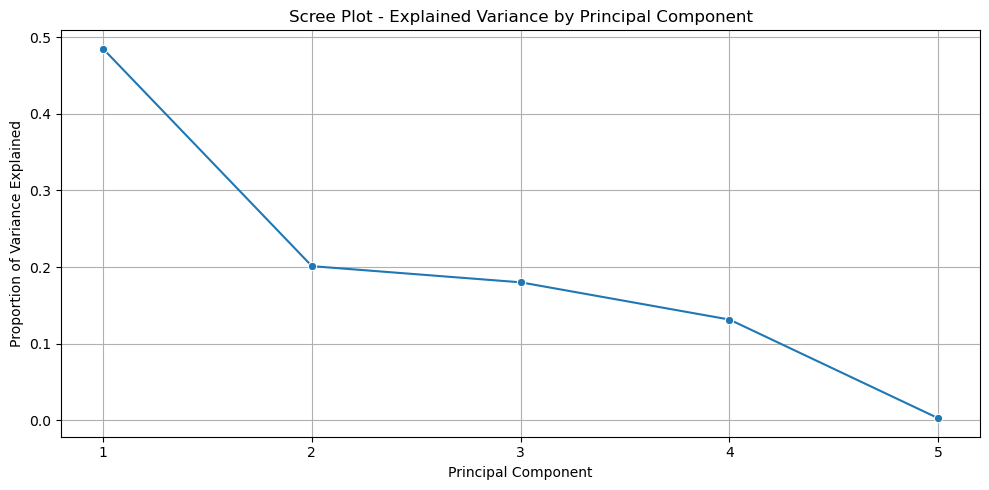

In [403]:
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.lineplot(
    x=range(1, len(pca_full.explained_variance_ratio_) + 1),
    y=pca_full.explained_variance_ratio_,
    marker="o"
)
plt.title("Scree Plot - Explained Variance by Principal Component")
plt.xlabel("Principal Component")
plt.ylabel("Proportion of Variance Explained")
plt.xticks(range(1, len(pca_full.explained_variance_ratio_) + 1))
plt.grid(True)
plt.tight_layout()
plt.show()

#### A whole lot of testing

In [302]:
# mainDirect5.to_pickle("Main_Direct_Testing.pkl")

In [303]:
# dd = mainDirect5.copy()
# print("Before Mining")

# total_rows = len(dd)
# print(f"Total number of rows: {total_rows}")

# empty_brief_profiles = dd[~(dd['Brief Profile'] == "nan")]['Brief Profile'].fillna('').str.strip().eq('').sum()
# print(f"Number of empty Brief Profiles: { len(dd[(dd['Brief Profile'] == 'nan')]) + empty_brief_profiles}")

# empty_skills = dd[~(dd['Skills/Competencies'] == "nan")]['Skills/Competencies'].apply(
#     lambda x: (isinstance(x, list) and len(x) == 0) or (not isinstance(x, list) and pd.isna(x))
# ).sum()
# print(f"Number of empty Skills/Competencies: {len(dd[(dd['Skills/Competencies'] == 'nan')]) + empty_skills}")

# empty_brief_profile_flag = (dd['Brief Profile'].fillna('').replace("nan", " ").str.strip().eq(''))
# empty_skills_flag = dd['Skills/Competencies'].replace("nan", pd.NA).apply(
#     lambda x: (isinstance(x, list) and len(x) == 0) or (not isinstance(x, list) and pd.isna(x)) or (not isinstance(x, str) and pd.isna(x))
# )

# intersection_count = (empty_brief_profile_flag & empty_skills_flag).sum()
# print(f"Number of directors with BOTH empty Brief Profile and empty Skills/Competencies: {intersection_count}")

In [304]:
# import pandas as pd
# import ast

# skill_list = [
#     'economics', 'marketing', 'fast moving consumer goods', 'accounts/audit/taxation',
#     'human resources', 'healthcare', 'public policy', 'corporate social responsibility',
#     'finance', 'services', 'legal/compliance', 'information technology',
#     'corporate governance', 'telecommunication', 'research & development', 'strategy',
#     'financial services', 'risk management', 'diversified', 'supply chain management',
#     'leadership/management', 'international business', 'diversity', 'consumer discretionary',
#     'commodities', 'personal values', 'utilities', 'energy', 'operations', 'industrials'
# ]

# skill_list_lower = [skill.lower().strip() for skill in skill_list]

# def extract_skills(text):
#     if text is None or (isinstance(text, float) and pd.isna(text)):
#         return []
#     text = str(text).lower().strip()
#     return [skill for skill in skill_list_lower if skill in text]

# def combine_skills(existing_skills, *fields):
#     if isinstance(existing_skills, float) and pd.isna(existing_skills):
#         existing_skills = []
#     elif isinstance(existing_skills, str) and existing_skills != "nan":
#         try:
#             existing_skills = ast.literal_eval(existing_skills)
#             if not isinstance(existing_skills, list):
#                 existing_skills = existing_skills.lower().strip().split(",")
#         except:
#             if not isinstance(existing_skills, list):
#                 existing_skills = existing_skills.lower().strip().split(",")
#             else:
#                 existing_skills = []
#     elif not isinstance(existing_skills, list):
#         existing_skills = []
        
#     new_skills = []
#     for field in fields:
#         new_skills.extend(extract_skills(field))
    
#     combined = existing_skills + [skill for skill in new_skills if skill not in existing_skills]
#     return combined

# for col in ['Brief Profile', 'Occupation', 'Position on Board']:
#     dd[col] = dd[col].fillna('').astype(str).str.lower().str.strip()

# dd['Skills/Competencies_'] = dd.apply(
#     lambda row: combine_skills(
#         row['Skills/Competencies'],
#         row['Brief Profile'],
#         row['Occupation'],
#         row['Position on Board']
#     ), axis=1)

In [305]:
# empty_skills = dd[~(dd['Skills/Competencies'] == "nan")]['Skills/Competencies'].apply(
#     lambda x: (isinstance(x, list) and len(x) == 0) or (not isinstance(x, list) and pd.isna(x))
# ).sum()
# print(f"Number of empty Skills/Competencies: {len(dd[(dd['Skills/Competencies'] == 'nan')]) + empty_skills}")

# empty_skills = dd['Skills/Competencies_'].apply(
#     lambda x: (isinstance(x, list) and len(x) == 0) or (not isinstance(x, list) and pd.isna(x))
# ).sum()
# print(f"Number of empty Skills/Competencies_: {empty_skills}")


In [306]:
# empty_skills = mainDirect5[~(mainDirect5['Skills/Competencies'] == "nan")]['Skills/Competencies'].apply(
#     lambda x: (isinstance(x, list) and len(x) == 0) or (not isinstance(x, list) and pd.isna(x))
# ).sum()
# print(f"Number of empty Skills/Competencies: {len(mainDirect5[(mainDirect5['Skills/Competencies'] == 'nan')]) + empty_skills}")

# empty_skills = mainDirect5['AllSkills'].apply(
#     lambda x: (isinstance(x, set) and len(x) == 0) or (not isinstance(x, set) and pd.isna(x))
# ).sum()
# print(f"Number of empty AllSkills: {empty_skills}")


In [307]:
# import pandas as pd

# df = mainDirect5.copy()
# skill_list = [
#     'economics', 'marketing', 'fast moving consumer goods', 'accounts/audit/taxation',
#     'human resources', 'healthcare', 'public policy', 'corporate social responsibility',
#     'finance', 'services', 'legal/compliance', 'information technology',
#     'corporate governance', 'telecommunication', 'research & development', 'strategy',
#     'financial services', 'risk management', 'diversified', 'supply chain management',
#     'leadership/management', 'international business', 'diversity', 'consumer discretionary',
#     'commodities', 'personal values', 'utilities', 'energy', 'operations', 'industrials'
# ]

# skill_list_lower = [s.lower().strip() for s in skill_list]

# def extract_skills(profile):
#     if not isinstance(profile, str) or pd.isna(profile):
#         return []
#     profile = profile.lower().strip().split(",")
#     return [skill
#             for skill in skill_list_lower
#             for profile_sub in profile
#             if (skill in profile_sub) or (skill == profile_sub) ]


# def combine_skills(existing_skills, *fields):
#     if not isinstance(existing_skills, list):
#         existing_skills = []
#     new_skills = []
#     for field in fields:
#         new_skills.extend(extract_skills(field))
#     return list(set(existing_skills + new_skills))

# df['Skills/Competencies-'] = df.apply(
#     lambda row: combine_skills(extract_skills(row['Skills/Competencies']), row['Brief Profile'], row['Occupation'], row['Position on Board']),
#     axis=1
# )

# df['Skills/Competencies-'] = df['Skills/Competencies-'].apply(
#     lambda x: x if isinstance(x, list) else []
# )

# num_empty_skills = df['Skills/Competencies-'].apply(
#     lambda x: len(x) == 0
# ).sum()

# print(f"Number of empty Skills/Competencies (NaN or empty list): {num_empty_skills}")


In [308]:
# mainDirect5["AllSkills"].apply(bool).value_counts() # verified!

In [309]:
# mainDirect5["HasRelatedIndustryXP"].value_counts()

---

---

---

---

In [310]:
mainDirect6 = mainDirect5.copy()
mainDirect6 = mainDirect6.loc[ ~((mainDirect6["govtdummy"] == 1) | (mainDirect6["findummy"] == 1) | (mainDirect6["AsOnYear"] <= 2012)) ].copy().reset_index(drop = True)

In [311]:
mainDirect6['Academic'] = mainDirect6['IsPhD'].copy()
mainDirect6['Outside Board'] = mainDirect6['CompCountOtherPastTotalAB'].apply(lambda x: 1 if x > 0 else 0)
mainDirect6["Company Business"] = mainDirect6["HasRelatedIndustryXP"].copy()

---

In [312]:
# if skills keywords map exists in allskills

mainDirect6["AllSkills"] = mainDirect6["AllSkills"].astype("string").fillna("").str.lower()

skillset_keywords_map = {
    "sustainability": [
        "sustainability", "sustainable", "csr", "corporate social responsibility",
        "sustainability committee", "esg committee", "csr committee",
        "corporate social responsibility committee", "environment committee", "energy"
    ],
    "entrepreneurial": [
        "entrepreneur", "entrepreneurship", "startup", "founder", "co-founder",
        "innovation", "innovator", "venture", "investor"
    ],
    "compensation": [
        "compensation committee", "remuneration committee", "pay committee", "salary committee",
        "executive compensation", "incentive committee", "reward committee",
        "compensation and benefits", "compensation policy", "remuneration policy",
        "compensation", "salary", "remuneration", "pay", "bonus", "incentive",
        "performance bonus", "employee benefits", "wages", "rewards"
    ],
    "conglomerate_experience": [
        "conglomerate", "diversified group", "group company", "holding company",
        "multiple sectors", "business group", "corporate group", "inter-industry",
        "multi-industry", "parent-subsidiary structure", "group-wide strategy"
    ],
    "hr": [
        "human resources committee", "hr", "people management", "talent management",
        "organizational development", "performance management", "employee relations",
        "hr strategy", "compensation and benefits", "workforce planning",
        "succession planning", "human resource committee", "hr committee",
        "people committee", "talent committee", "organizational development committee",
        "compensation and benefits committee", "employee relations committee",
        "workforce planning committee", "succession planning committee",
        "diversities", "personal values"
    ],
    "technology": [
        "technology", "information technology", "it", "software engineering", "hardware", 
        "computer science", "tech", "digital transformation", "data science", "machine learning", 
        "ai", "artificial intelligence", "cybersecurity", "cloud computing", "systems architecture", 
        "technology strategy", "data analytics", "blockchain", "innovation", "info tech","telecommunication"
    ],
    "finance_accounting": [
        "finance", "financial", "accounting", "accounts", "chartered accountant", 
        "ca", "cfo", "chief financial officer", "auditor", "audit", "financial analysis", 
        "capital markets", "treasury", "banking", "investment", "equity", "debt", 
        "risk management", "taxation", "budgeting", "forecasting", "valuation", 
        "financial planning", "cost control", "internal controls", "compliance", 
        "financial reporting", "economics", "financial services", "commodities",
    ],
    "governance": [
        "governance", "corporate governance", "governance committee", "audit committee", 
        "risk committee", "ethics committee", "compliance committee", "board governance", 
        "regulatory affairs", "internal controls", "oversight", "governance and compliance", 
        "governance practices", "governance framework", "governance structure", 
        "governance responsibilities"
    ],
    "government_policy": [
        "government", "policy", "government affairs", "public policy", "government relations", 
        "legislative affairs", "policy making", "public sector", "regulations", 
        "government strategy", "public administration", "government services", 
        "policy development", "political affairs", "utilities"
    ],
    "international": [
        "international", "global", "international relations", "cross-border", "foreign affairs", 
        "multinational", "overseas", "global strategy", "global expansion", 
        "international business", "cross-cultural", "international markets", 
        "global trade", "global governance"
    ],
    "leadership": [
        "leadership", "executive leadership", "team leadership", "leadership development", 
        "strategic leadership", "leadership skills", "leadership team", 
        "senior leadership", "leadership strategy", "leadership responsibilities", 
        "visionary leadership", "leadership roles", "leadership training", 
        "leadership capabilities", "leadership and management", "senior management"
    ],
    "legal": [
        "legal", "legal affairs", "legal compliance", "legal counsel", "corporate legal", 
        "legal strategy", "legal advisor", "contract law", "intellectual property", 
        "regulatory compliance", "litigation", "legal framework", "lawsuit", 
        "legal governance", "legal risk", "compliance"
    ],
    "marketing": [
        "marketing", "marketing strategy", "digital marketing", "marketing campaign", 
        "marketing communications", "brand management", "customer engagement", 
        "marketing research", "social media marketing", "advertising", 
        "marketing manager", "market research", "content marketing", 
        "product marketing", "marketing analysis", "markets", 
        "fast moving consumer goods", "fmcg", "services", "consumer differentiation","consumer discretionary"
    ],
    "risk_management": [
        "risk management", "risk mitigation", "risk assessment", "risk committee", 
        "operational risk", "financial risk", "strategic risk", "compliance risk", 
        "risk control", "enterprise risk management", "risk governance", 
        "risk monitoring", "risk management strategy", "risk management framework", 
        "risk prevention"
    ],
    "scientific": [
        "scientific", "research and development", "r&d", "innovation", 
        "scientific research", "scientific committee", "technology research", 
        "science strategy", "scientific discovery", "scientific innovation", 
        "scientific analysis", "biotech", "scientific approach", "lab research", 
        "clinical research", "healthcare"
    ],
    "strategic_planning": [
        "strategic planning", "strategic development", "strategic initiatives", 
        "business strategy", "strategic goals", "long-term planning", 
        "corporate strategy", "strategic management", "strategic vision", 
        "strategic objectives", "strategy formulation", "strategic direction", 
        "strategic partnerships", "business planning", "strategic forecasting", 
        "strategy"
    ],
    "manufacturing_supply_chain": [
        "manufacturing", "production", "operations", "supply chain", "factory",
        "industrial", "plant", "manufacturing unit", "process engineering",
        "assembly line", "lean manufacturing", "six sigma", "quality control",
        "industrial engineering", "materials management", "shop floor",
        "production planning", "logistics", "automation", "mechanical engineering",
        "process optimization", "machinery", "manufacturing strategy",
        "supply chain management", "engineering operations",
        "operational management", "project management"
    ]
}


for col, keywords in skillset_keywords_map.items():
    skilllist_col = f"skilllist_{col}"
    mainDirect6[skilllist_col] = mainDirect6["AllSkills"].apply(
        lambda x: int(any(kw in str(x) for kw in keywords)))
    
    mainDirect6[skilllist_col] = mainDirect6.groupby(["Person Code", "AsOnDate"])[skilllist_col].transform('any')
    mainDirect6[skilllist_col] = mainDirect6.groupby("Person Code")[skilllist_col].ffill()


In [313]:
mainDirect6

,Symbol,Company,AsOnDate,AsOnYear,ISIN,Person Code,Director Salutation,Director First Name,Director Middle Name,Director Surname,Date of Birth,Gender,Nationality,Member of Civil Services,Promoter Director (Yes/No),Position on Board,Independent (Yes/No),Education1,Education2,Education3,Education4,Education5,Education6,Education7,Education8,Education9,Education10,Skills/Competencies,Occupation,Cessation Reason,Other Directorship 1,Other Directorship 2,Other Directorship 3,Other Directorship 4,Other Directorship 5,Other Directorship 6,Other Directorship 7,Other Directorship 8,Other Directorship 9,Other Directorship 10,Other Directorship 11,Other Directorship 12,Other Directorship 13,Other Directorship 14,Other Directorship 15,Brief Profile,Tenure Valid till,Date of Demise,Indep,Appointment Date,Cessation Date,PrevLastServed,NextServed,CessationDummy,ReappointDummy,TermStartDummy,TermNumber,AppointDummy,CumOpBalUnc,CumOpBalIndep,CumOpBalNonIndep,CumCloBalUnc,CumCloBalIndep,CumCloBalNonIndep,TermOpBalUnc,TermOpBalIndep,TermOpBalNonIndep,TermOpBalTotal,TermCloBalUnc,TermCloBalIndep,TermCloBalNonIndep,TermCloBalTotal,CompOpBalUnc,CompOpBalIndep,CompOpBalNonIndep,CompOpBalTotal,CompCloBalUnc,CompCloBalIndep,CompCloBalNonIndep,CompCloBalTotal,CloBalTotalXP,AllPastDirect,CurrDirectA,CurrDirectAB,PastSiezedDirectA,PastSiezedDirectAB,CountOtherPastUnclearA,CountOtherPastIndepA,CountOtherPastNonIndepA,CompCountOtherPastTotalA,CountOtherPastUnclearAB,CountOtherPastIndepAB,CountOtherPastNonIndepAB,CompCountOtherPastTotalAB,CountCurrUnclearA,CountCurrIndepA,CountCurrNonIndepA,CompCountCurrTotalA,CountCurrUnclearAB,CountCurrIndepAB,CountCurrNonIndepAB,CompCountCurrTotalAB,Rookie,IsIndep,IsNonIndep,IsRookie,IsNonRookie,IsCeoMDPosition,IsChairmanPosition,IsCeoMDOccupation,IsChairmanOccupation,IsCeoMD,IsChairman,IsPromoterClassification,IsPromoterBoard,IsPromoter,IsDualityChairmanMD,IsFamilyManager,IsFamilyChairman,IsFamilyChairmanAndCEO,IsRookieIndep,IsRookieNonIndep,IsNonRookieIndep,IsNonRookieNonIndep,IsFemale,Age,TenureInYearsinCompIndep,TenureInYearsinCompTotal,TenureInYearsTotal,IsFirstTerm,IsFirstTermIndep,IsZeroYear,IsZeroYearIndep,IsOneYear,IsOneYearIndep,IsTwoYear,IsTwoYearIndep,IsThreeYear,IsThreeYearIndep,IsRetires5y,IsTermLimitRetirement,IsDefaultTerm,IsBusy,IsTurnOver,HasRetires5y,HasTermLimitRetirement,IsTurnOverIndep,NSE symbol,NIC code,Entity type,Ownership group,Ownership group code,Prowess company code,Company Name,govtdummy,findummy,Skills,EducationAll,IsMBA,IsPhD,AllPastDirectNIC,CurrDirectANIC,CurrDirectABNIC,AllNIC,AllPastDirectNIC_2Digit,AllNIC_Industry,HasFinanceXP,HasTechXP,HasRelatedIndustryXP,IsExecCurrent,NumExecAll,IsOutsideExecXP,HasExecXP,PublicExecXPDummy,PrivateExecXPDummy,HasPublicExecXP,HasPrivateExecXP,SkillsInPositiononBoard,SkillsInOccupation,SkillsInBriefProfile,AllSkills,HasTechSkill,HasFinanceSkill,FirmsPast,NumSkills_gai,NumFirmsPast,NumIndustryPast,HasCeoMDChairXP,HasConglomerateXP,Academic,Outside Board,Company Business,skilllist_sustainability,skilllist_entrepreneurial,skilllist_compensation,skilllist_conglomerate_experience,skilllist_hr,skilllist_technology,skilllist_finance_accounting,skilllist_governance,skilllist_government_policy,skilllist_international,skilllist_leadership,skilllist_legal,skilllist_marketing,skilllist_risk_management,skilllist_scientific,skilllist_strategic_planning,skilllist_manufacturing_supply_chain
0,20MICRONS,20 MICRONS LTD.,2013-03-31,2013,INE144J01027,P00027633,MR.,RAMKISHAN,AMIRCHAND,DEVIDAYAL,1950-12-08,M,INDIA,NONE,NO,NON-EXECUTIVE DIRECTOR,YES,POST GRADUATE: M.B.A.,"POST GRADUATE: M.COM.,MAHARAJA SAYAJIRAO UNIVE...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"ACCOUNTS/AUDIT/TAXATION,CONSUMER DISCRETIONARY...",<NA>,<NA>,20 MICRONS LTD.,BANCO PRODUCTS (INDIA) LTD.,MUNJAL AUTO INDUSTRIES LTD.,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,MR.RAM DEVIDAYAL HAS A MASTER'S DEGREE IN COMM...,NaT,NaT,Y,2007-10-13,NaT,2012-03-31,2014-03-31,0,0.0,0.0,1.0,0,0.0,0.0,0.0,0.0,365

In [314]:
def extract_manufacturing(nic_code):
    if pd.isnull(nic_code) or str(nic_code).strip() == '':
        return 0
    try:
        nic_str = str(int(float(nic_code))).zfill(2) 
        nic2 = int(nic_str[:2]) 
        return 1 if 10 <= nic2 <= 33 else 0 
    except:
        return 0
mainDirect6['Manufacturing_NIC_not used'] = mainDirect6['NIC code'].progress_apply(extract_manufacturing)

100%|██████████████████████████████████████████████████████████████████████| 149804/149804 [00:00<00:00, 454897.49it/s]


## Committees and Brief Profile skillset parse

In [315]:
mainComm = pd.read_pickle(rf"{input_folder_path}\Main_Committees_incl Cess.pkl")

In [316]:
mainComm["Committee Name"] = mainComm["Committee Name"].astype("string").fillna("").str.lower()
mainComm["Position"] = mainComm["Position"].astype("string").fillna("").str.lower()
mainComm["Committee_position"] = list(zip(mainComm["Committee Name"], mainComm["Position"]))

In [317]:
all_committee_position = mainComm.groupby(
    ["Person Code", "Symbol", "AsOnDate"])["Committee_position"].agg(list).reset_index()

all_committee = mainComm.groupby(
    ["Person Code", "Symbol", "AsOnDate"])["Committee Name"].agg(list).reset_index()

In [318]:
keyword_categories = {
    "sustainability": [
        "sustainability", "sustainable", "csr", "corporate social responsibility",
        "sustainability committee", "esg committee", "csr committee",
        "corporate social responsibility committee", "environment committee", "energy"
    ],
    "entrepreneurial": [
        "entrepreneur", "entrepreneurship", "startup", "founder", "co-founder",
        "innovation", "innovator", "venture", "investor"
    ],
    "compensation": [
        "compensation committee", "remuneration committee", "pay committee", "salary committee",
        "executive compensation", "incentive committee", "reward committee",
        "compensation and benefits", "compensation policy", "remuneration policy",
        "compensation", "salary", "remuneration", "pay", "bonus", "incentive",
        "performance bonus", "employee benefits", "wages", "rewards"
    ],
    "conglomerate_experience": [
        "conglomerate", "diversified group", "group company", "holding company",
        "multiple sectors", "business group", "corporate group", "inter-industry",
        "multi-industry", "parent-subsidiary structure", "group-wide strategy"
    ],
    "hr": [
        "human resources committee", "hr", "people management", "talent management",
        "organizational development", "performance management", "employee relations",
        "hr strategy", "compensation and benefits", "workforce planning",
        "succession planning", "human resource committee", "hr committee",
        "people committee", "talent committee", "organizational development committee",
        "compensation and benefits committee", "employee relations committee",
        "workforce planning committee", "succession planning committee",
        "diversities", "personal values"
    ],
    "technology": [
        "technology", "information technology", "it", "software engineering", "hardware", 
        "computer science", "tech", "digital transformation", "data science", "machine learning", 
        "ai", "artificial intelligence", "cybersecurity", "cloud computing", "systems architecture", 
        "technology strategy", "data analytics", "blockchain", "innovation", "info tech","telecommunication"
    ],
    "finance_accounting": [
        "finance", "financial", "accounting", "accounts", "chartered accountant", 
        "ca", "cfo", "chief financial officer", "auditor", "audit", "financial analysis", 
        "capital markets", "treasury", "banking", "investment", "equity", "debt", 
        "risk management", "taxation", "budgeting", "forecasting", "valuation", 
        "financial planning", "cost control", "internal controls", "compliance", 
        "financial reporting", "economics", "financial services", "commodities",
    ],
    "governance": [
        "governance", "corporate governance", "governance committee", "audit committee", 
        "risk committee", "ethics committee", "compliance committee", "board governance", 
        "regulatory affairs", "internal controls", "oversight", "governance and compliance", 
        "governance practices", "governance framework", "governance structure", 
        "governance responsibilities"
    ],
    "government_policy": [
        "government", "policy", "government affairs", "public policy", "government relations", 
        "legislative affairs", "policy making", "public sector", "regulations", 
        "government strategy", "public administration", "government services", 
        "policy development", "political affairs", "utilities"
    ],
    "international": [
        "international", "global", "international relations", "cross-border", "foreign affairs", 
        "multinational", "overseas", "global strategy", "global expansion", 
        "international business", "cross-cultural", "international markets", 
        "global trade", "global governance"
    ],
    "leadership": [
        "leadership", "executive leadership", "team leadership", "leadership development", 
        "strategic leadership", "leadership skills", "leadership team", 
        "senior leadership", "leadership strategy", "leadership responsibilities", 
        "visionary leadership", "leadership roles", "leadership training", 
        "leadership capabilities", "leadership and management", "senior management"
    ],
    "legal": [
        "legal", "legal affairs", "legal compliance", "legal counsel", "corporate legal", 
        "legal strategy", "legal advisor", "contract law", "intellectual property", 
        "regulatory compliance", "litigation", "legal framework", "lawsuit", 
        "legal governance", "legal risk", "compliance"
    ],
    "marketing": [
        "marketing", "marketing strategy", "digital marketing", "marketing campaign", 
        "marketing communications", "brand management", "customer engagement", 
        "marketing research", "social media marketing", "advertising", 
        "marketing manager", "market research", "content marketing", 
        "product marketing", "marketing analysis", "markets", 
        "fast moving consumer goods", "fmcg", "services", "consumer differentiation","consumer discretionary"
    ],
    "risk_management": [
        "risk management", "risk mitigation", "risk assessment", "risk committee", 
        "operational risk", "financial risk", "strategic risk", "compliance risk", 
        "risk control", "enterprise risk management", "risk governance", 
        "risk monitoring", "risk management strategy", "risk management framework", 
        "risk prevention"
    ],
    "scientific": [
        "scientific", "research and development", "r&d", "innovation", 
        "scientific research", "scientific committee", "technology research", 
        "science strategy", "scientific discovery", "scientific innovation", 
        "scientific analysis", "biotech", "scientific approach", "lab research", 
        "clinical research", "healthcare"
    ],
    "strategic_planning": [
        "strategic planning", "strategic development", "strategic initiatives", 
        "business strategy", "strategic goals", "long-term planning", 
        "corporate strategy", "strategic management", "strategic vision", 
        "strategic objectives", "strategy formulation", "strategic direction", 
        "strategic partnerships", "business planning", "strategic forecasting", 
        "strategy"
    ],
    "manufacturing_supply_chain": [
        "manufacturing", "production", "operations", "supply chain", "factory",
        "industrial", "plant", "manufacturing unit", "process engineering",
        "assembly line", "lean manufacturing", "six sigma", "quality control",
        "industrial engineering", "materials management", "shop floor",
        "production planning", "logistics", "automation", "mechanical engineering",
        "process optimization", "machinery", "manufacturing strategy",
        "supply chain management", "engineering operations",
        "operational management", "project management"
    ]
}


keyword_categories = {
    category.lower(): [kw.lower() for kw in keywords]
    for category, keywords in keyword_categories.items()
}

for category, keywords in keyword_categories.items():
    col_name = f"committee_{category}"
    all_committee[col_name] = all_committee['Committee Name'].apply(
        lambda names: int(any(
            keyword in name.lower().strip()
            for name in names
            for keyword in keywords
        )) if isinstance(names,list) else 0
    )


for category, keywords in keyword_categories.items():
    col_name = f"profile_{category}"
    mainDirect6[col_name] = mainDirect6['Brief Profile'].astype("string").fillna("").str.lower().apply(
        lambda x: int(any(keyword in x for keyword in keywords))
    )

mainDirect7 = mainDirect6.merge(
    all_committee,
    on=['Symbol', 'Person Code', 'AsOnDate'],
    how='left'
)

for category in keyword_categories.keys():
    committee_col = f"committee_{category}"
    profile_col = f"profile_{category}"
    mainDirect7[committee_col] = mainDirect7[committee_col].fillna(0).astype(int)
    mainDirect7[profile_col] = mainDirect7[profile_col].fillna(0).astype(int)
    
    mainDirect7[committee_col] = mainDirect7.groupby(["Person Code", "AsOnDate"])[committee_col].transform('any')
    mainDirect7[profile_col] = mainDirect7.groupby(["Person Code", "AsOnDate"])[profile_col].transform('any')
    
    mainDirect7[committee_col] = mainDirect7.groupby("Person Code")[committee_col].ffill()
    mainDirect7[profile_col] = mainDirect7.groupby("Person Code")[profile_col].ffill()
    


for category in keyword_categories.keys():
    skilllist_col = f"skilllist_{category}"
    committee_col = f"committee_{category}"
    profile_col = f"profile_{category}"
    
    combined_col = f"combined_{category}"
    
    mainDirect7[combined_col] = mainDirect7[[skilllist_col, committee_col, profile_col]].max(axis=1)

In [319]:
# combined_skillsets_list = ["Academic",
#  "Company Business",
#  "combined_sustainability",
#  "combined_entrepreneurial",
#  "combined_compensation",
#  "combined_conglomerate_experience",
#  "combined_hr",
#  "combined_technology",
#  "combined_finance_accounting",
#  "combined_governance",
#  "combined_government_policy",
#  "combined_international",
#  "combined_leadership",
#  "combined_legal",
#  "combined_marketing",
#  "combined_risk_management",
#  "combined_scientific",
#  "combined_strategic_planning",
#  "combined_manufacturing_supply_chain"]

# mainDirect7["combined_manufacturing_supply_chain"] = (mainDirect7["combined_manufacturing_supply_chain"]).astype(int)
# mainDirect7["combined_leadership_outside_board"] = (mainDirect7["combined_leadership"] | mainDirect7["Outside Board"]).astype(int)

# mainDirect7["NumSkills_dummies"] = mainDirect7[combined_skillsets_list].sum(axis =1)

# mainDirect7['combined_technology'] = mainDirect7['combined_technology'].fillna(0).astype(int)
# mainDirect7['HasTechXP'] = mainDirect7['HasTechXP'].fillna(0).astype(int)

# mainDirect7['combined_technology'] = mainDirect7.apply(
#     lambda row: 1 if (row['combined_technology'] == 1 or row['HasTechXP'] == 1) else 0,
#     axis=1
# )
# mainDirect7['combined_finance_accounting'] = mainDirect7['combined_finance_accounting'].fillna(0).astype(int)
# mainDirect7['HasFinanceXP'] = mainDirect7['HasFinanceXP'].fillna(0).astype(int)
# mainDirect7['combined_finance_accounting'] = mainDirect7.apply(
#     lambda row: 1 if (row['combined_finance_accounting'] == 1 or row['HasFinanceXP'] == 1) else 0,
#     axis=1
# )

In [320]:
for col in mainDirect7.columns:
    if col.startswith("combined") :
        value_counts = mainDirect7[col].value_counts(dropna=False)
        print(f"Column: {col}")
        print(f"  1s: {value_counts.get(1, 0)}")
        print(f"  0s: {value_counts.get(0, 0)}")
        print()

Column: combined_sustainability
  1s: 65050
  0s: 84754

Column: combined_entrepreneurial
  1s: 60059
  0s: 89745

Column: combined_compensation
  1s: 54976
  0s: 94828

Column: combined_conglomerate_experience
  1s: 4799
  0s: 145005

Column: combined_hr
  1s: 68878
  0s: 80926

Column: combined_technology
  1s: 8282
  0s: 141522

Column: combined_finance_accounting
  1s: 12614
  0s: 137190

Column: combined_governance
  1s: 47417
  0s: 102387

Column: combined_government_policy
  1s: 48684
  0s: 101120

Column: combined_international
  1s: 62386
  0s: 87418

Column: combined_leadership
  1s: 47120
  0s: 102684

Column: combined_legal
  1s: 73558
  0s: 76246

Column: combined_marketing
  1s: 54350
  0s: 95454

Column: combined_risk_management
  1s: 70858
  0s: 78946

Column: combined_scientific
  1s: 18463
  0s: 131341

Column: combined_strategic_planning
  1s: 60373
  0s: 89431

Column: combined_manufacturing_supply_chain
  1s: 59950
  0s: 89854



C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_26020\559375703.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"  1s: {value_counts.get(1, 0)}")
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_26020\559375703.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"  0s: {value_counts.get(0, 0)}")


In [321]:
mainDirect7.columns

Index(['Symbol', 'Company', 'AsOnDate', 'AsOnYear', 'ISIN', 'Person Code',
       'Director Salutation', 'Director First Name', 'Director Middle Name',
       'Director Surname',
       ...
       'combined_governance', 'combined_government_policy',
       'combined_international', 'combined_leadership', 'combined_legal',
       'combined_marketing', 'combined_risk_management', 'combined_scientific',
       'combined_strategic_planning', 'combined_manufacturing_supply_chain'],
      dtype='object', length=262)

In [322]:
req_cols0 = [x for x in mainDirect7.columns if x.startswith("combined")]

exempt_cols = ["Academic", "combined_scientific", "combined_conglomerate", 
               "Company Business"]

req_cols = [x for x in req_cols0 if x not in exempt_cols]

In [323]:
pcaData = mainDirect7[req_cols + ["Person Code", "Symbol", "AsOnDate"] ].copy().set_index(["Person Code", "Symbol", "AsOnDate"], drop = True)
pcaData
pcaData["NumSkills"] = pcaData[req_cols].fillna(0).sum(axis = 1)

pcaData = pcaData.loc[~ (pcaData["NumSkills"] == 0)].copy()
pcaData.drop(["NumSkills"], axis = 1, inplace = True)

In [324]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

scaled_data = preprocessing.scale(pcaData)

pca_full = PCA()
pca_data_full = pca_full.fit_transform(scaled_data)

# eigenvalues = pca.explained_variance_
# eigenvectors = pca.components_

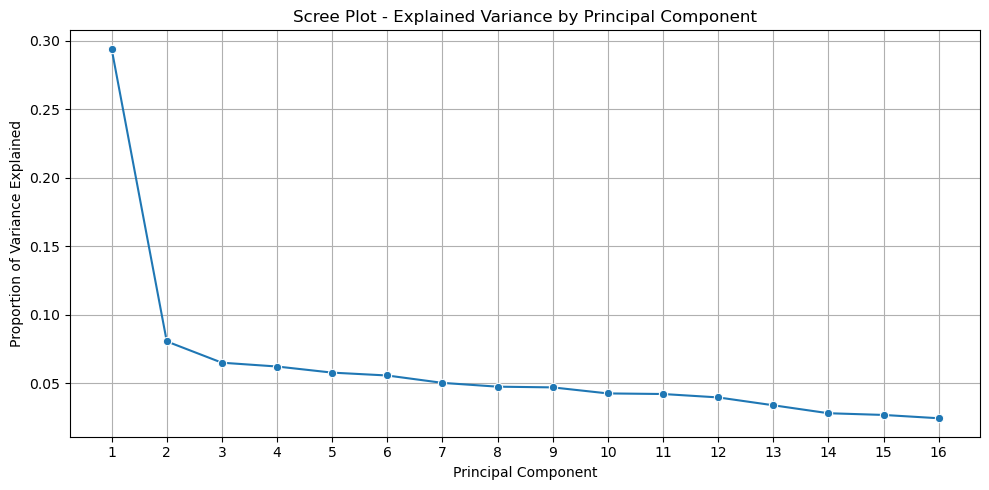

In [325]:
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.lineplot(
    x=range(1, len(pca_full.explained_variance_ratio_) + 1),
    y=pca_full.explained_variance_ratio_,
    marker="o"
)
plt.title("Scree Plot - Explained Variance by Principal Component")
plt.xlabel("Principal Component")
plt.ylabel("Proportion of Variance Explained")
plt.xticks(range(1, len(pca_full.explained_variance_ratio_) + 1))
plt.grid(True)
plt.tight_layout()
plt.show()

In [326]:
scaled_data = preprocessing.scale(pcaData)

pca = PCA(n_components=1)
pca_data = pca.fit_transform(scaled_data)

# mainDirect['SkillsetIndex'] = pca_data[:, 0]
# mainDirect['SkillsetIndex'] = (mainDirect['SkillsetIndex'] - mainDirect['SkillsetIndex'].mean()) / mainDirect['SkillsetIndex'].std()

# median_value = mainDirect['SkillsetIndex'].median()
# mainDirect['SkillsetGeneralistDummy'] = (mainDirect['SkillsetIndex'] > median_value).astype(int)

loadings = pd.DataFrame(
    pca_full.components_.T,
    columns=[f'PC{i+1}' for i in range(len(pcaData.columns))],
    index=pcaData.columns
)

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_26020\1286668978.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='PC1', y='Skillset Feature', data=pc1_sorted, palette='coolwarm')


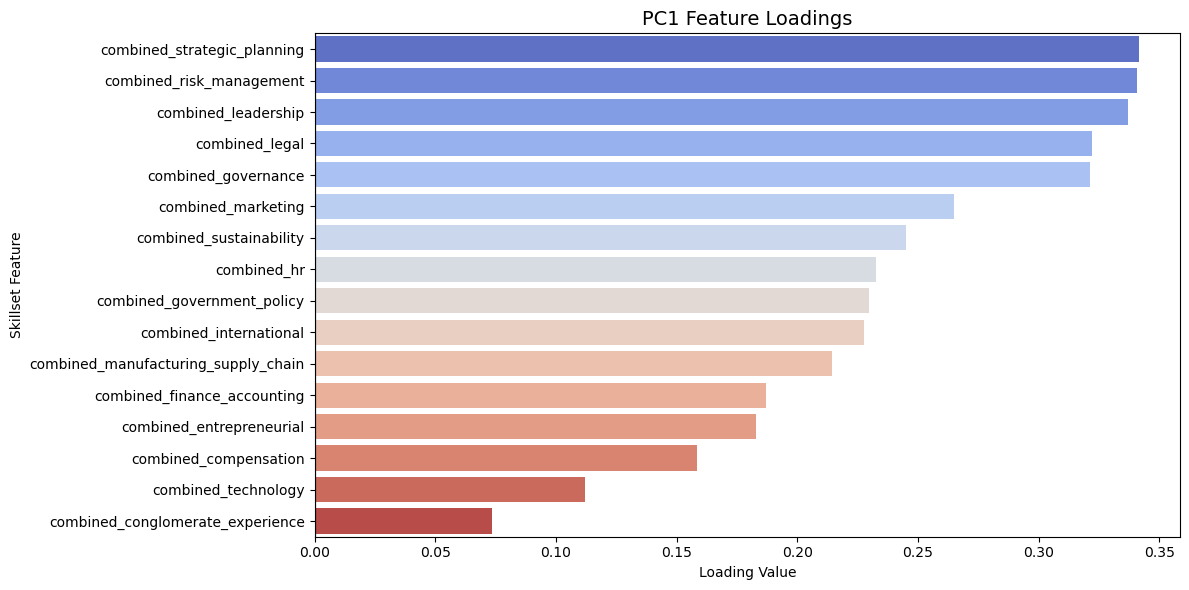

In [327]:
pc1_loadings = loadings[['PC1']].copy()
pc1_loadings['Skillset Feature'] = pc1_loadings.index
pc1_sorted = pc1_loadings.sort_values('PC1', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='PC1', y='Skillset Feature', data=pc1_sorted, palette='coolwarm')
plt.title('PC1 Feature Loadings', fontsize=14)
plt.xlabel('Loading Value')
plt.ylabel('Skillset Feature')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [328]:
print(f"Eigenvalue for PC1: {pca.explained_variance_[0]:.3f}")
print(f"Explained Variance Ratio for PC1: {pca.explained_variance_ratio_[0]*100:.3f}%")

loadings_output = loadings["PC1"].sort_values()
print("Top PC1 Loadings for ALL data from 2013:\n")
for index, loading in list(zip(loadings_output.index, loadings_output.values)):
    print(f"{index:<40} {loading:.3f}")

Eigenvalue for PC1: 4.706
Explained Variance Ratio for PC1: 29.414%
Top PC1 Loadings for ALL data from 2013:

combined_conglomerate_experience         0.074
combined_technology                      0.112
combined_compensation                    0.159
combined_entrepreneurial                 0.183
combined_finance_accounting              0.187
combined_manufacturing_supply_chain      0.214
combined_international                   0.228
combined_government_policy               0.230
combined_hr                              0.233
combined_sustainability                  0.245
combined_marketing                       0.265
combined_governance                      0.321
combined_legal                           0.322
combined_leadership                      0.337
combined_risk_management                 0.341
combined_strategic_planning              0.341


In [329]:
pca_full.explained_variance_

array([4.70620187, 1.29058565, 1.04219105, 0.99774665, 0.92635607,
       0.89283788, 0.80673075, 0.76233702, 0.7540568 , 0.68355602,
       0.67669966, 0.63700858, 0.54534294, 0.45231881, 0.43239263,
       0.39374844])

In [330]:
eigenvalues = pca_full.explained_variance_
eigenvalues_gt1 = eigenvalues[eigenvalues > 1]
sum_eigenvalues_gt1 = eigenvalues_gt1.sum()
explained_variance_ratios = pca_full.explained_variance_ratio_
explained_variance_gt1 = explained_variance_ratios

sum_explained_variance_gt1 = explained_variance_gt1.sum()

print(f"Number of components with eigenvalue > 1: {len(eigenvalues_gt1)}")
print(f"Sum of eigenvalues > 1: {sum_eigenvalues_gt1:.3f}")
print(f"Total variance explained by components with eigenvalue > 1:{sum_explained_variance_gt1*100:.2f}%")

Number of components with eigenvalue > 1: 3
Sum of eigenvalues > 1: 7.039
Total variance explained by components with eigenvalue > 1:100.00%


In [331]:
explained_variance_gt1

array([0.29413558, 0.08066104, 0.06513649, 0.06235873, 0.05789685,
       0.05580198, 0.05042032, 0.04764573, 0.04712822, 0.04272196,
       0.04229344, 0.03981276, 0.0340837 , 0.02826973, 0.02702435,
       0.02460911])

In [332]:
cols = [x for x in pcaData.columns if x.startswith("combined")]

pcaData["NumSkills"] = pcaData[cols].fillna(0).sum(axis = 1)

In [333]:
(pcaData["NumSkills"] == 0).value_counts()

NumSkills
False    144379
Name: count, dtype: int64

In [334]:
pcaData["NumSkills"]

Person Code  Symbol     AsOnDate  
P00027633    20MICRONS  2013-03-31    11
P00029006    20MICRONS  2013-03-31    10
P00027661    20MICRONS  2013-03-31    10
P00027666    20MICRONS  2013-03-31     9
P00027668    20MICRONS  2013-03-31     2
                                      ..
P00062851    ZYLOG      2017-03-31     1
P00075398    ZYLOG      2017-03-31     4
P00075400    ZYLOG      2018-03-31     6
P00036956    ZYLOG      2018-03-31    12
P00075399    ZYLOG      2018-03-31     6
Name: NumSkills, Length: 144379, dtype: int64

---

---

---

---

---

---

---

---

---

# SKILLS

In [335]:
mainDirect6 = mainDirect5.copy()

In [336]:
mainDirect6['Academic'] = mainDirect6['IsPhD'].copy()
mainDirect6['Outside Board'] = mainDirect6['CompCountOtherPastTotalAB'].apply(lambda x: 1 if x > 0 else 0)
mainDirect6["Company Business"] = mainDirect6["HasRelatedIndustryXP"].copy()

---

In [337]:
# if skills keywords map exists in allskills

mainDirect6["AllSkills"] = mainDirect6["AllSkills"].astype("string").fillna("").str.lower()

skillset_keywords_map = { 
    "sustainability": [
        "sustainability", "sustainable", "csr", "corporate social responsibility",
        "sustainability committee", "esg committee", "csr committee",
        "corporate social responsibility committee", "environment committee"
    ],
    "entrepreneurial": [
        "entrepreneur", "entrepreneurship", "startup", "founder", "co-founder",
        "innovation", "innovator", "venture", "investor"
    ],
    "compensation": [
        "compensation committee", "remuneration committee", "pay committee", "salary committee",
        "executive compensation", "incentive committee", "reward committee",
        "compensation and benefits", "compensation policy", "remuneration policy",
        "compensation", "salary", "remuneration", "pay", "bonus", "incentive",
        "performance bonus", "employee benefits", "wages", "rewards"
    ],
    "conglomerate_experience": [
        "conglomerate", "diversified group", "group company", "holding company",
        "multiple sectors", "business group", "corporate group", "inter-industry",
        "multi-industry", "parent-subsidiary structure", "group-wide strategy"
    ],
    "hr": [
        "human resources committee", "hr", "people management", "talent management",
        "organizational development", "performance management", "employee relations",
        "hr strategy", "compensation and benefits", "workforce planning",
        "succession planning", "human resource committee", "hr committee",
        "people committee", "talent committee", "organizational development committee",
        "compensation and benefits committee", "employee relations committee",
        "workforce planning committee", "succession planning committee",
        "diversities", "personal values"
    ],
    "technology": [
        "technology", "information technology", "it", "software engineering", "hardware", 
        "computer science", "tech", "digital transformation", "data science", "machine learning", 
        "ai", "artificial intelligence", "cybersecurity", "cloud computing", "systems architecture", 
        "technology strategy", "data analytics", "blockchain", "innovation", "info tech"
    ],
    "finance_accounting": [
        "finance", "financial", "accounting", "accounts", "chartered accountant", 
        "ca", "cfo", "chief financial officer", "auditor", "audit", "financial analysis", 
        "capital markets", "treasury", "banking", "investment", "equity", "debt", 
        "risk management", "taxation", "budgeting", "forecasting", "valuation", 
        "financial planning", "cost control", "internal controls", "compliance", 
        "financial reporting", "economics", "financial services", "commodities"
    ],
    "governance": [
        "governance", "corporate governance", "governance committee", "audit committee", 
        "risk committee", "ethics committee", "compliance committee", "board governance", 
        "regulatory affairs", "internal controls", "oversight", "governance and compliance", 
        "governance practices", "governance framework", "governance structure", 
        "governance responsibilities"
    ],
    "government_policy": [
        "government", "policy", "government affairs", "public policy", "government relations", 
        "legislative affairs", "policy making", "public sector", "regulations", 
        "government strategy", "public administration", "government services", 
        "policy development", "political affairs", "utilities"
    ],
    "international": [
        "international", "global", "international relations", "cross-border", "foreign affairs", 
        "multinational", "overseas", "global strategy", "global expansion", 
        "international business", "cross-cultural", "international markets", 
        "global trade", "global governance"
    ],
    "leadership": [
        "leadership", "executive leadership", "team leadership", "leadership development", 
        "strategic leadership", "leadership skills", "leadership team", 
        "senior leadership", "leadership strategy", "leadership responsibilities", 
        "visionary leadership", "leadership roles", "leadership training", 
        "leadership capabilities", "leadership and management", "senior management"
    ],
    "legal": [
        "legal", "legal affairs", "legal compliance", "legal counsel", "corporate legal", 
        "legal strategy", "legal advisor", "contract law", "intellectual property", 
        "regulatory compliance", "litigation", "legal framework", "lawsuit", 
        "legal governance", "legal risk", "compliance"
    ],
    "marketing": [
        "marketing", "marketing strategy", "digital marketing", "marketing campaign", 
        "marketing communications", "brand management", "customer engagement", 
        "marketing research", "social media marketing", "advertising", 
        "marketing manager", "market research", "content marketing", 
        "product marketing", "marketing analysis", "markets", 
        "fast moving consumer goods", "fmcg", "services", "consumer differentiation"
    ],
    "risk_management": [
        "risk management", "risk mitigation", "risk assessment", "risk committee", 
        "operational risk", "financial risk", "strategic risk", "compliance risk", 
        "risk control", "enterprise risk management", "risk governance", 
        "risk monitoring", "risk management strategy", "risk management framework", 
        "risk prevention"
    ],
    "scientific": [
        "scientific", "research and development", "r&d", "innovation", 
        "scientific research", "scientific committee", "technology research", 
        "science strategy", "scientific discovery", "scientific innovation", 
        "scientific analysis", "biotech", "scientific approach", "lab research", 
        "clinical research"
    ],
    "strategic_planning": [
        "strategic planning", "strategic development", "strategic initiatives", 
        "business strategy", "strategic goals", "long-term planning", 
        "corporate strategy", "strategic management", "strategic vision", 
        "strategic objectives", "strategy formulation", "strategic direction", 
        "strategic partnerships", "business planning", "strategic forecasting", 
        "strategy"
    ],
    "manufacturing_supply_chain": [
        "manufacturing", "production", "operations", "supply chain", "factory",
        "industrial", "plant", "manufacturing unit", "process engineering",
        "assembly line", "lean manufacturing", "six sigma", "quality control",
        "industrial engineering", "materials management", "shop floor",
        "production planning", "logistics", "automation", "mechanical engineering",
        "process optimization", "machinery", "manufacturing strategy",
        "supply chain management", "engineering operations",
        "operational management", "project management"
    ]
}

for col, keywords in skillset_keywords_map.items():
    skilllist_col = f"skilllist_{col}"
    mainDirect6[skilllist_col] = mainDirect6["AllSkills"].apply(
        lambda x: int(any(kw in str(x) for kw in keywords)))
    
    mainDirect6[skilllist_col] = mainDirect6.groupby(["Person Code", "AsOnDate"])[skilllist_col].transform('any')
    mainDirect6[skilllist_col] = mainDirect6.groupby("Person Code")[skilllist_col].ffill()


In [338]:
mainDirect6

,Symbol,Company,AsOnDate,AsOnYear,ISIN,Person Code,Director Salutation,Director First Name,Director Middle Name,Director Surname,Date of Birth,Gender,Nationality,Member of Civil Services,Promoter Director (Yes/No),Position on Board,Independent (Yes/No),Education1,Education2,Education3,Education4,Education5,Education6,Education7,Education8,Education9,Education10,Skills/Competencies,Occupation,Cessation Reason,Other Directorship 1,Other Directorship 2,Other Directorship 3,Other Directorship 4,Other Directorship 5,Other Directorship 6,Other Directorship 7,Other Directorship 8,Other Directorship 9,Other Directorship 10,Other Directorship 11,Other Directorship 12,Other Directorship 13,Other Directorship 14,Other Directorship 15,Brief Profile,Tenure Valid till,Date of Demise,Indep,Appointment Date,Cessation Date,PrevLastServed,NextServed,CessationDummy,ReappointDummy,TermStartDummy,TermNumber,AppointDummy,CumOpBalUnc,CumOpBalIndep,CumOpBalNonIndep,CumCloBalUnc,CumCloBalIndep,CumCloBalNonIndep,TermOpBalUnc,TermOpBalIndep,TermOpBalNonIndep,TermOpBalTotal,TermCloBalUnc,TermCloBalIndep,TermCloBalNonIndep,TermCloBalTotal,CompOpBalUnc,CompOpBalIndep,CompOpBalNonIndep,CompOpBalTotal,CompCloBalUnc,CompCloBalIndep,CompCloBalNonIndep,CompCloBalTotal,CloBalTotalXP,AllPastDirect,CurrDirectA,CurrDirectAB,PastSiezedDirectA,PastSiezedDirectAB,CountOtherPastUnclearA,CountOtherPastIndepA,CountOtherPastNonIndepA,CompCountOtherPastTotalA,CountOtherPastUnclearAB,CountOtherPastIndepAB,CountOtherPastNonIndepAB,CompCountOtherPastTotalAB,CountCurrUnclearA,CountCurrIndepA,CountCurrNonIndepA,CompCountCurrTotalA,CountCurrUnclearAB,CountCurrIndepAB,CountCurrNonIndepAB,CompCountCurrTotalAB,Rookie,IsIndep,IsNonIndep,IsRookie,IsNonRookie,IsCeoMDPosition,IsChairmanPosition,IsCeoMDOccupation,IsChairmanOccupation,IsCeoMD,IsChairman,IsPromoterClassification,IsPromoterBoard,IsPromoter,IsDualityChairmanMD,IsFamilyManager,IsFamilyChairman,IsFamilyChairmanAndCEO,IsRookieIndep,IsRookieNonIndep,IsNonRookieIndep,IsNonRookieNonIndep,IsFemale,Age,TenureInYearsinCompIndep,TenureInYearsinCompTotal,TenureInYearsTotal,IsFirstTerm,IsFirstTermIndep,IsZeroYear,IsZeroYearIndep,IsOneYear,IsOneYearIndep,IsTwoYear,IsTwoYearIndep,IsThreeYear,IsThreeYearIndep,IsRetires5y,IsTermLimitRetirement,IsDefaultTerm,IsBusy,IsTurnOver,HasRetires5y,HasTermLimitRetirement,IsTurnOverIndep,NSE symbol,NIC code,Entity type,Ownership group,Ownership group code,Prowess company code,Company Name,govtdummy,findummy,Skills,EducationAll,IsMBA,IsPhD,AllPastDirectNIC,CurrDirectANIC,CurrDirectABNIC,AllNIC,AllPastDirectNIC_2Digit,AllNIC_Industry,HasFinanceXP,HasTechXP,HasRelatedIndustryXP,IsExecCurrent,NumExecAll,IsOutsideExecXP,HasExecXP,PublicExecXPDummy,PrivateExecXPDummy,HasPublicExecXP,HasPrivateExecXP,SkillsInPositiononBoard,SkillsInOccupation,SkillsInBriefProfile,AllSkills,HasTechSkill,HasFinanceSkill,FirmsPast,NumSkills_gai,NumFirmsPast,NumIndustryPast,HasCeoMDChairXP,HasConglomerateXP,Academic,Outside Board,Company Business,skilllist_sustainability,skilllist_entrepreneurial,skilllist_compensation,skilllist_conglomerate_experience,skilllist_hr,skilllist_technology,skilllist_finance_accounting,skilllist_governance,skilllist_government_policy,skilllist_international,skilllist_leadership,skilllist_legal,skilllist_marketing,skilllist_risk_management,skilllist_scientific,skilllist_strategic_planning,skilllist_manufacturing_supply_chain
0,20MICRONS,20 MICRONS LTD.,2009-03-31,2009,INE144J01027,P00027662,MR.,DIPTIMOY,DINESHCHANDRA,BHATTACHARJEE,1955-12-09,M,NaN,NaN,NaN,<NA>,<NA>,GRADUATE: B.SC.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NOMINATION ENDED,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"MR.D.D.BHATTACHARJEE, IDBI-NOMINEE DIRECTOR HO...",NaT,NaT,U,2005-04-29,2009-03-02,NaT,NaT,1,0.0,1.0,1.0,0,0.0,0.0,0.0,1403.0,0.0,0.0,1038.0,0.0,0.0,1038.0,1403.0,0.0,0.0,1403.0,1038.0,0.0,0.0,1038.0,1403.0,0.0,0.0,1403.0,1402,(),"{(20MICRONS, U)}","{(20MICRONS, U)}",(),(),0,0,0,0,0,0,0,0,

In [339]:
def extract_manufacturing(nic_code):
    if pd.isnull(nic_code) or str(nic_code).strip() == '':
        return 0
    try:
        nic_str = str(int(float(nic_code))).zfill(2) 
        nic2 = int(nic_str[:2]) 
        return 1 if 10 <= nic2 <= 33 else 0 
    except:
        return 0
mainDirect6['Manufacturing_NIC_not used'] = mainDirect6['NIC code'].progress_apply(extract_manufacturing)

100%|██████████████████████████████████████████████████████████████████████| 254840/254840 [00:00<00:00, 470934.78it/s]


## Committees and Brief Profile skillset parse

In [340]:
mainComm = pd.read_pickle(rf"{input_folder_path}\Main_Committees_incl Cess.pkl")

In [341]:
mainComm["Committee Name"] = mainComm["Committee Name"].astype("string").fillna("").str.lower()
mainComm["Position"] = mainComm["Position"].astype("string").fillna("").str.lower()
mainComm["Committee_position"] = list(zip(mainComm["Committee Name"], mainComm["Position"]))

In [342]:
all_committee_position = mainComm.groupby(
    ["Person Code", "Symbol", "AsOnDate"])["Committee_position"].agg(list).reset_index()

all_committee = mainComm.groupby(
    ["Person Code", "Symbol", "AsOnDate"])["Committee Name"].agg(list).reset_index()

In [343]:
keyword_categories = { 
    
    "sustainability": [
        "sustainability", "sustainable", "csr", "corporate social responsibility",
        "sustainability committee", "esg committee", "csr committee",
        "corporate social responsibility committee", "environment committee"
    ],
    "entrepreneurial": [
        "entrepreneur", "entrepreneurship", "startup", "founder", "co-founder",
        "innovation", "innovator", "venture", "investor"
    ],
    "compensation": [
        "compensation committee", "remuneration committee", "pay committee", "salary committee",
        "executive compensation", "incentive committee", "reward committee",
        "compensation and benefits", "compensation policy", "remuneration policy",
        "compensation", "salary", "remuneration", "pay", "bonus", "incentive",
        "performance bonus", "employee benefits", "wages", "rewards"
    ],
    "conglomerate_experience": [
        "conglomerate", "diversified group", "group company", "holding company",
        "multiple sectors", "business group", "corporate group", "inter-industry",
        "multi-industry", "parent-subsidiary structure", "group-wide strategy"
    ],
    "hr": [
        "human resources committee", "hr", "people management", "talent management",
        "organizational development", "performance management", "employee relations",
        "hr strategy", "compensation and benefits", "workforce planning",
        "succession planning", "human resource committee", "hr committee",
        "people committee", "talent committee", "organizational development committee",
        "compensation and benefits committee", "employee relations committee",
        "workforce planning committee", "succession planning committee",
        "diversities", "personal values"
    ],
    "technology": [
        "technology", "information technology", "it", "software engineering", "hardware", 
        "computer science", "tech", "digital transformation", "data science", "machine learning", 
        "ai", "artificial intelligence", "cybersecurity", "cloud computing", "systems architecture", 
        "technology strategy", "data analytics", "blockchain", "innovation", "info tech"
    ],
    "finance_accounting": [
        "finance", "financial", "accounting", "accounts", "chartered accountant", 
        "ca", "cfo", "chief financial officer", "auditor", "audit", "financial analysis", 
        "capital markets", "treasury", "banking", "investment", "equity", "debt", 
        "risk management", "taxation", "budgeting", "forecasting", "valuation", 
        "financial planning", "cost control", "internal controls", "compliance", 
        "financial reporting", "economics", "financial services", "commodities"
    ],
    "governance": [
        "governance", "corporate governance", "governance committee", "audit committee", 
        "risk committee", "ethics committee", "compliance committee", "board governance", 
        "regulatory affairs", "internal controls", "oversight", "governance and compliance", 
        "governance practices", "governance framework", "governance structure", 
        "governance responsibilities"
    ],
    "government_policy": [
        "government", "policy", "government affairs", "public policy", "government relations", 
        "legislative affairs", "policy making", "public sector", "regulations", 
        "government strategy", "public administration", "government services", 
        "policy development", "political affairs", "utilities"
    ],
    "international": [
        "international", "global", "international relations", "cross-border", "foreign affairs", 
        "multinational", "overseas", "global strategy", "global expansion", 
        "international business", "cross-cultural", "international markets", 
        "global trade", "global governance"
    ],
    "leadership": [
        "leadership", "executive leadership", "team leadership", "leadership development", 
        "strategic leadership", "leadership skills", "leadership team", 
        "senior leadership", "leadership strategy", "leadership responsibilities", 
        "visionary leadership", "leadership roles", "leadership training", 
        "leadership capabilities", "leadership and management", "senior management"
    ],
    "legal": [
        "legal", "legal affairs", "legal compliance", "legal counsel", "corporate legal", 
        "legal strategy", "legal advisor", "contract law", "intellectual property", 
        "regulatory compliance", "litigation", "legal framework", "lawsuit", 
        "legal governance", "legal risk", "compliance"
    ],
    "marketing": [
        "marketing", "marketing strategy", "digital marketing", "marketing campaign", 
        "marketing communications", "brand management", "customer engagement", 
        "marketing research", "social media marketing", "advertising", 
        "marketing manager", "market research", "content marketing", 
        "product marketing", "marketing analysis", "markets", 
        "fast moving consumer goods", "fmcg", "services", "consumer differentiation"
    ],
    "risk_management": [
        "risk management", "risk mitigation", "risk assessment", "risk committee", 
        "operational risk", "financial risk", "strategic risk", "compliance risk", 
        "risk control", "enterprise risk management", "risk governance", 
        "risk monitoring", "risk management strategy", "risk management framework", 
        "risk prevention"
    ],
    "scientific": [
        "scientific", "research and development", "r&d", "innovation", 
        "scientific research", "scientific committee", "technology research", 
        "science strategy", "scientific discovery", "scientific innovation", 
        "scientific analysis", "biotech", "scientific approach", "lab research", 
        "clinical research"
    ],
    "strategic_planning": [
        "strategic planning", "strategic development", "strategic initiatives", 
        "business strategy", "strategic goals", "long-term planning", 
        "corporate strategy", "strategic management", "strategic vision", 
        "strategic objectives", "strategy formulation", "strategic direction", 
        "strategic partnerships", "business planning", "strategic forecasting", 
        "strategy"
    ],
    "manufacturing_supply_chain": [
        "manufacturing", "production", "operations", "supply chain", "factory",
        "industrial", "plant", "manufacturing unit", "process engineering",
        "assembly line", "lean manufacturing", "six sigma", "quality control",
        "industrial engineering", "materials management", "shop floor",
        "production planning", "logistics", "automation", "mechanical engineering",
        "process optimization", "machinery", "manufacturing strategy",
        "supply chain management", "engineering operations",
        "operational management", "project management"
    ]
}

keyword_categories = {
    category.lower(): [kw.lower() for kw in keywords]
    for category, keywords in keyword_categories.items()
}

for category, keywords in keyword_categories.items():
    col_name = f"committee_{category}"
    all_committee[col_name] = all_committee['Committee Name'].apply(
        lambda names: int(any(
            keyword in name.lower().strip()
            for name in names
            for keyword in keywords
        )) if isinstance(names,list) else 0
    )


for category, keywords in keyword_categories.items():
    col_name = f"profile_{category}"
    mainDirect6[col_name] = mainDirect6['Brief Profile'].astype("string").fillna("").str.lower().apply(
        lambda x: int(any(keyword in x for keyword in keywords))
    )

mainDirect7 = mainDirect6.merge(
    all_committee,
    on=['Symbol', 'Person Code', 'AsOnDate'],
    how='left'
)

for category in keyword_categories.keys():
    committee_col = f"committee_{category}"
    profile_col = f"profile_{category}"
    mainDirect7[committee_col] = mainDirect7[committee_col].fillna(0).astype(int)
    mainDirect7[profile_col] = mainDirect7[profile_col].fillna(0).astype(int)
    
    mainDirect7[committee_col] = mainDirect7.groupby(["Person Code", "AsOnDate"])[committee_col].transform('any')
    mainDirect7[profile_col] = mainDirect7.groupby(["Person Code", "AsOnDate"])[profile_col].transform('any')
    
    mainDirect7[committee_col] = mainDirect7.groupby("Person Code")[committee_col].ffill()
    mainDirect7[profile_col] = mainDirect7.groupby("Person Code")[profile_col].ffill()
    


for category in keyword_categories.keys():
    skilllist_col = f"skilllist_{category}"
    committee_col = f"committee_{category}"
    profile_col = f"profile_{category}"
    
    combined_col = f"combined_{category}"
    skill_committee_col = f"skill_committee_{category}"
    
    mainDirect7[combined_col] = mainDirect7[[skilllist_col, committee_col, profile_col]].max(axis=1)
    mainDirect7[skill_committee_col] = mainDirect7[[skilllist_col, committee_col]].max(axis=1)

In [344]:
categories = {"combined_", "skill_committee_"}

for category in categories:
    mainDirect7[f"{category}manufacturing_supply_chain"] = (mainDirect7[f"{category}manufacturing_supply_chain"]).astype(int)
    mainDirect7[f"{category}leadership_outside_board"] = (mainDirect7[f"{category}leadership"] | mainDirect7["Outside Board"]).astype(int)
        
    mainDirect7[f"{category}technology"] = mainDirect7[f"{category}technology"].fillna(0).astype(int)
    mainDirect7["HasTechXP"] = mainDirect7["HasTechXP"].fillna(0).astype(int)
    
    mainDirect7[f"{category}technology"] = mainDirect7.apply(
        lambda row: 1 if (row[f"{category}technology"] == 1 or row["HasTechXP"] == 1) else 0,
        axis=1
    )
    mainDirect7[f"{category}finance_accounting"] = mainDirect7[f"{category}finance_accounting"].fillna(0).astype(int)
    mainDirect7["HasFinanceXP"] = mainDirect7["HasFinanceXP"].fillna(0).astype(int)
    mainDirect7[f"{category}finance_accounting"] = mainDirect7.apply(
        lambda row: 1 if (row[f"{category}finance_accounting"] == 1 or row["HasFinanceXP"] == 1) else 0,
        axis=1
    )

## Original Data Skillset Category

In [345]:
mainDirect7 = mainDirect7.copy()

for skill in skills:
    mainDirect7[f"board_{skill.lower().strip()}"] = mainDirect7["Skills"].apply(lambda list: 1 if any(
        item.lower().strip() == skill.lower().strip()
        for item in list) else 0)

In [346]:
mainDirect7

,Symbol,Company,AsOnDate,AsOnYear,ISIN,Person Code,Director Salutation,Director First Name,Director Middle Name,Director Surname,Date of Birth,Gender,Nationality,Member of Civil Services,Promoter Director (Yes/No),Position on Board,Independent (Yes/No),Education1,Education2,Education3,Education4,Education5,Education6,Education7,Education8,Education9,Education10,Skills/Competencies,Occupation,Cessation Reason,Other Directorship 1,Other Directorship 2,Other Directorship 3,Other Directorship 4,Other Directorship 5,Other Directorship 6,Other Directorship 7,Other Directorship 8,Other Directorship 9,Other Directorship 10,Other Directorship 11,Other Directorship 12,Other Directorship 13,Other Directorship 14,Other Directorship 15,Brief Profile,Tenure Valid till,Date of Demise,Indep,Appointment Date,Cessation Date,PrevLastServed,NextServed,CessationDummy,ReappointDummy,TermStartDummy,TermNumber,AppointDummy,CumOpBalUnc,CumOpBalIndep,CumOpBalNonIndep,CumCloBalUnc,CumCloBalIndep,CumCloBalNonIndep,TermOpBalUnc,TermOpBalIndep,TermOpBalNonIndep,TermOpBalTotal,TermCloBalUnc,TermCloBalIndep,TermCloBalNonIndep,TermCloBalTotal,CompOpBalUnc,CompOpBalIndep,CompOpBalNonIndep,CompOpBalTotal,CompCloBalUnc,CompCloBalIndep,CompCloBalNonIndep,CompCloBalTotal,CloBalTotalXP,AllPastDirect,CurrDirectA,CurrDirectAB,PastSiezedDirectA,PastSiezedDirectAB,CountOtherPastUnclearA,CountOtherPastIndepA,CountOtherPastNonIndepA,CompCountOtherPastTotalA,CountOtherPastUnclearAB,CountOtherPastIndepAB,CountOtherPastNonIndepAB,CompCountOtherPastTotalAB,CountCurrUnclearA,CountCurrIndepA,CountCurrNonIndepA,CompCountCurrTotalA,CountCurrUnclearAB,CountCurrIndepAB,CountCurrNonIndepAB,CompCountCurrTotalAB,Rookie,IsIndep,IsNonIndep,IsRookie,IsNonRookie,IsCeoMDPosition,IsChairmanPosition,IsCeoMDOccupation,IsChairmanOccupation,IsCeoMD,IsChairman,IsPromoterClassification,IsPromoterBoard,IsPromoter,IsDualityChairmanMD,IsFamilyManager,IsFamilyChairman,IsFamilyChairmanAndCEO,IsRookieIndep,IsRookieNonIndep,IsNonRookieIndep,IsNonRookieNonIndep,IsFemale,Age,TenureInYearsinCompIndep,TenureInYearsinCompTotal,TenureInYearsTotal,IsFirstTerm,IsFirstTermIndep,IsZeroYear,IsZeroYearIndep,IsOneYear,IsOneYearIndep,IsTwoYear,IsTwoYearIndep,IsThreeYear,IsThreeYearIndep,IsRetires5y,IsTermLimitRetirement,IsDefaultTerm,IsBusy,IsTurnOver,HasRetires5y,HasTermLimitRetirement,IsTurnOverIndep,NSE symbol,NIC code,Entity type,Ownership group,Ownership group code,Prowess company code,Company Name,govtdummy,findummy,Skills,EducationAll,IsMBA,IsPhD,AllPastDirectNIC,CurrDirectANIC,CurrDirectABNIC,AllNIC,AllPastDirectNIC_2Digit,AllNIC_Industry,HasFinanceXP,HasTechXP,HasRelatedIndustryXP,IsExecCurrent,NumExecAll,IsOutsideExecXP,HasExecXP,PublicExecXPDummy,PrivateExecXPDummy,HasPublicExecXP,HasPrivateExecXP,SkillsInPositiononBoard,SkillsInOccupation,SkillsInBriefProfile,AllSkills,HasTechSkill,HasFinanceSkill,FirmsPast,NumSkills_gai,NumFirmsPast,NumIndustryPast,HasCeoMDChairXP,HasConglomerateXP,Academic,Outside Board,Company Business,skilllist_sustainability,skilllist_entrepreneurial,skilllist_compensation,skilllist_conglomerate_experience,skilllist_hr,skilllist_technology,skilllist_finance_accounting,skilllist_governance,skilllist_government_policy,skilllist_international,skilllist_leadership,skilllist_legal,skilllist_marketing,skilllist_risk_management,skilllist_scientific,skilllist_strategic_planning,skilllist_manufacturing_supply_chain,Manufacturing_NIC_not used,profile_sustainability,profile_entrepreneurial,profile_compensation,profile_conglomerate_experience,profile_hr,profile_technology,profile_finance_accounting,profile_governance,profile_government_policy,profile_international,profile_leadership,profile_legal,profile_marketing,profile_risk_management,profile_scientific,profile_strategic_planning,profile_manufacturing_supply_chain,Committee Name,committee_sustainability,committee_entrepreneurial,committee_compensation,committee_conglomerate_experience,committee_hr,committee_technology,committee_finance_accou

## Final Touches

In [347]:
combined_skillsets_list = [x for x in mainDirect7.columns if x.startswith("combined_")]
skill_committee_skillsets_list = [x for x in mainDirect7.columns if x.startswith("skill_committee_")]
board_skillsets_list = [x for x in mainDirect7.columns if x.startswith("board_")]

allcategory_skillsets_list = ["Academic",
 "Company Business"] + combined_skillsets_list + skill_committee_skillsets_list + board_skillsets_list

mainDirect7[allcategory_skillsets_list] = mainDirect7[allcategory_skillsets_list].astype(int)

for col in allcategory_skillsets_list:
    if col in mainDirect7.columns:
        value_counts = mainDirect7[col].value_counts(dropna=False)
        print(f"Column: {col}")
        print(f"  1s: {value_counts.get(1, 0)}")
        print(f"  0s: {value_counts.get(0, 0)}")
        print()
    else:
        print(f"Column '{col}' not found in DataFrame.\n")

Column: Academic
  1s: 17703
  0s: 237137

Column: Company Business
  1s: 211056
  0s: 43784

Column: combined_sustainability
  1s: 83029
  0s: 171811

Column: combined_entrepreneurial
  1s: 85997
  0s: 168843

Column: combined_compensation
  1s: 69866
  0s: 184974

Column: combined_conglomerate_experience
  1s: 7734
  0s: 247106

Column: combined_hr
  1s: 117362
  0s: 137478

Column: combined_technology
  1s: 237054
  0s: 17786

Column: combined_finance_accounting
  1s: 229934
  0s: 24906

Column: combined_governance
  1s: 148498
  0s: 106342

Column: combined_government_policy
  1s: 84841
  0s: 169999

Column: combined_international
  1s: 99307
  0s: 155533

Column: combined_leadership
  1s: 151493
  0s: 103347

Column: combined_legal
  1s: 112865
  0s: 141975

Column: combined_marketing
  1s: 139489
  0s: 115351

Column: combined_risk_management
  1s: 116094
  0s: 138746

Column: combined_scientific
  1s: 14236
  0s: 240604

Column: combined_strategic_planning
  1s: 131641
  0s: 123

In [348]:
allcategory_skillsets_list

['Academic',
 'Company Business',
 'combined_sustainability',
 'combined_entrepreneurial',
 'combined_compensation',
 'combined_conglomerate_experience',
 'combined_hr',
 'combined_technology',
 'combined_finance_accounting',
 'combined_governance',
 'combined_government_policy',
 'combined_international',
 'combined_leadership',
 'combined_legal',
 'combined_marketing',
 'combined_risk_management',
 'combined_scientific',
 'combined_strategic_planning',
 'combined_manufacturing_supply_chain',
 'combined_leadership_outside_board',
 'skill_committee_sustainability',
 'skill_committee_entrepreneurial',
 'skill_committee_compensation',
 'skill_committee_conglomerate_experience',
 'skill_committee_hr',
 'skill_committee_technology',
 'skill_committee_finance_accounting',
 'skill_committee_governance',
 'skill_committee_government_policy',
 'skill_committee_international',
 'skill_committee_leadership',
 'skill_committee_legal',
 'skill_committee_marketing',
 'skill_committee_risk_managemen

In [349]:
# for col in mainDirect7.columns:
#     if col.startswith('combined_'):
#         print(mainDirect7[col].value_counts(dropna=False).sort_index())

In [350]:
# for col in mainDirect7.columns:
#     if col.startswith('skilllist_'):
#         print(mainDirect7[col].value_counts(dropna=False).sort_index())

In [351]:
# for category, keywords in keyword_categories.items():
#     col_name = f"profile_{category}"
#     mainDirect6[col_name] = mainDirect6['Brief Profile'].astype("string").fillna("").str.lower().apply(
#         lambda x: int(any(keyword in x for keyword in keywords))
#     )
    
# for col in mainDirect6.columns:
#     if col.startswith('profile_'):
#         print(mainDirect6[col].value_counts(dropna=False).sort_index())

In [352]:
# main = mainDirect6[ mainDirect6["AsOnYear"] >= 2016].copy()

# for category, keywords in keyword_categories.items():
#     col_name = f"profile_{category}"
#     main[col_name] = main['Brief Profile'].astype("string").fillna("").str.lower().apply(
#         lambda x: int(any(keyword in x for keyword in keywords))
#     )
    
# for col in main.columns:
#     if col.startswith('profile_'):
#         print(main[col].value_counts(dropna=False).sort_index())

In [353]:
# for col in mainDirect7.columns:
#     if col.startswith('committee_'):
#         print(mainDirect7[col].value_counts(dropna=False).sort_index())

# Board Attendance

In [354]:
mainBoard = pd.read_pickle(rf"{input_folder_path}\Main_Board Attendance_incl Cess.pkl")

In [355]:
import re
mainBoard = mainBoard.dropna(subset = ["No.of Meetings Attended", "Total No.of Board Meetings Held"]).reset_index(drop = True)
mainBoard["No.of Meetings Attended"] = [float(re.sub(r"[a-zA-Z]", "", str(x)))
                                        for x in mainBoard["No.of Meetings Attended"]]

mainBoard

,Symbol,Company,AsOnDate,Person Code,Director Salutation,Director First Name,Director Middle Name,Director Surname,Financial Year,Total No.of Board Meetings Held,No. of Meeting held during the tenure of the Director,No.of Meetings Attended
0,20MICRONS,20 MICRONS LTD.,2015-03-31,P00027633,MR.,RAMKISHAN,AMIRCHAND,DEVIDAYAL,2014-15,6.0,6,6.0
1,20MICRONS,20 MICRONS LTD.,2015-03-31,P00064917,MS.,DARSHA,RAJESH,KIKANI,2014-15,6.0,4,3.0
2,20MICRONS,20 MICRONS LTD.,2015-03-31,P00042601,MR.,NARESH,S.,MAKHIJA,2014-15,6.0,4,1.0
3,20MICRONS,20 MICRONS LTD.,2015-03-31,P00029006,MR.,ATIL,CHANDRESH,PARIKH,2014-15,6.0,6,4.0
4,20MICRONS,20 MICRONS LTD.,2015-03-31,P00027661,LATE MR.,CHANDRESH,SHANTILAL,PARIKH,2014-15,6.0,6,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...
145237,ZYLOG,ZYLOG SYSTEMS LTD.,2016-03-31,P00036956,MR.,KUNJURI SATYA NARAYANA MURTY,SARVOTHAMA,RAO,2015-16,9.0,3,2.0
145238,ZYLOG,ZYLOG SYSTEMS LTD.,2016-03-31,P00027524,MR.,RAMANUJAM,NaN,SESHARATHNAM,2015-16,9.0,8,3.0
145239,ZYLOG,ZYLOG SYSTEMS LTD.,2016-03-31,P00075399,MR.,S.,P.,SRIHARI,2015-16,9.0,3,3.0
145240,ZYLOG,ZYLOG SYSTEMS LTD.,2016-03-31,P00062851,MR.,K.,S.,SUBRAMANIAN,2015-16,9.0,8,4.0


In [356]:
mainBoard["percent_board_absence"] = (mainBoard["Total No.of Board Meetings Held"] - mainBoard["No.of Meetings Attended"]) / mainBoard["Total No.of Board Meetings Held"]
mainBoard["percent_board_absence"] = mainBoard["percent_board_absence"].fillna(0)

In [357]:
mainBoard2 = mainBoard.drop(["Director Salutation", "Director First Name", "Director Middle Name", "Director Surname",
                             "Financial Year", "No. of Meeting held during the tenure of the Director", "Company"], axis = 1).drop_duplicates()


In [358]:
mainBoard2

,Symbol,AsOnDate,Person Code,Total No.of Board Meetings Held,No.of Meetings Attended,percent_board_absence
0,20MICRONS,2015-03-31,P00027633,6.0,6.0,0.000000
1,20MICRONS,2015-03-31,P00064917,6.0,3.0,0.500000
2,20MICRONS,2015-03-31,P00042601,6.0,1.0,0.833333
3,20MICRONS,2015-03-31,P00029006,6.0,4.0,0.333333
4,20MICRONS,2015-03-31,P00027661,6.0,6.0,0.000000
...,...,...,...,...,...,...
145237,ZYLOG,2016-03-31,P00036956,9.0,2.0,0.777778
145238,ZYLOG,2016-03-31,P00027524,9.0,3.0,0.666667
145239,ZYLOG,2016-03-31,P00075399,9.0,3.0,0.666667
145240,ZYLOG,2016-03-31,P00062851,9.0,4.0,0.555556


In [359]:
#handling duplicated rows erfjhbdfijbdsfjbsdkfvnb

totalBoardMeetingsmaxidx = mainBoard2.groupby(["Symbol", "Person Code", "AsOnDate"])["Total No.of Board Meetings Held"].idxmax()
mainBoard3 = mainBoard2.loc[totalBoardMeetingsmaxidx]

In [360]:
mainBoard3

,Symbol,AsOnDate,Person Code,Total No.of Board Meetings Held,No.of Meetings Attended,percent_board_absence
83,20MICRONS,2024-03-31,P00004449,5.0,5.0,0.000000
0,20MICRONS,2015-03-31,P00027633,6.0,6.0,0.000000
10,20MICRONS,2016-03-31,P00027633,10.0,8.0,0.200000
19,20MICRONS,2017-03-31,P00027633,5.0,5.0,0.000000
28,20MICRONS,2018-03-31,P00027633,4.0,4.0,0.000000
...,...,...,...,...,...,...
145233,ZYLOG,2015-03-31,P00062851,6.0,6.0,0.000000
145240,ZYLOG,2016-03-31,P00062851,9.0,4.0,0.555556
145241,ZYLOG,2016-03-31,P00075398,9.0,3.0,0.666667
145239,ZYLOG,2016-03-31,P00075399,9.0,3.0,0.666667


In [361]:
mainDirect8 = mainDirect7.merge(
    mainBoard3,
    on=["Symbol", "Person Code", "AsOnDate"],
    how="left"
)

In [362]:
# mainDirect7[ (mainDirect7["Symbol"] == "ATLASCYCLE")&(mainDirect7["AsOnDate"] == "2021-03-31")]

# Final Data Validation

In [363]:
mainDirect8.replace([np.inf, -np.inf], np.nan, inplace=True)

# EXPORTING

In [364]:
mainDirect8.to_pickle(rf"{output_folder_path}\Main_Director_COMPLETE.pkl")

In [365]:
listCol = [
    "AllPastDirect", "CurrDirectA", "CurrDirectAB",
    "PastSiezedDirectA", "PastSiezedDirectAB",
    "Skills",
    "AllPastDirectNIC",
    "CurrDirectANIC","CurrDirectABNIC",
    "AllNIC", "AllNIC_Industry",
    "SkillsInPositiononBoard", "SkillsInOccupation", "AllSkills",
    "FirmsPast"
]

mainDirect9 = mainDirect8.drop(listCol, axis = 1)


mainDirect9

,Symbol,Company,AsOnDate,AsOnYear,ISIN,Person Code,Director Salutation,Director First Name,Director Middle Name,Director Surname,Date of Birth,Gender,Nationality,Member of Civil Services,Promoter Director (Yes/No),Position on Board,Independent (Yes/No),Education1,Education2,Education3,Education4,Education5,Education6,Education7,Education8,Education9,Education10,Skills/Competencies,Occupation,Cessation Reason,Other Directorship 1,Other Directorship 2,Other Directorship 3,Other Directorship 4,Other Directorship 5,Other Directorship 6,Other Directorship 7,Other Directorship 8,Other Directorship 9,Other Directorship 10,Other Directorship 11,Other Directorship 12,Other Directorship 13,Other Directorship 14,Other Directorship 15,Brief Profile,Tenure Valid till,Date of Demise,Indep,Appointment Date,Cessation Date,PrevLastServed,NextServed,CessationDummy,ReappointDummy,TermStartDummy,TermNumber,AppointDummy,CumOpBalUnc,CumOpBalIndep,CumOpBalNonIndep,CumCloBalUnc,CumCloBalIndep,CumCloBalNonIndep,TermOpBalUnc,TermOpBalIndep,TermOpBalNonIndep,TermOpBalTotal,TermCloBalUnc,TermCloBalIndep,TermCloBalNonIndep,TermCloBalTotal,CompOpBalUnc,CompOpBalIndep,CompOpBalNonIndep,CompOpBalTotal,CompCloBalUnc,CompCloBalIndep,CompCloBalNonIndep,CompCloBalTotal,CloBalTotalXP,CountOtherPastUnclearA,CountOtherPastIndepA,CountOtherPastNonIndepA,CompCountOtherPastTotalA,CountOtherPastUnclearAB,CountOtherPastIndepAB,CountOtherPastNonIndepAB,CompCountOtherPastTotalAB,CountCurrUnclearA,CountCurrIndepA,CountCurrNonIndepA,CompCountCurrTotalA,CountCurrUnclearAB,CountCurrIndepAB,CountCurrNonIndepAB,CompCountCurrTotalAB,Rookie,IsIndep,IsNonIndep,IsRookie,IsNonRookie,IsCeoMDPosition,IsChairmanPosition,IsCeoMDOccupation,IsChairmanOccupation,IsCeoMD,IsChairman,IsPromoterClassification,IsPromoterBoard,IsPromoter,IsDualityChairmanMD,IsFamilyManager,IsFamilyChairman,IsFamilyChairmanAndCEO,IsRookieIndep,IsRookieNonIndep,IsNonRookieIndep,IsNonRookieNonIndep,IsFemale,Age,TenureInYearsinCompIndep,TenureInYearsinCompTotal,TenureInYearsTotal,IsFirstTerm,IsFirstTermIndep,IsZeroYear,IsZeroYearIndep,IsOneYear,IsOneYearIndep,IsTwoYear,IsTwoYearIndep,IsThreeYear,IsThreeYearIndep,IsRetires5y,IsTermLimitRetirement,IsDefaultTerm,IsBusy,IsTurnOver,HasRetires5y,HasTermLimitRetirement,IsTurnOverIndep,NSE symbol,NIC code,Entity type,Ownership group,Ownership group code,Prowess company code,Company Name,govtdummy,findummy,EducationAll,IsMBA,IsPhD,AllPastDirectNIC_2Digit,HasFinanceXP,HasTechXP,HasRelatedIndustryXP,IsExecCurrent,NumExecAll,IsOutsideExecXP,HasExecXP,PublicExecXPDummy,PrivateExecXPDummy,HasPublicExecXP,HasPrivateExecXP,SkillsInBriefProfile,HasTechSkill,HasFinanceSkill,NumSkills_gai,NumFirmsPast,NumIndustryPast,HasCeoMDChairXP,HasConglomerateXP,Academic,Outside Board,Company Business,skilllist_sustainability,skilllist_entrepreneurial,skilllist_compensation,skilllist_conglomerate_experience,skilllist_hr,skilllist_technology,skilllist_finance_accounting,skilllist_governance,skilllist_government_policy,skilllist_international,skilllist_leadership,skilllist_legal,skilllist_marketing,skilllist_risk_management,skilllist_scientific,skilllist_strategic_planning,skilllist_manufacturing_supply_chain,Manufacturing_NIC_not used,profile_sustainability,profile_entrepreneurial,profile_compensation,profile_conglomerate_experience,profile_hr,profile_technology,profile_finance_accounting,profile_governance,profile_government_policy,profile_international,profile_leadership,profile_legal,profile_marketing,profile_risk_management,profile_scientific,profile_strategic_planning,profile_manufacturing_supply_chain,Committee Name,committee_sustainability,committee_entrepreneurial,committee_compensation,committee_conglomerate_experience,committee_hr,committee_technology,committee_finance_accounting,committee_governance,committee_government_policy,committee_international,committee_leadership,committee_legal,committee_marketing,committee_risk_management,committee_scientific,committee_strategic_planning,commi

In [366]:
mainDirect9.to_csv(rf"{output_folder_path}\Main_Director_COMPLETE v030725.csv")

## EXPORTING for PCA

In [367]:
mainDirect10 = mainDirect8.copy()
mainDirect10 = mainDirect10.loc[ ~((mainDirect10["govtdummy"] == 1) | (mainDirect10["findummy"] == 1) | (mainDirect10["AsOnYear"] <= 2012)) ].copy().reset_index(drop = True)

In [368]:
mainDirect10

,Symbol,Company,AsOnDate,AsOnYear,ISIN,Person Code,Director Salutation,Director First Name,Director Middle Name,Director Surname,Date of Birth,Gender,Nationality,Member of Civil Services,Promoter Director (Yes/No),Position on Board,Independent (Yes/No),Education1,Education2,Education3,Education4,Education5,Education6,Education7,Education8,Education9,Education10,Skills/Competencies,Occupation,Cessation Reason,Other Directorship 1,Other Directorship 2,Other Directorship 3,Other Directorship 4,Other Directorship 5,Other Directorship 6,Other Directorship 7,Other Directorship 8,Other Directorship 9,Other Directorship 10,Other Directorship 11,Other Directorship 12,Other Directorship 13,Other Directorship 14,Other Directorship 15,Brief Profile,Tenure Valid till,Date of Demise,Indep,Appointment Date,Cessation Date,PrevLastServed,NextServed,CessationDummy,ReappointDummy,TermStartDummy,TermNumber,AppointDummy,CumOpBalUnc,CumOpBalIndep,CumOpBalNonIndep,CumCloBalUnc,CumCloBalIndep,CumCloBalNonIndep,TermOpBalUnc,TermOpBalIndep,TermOpBalNonIndep,TermOpBalTotal,TermCloBalUnc,TermCloBalIndep,TermCloBalNonIndep,TermCloBalTotal,CompOpBalUnc,CompOpBalIndep,CompOpBalNonIndep,CompOpBalTotal,CompCloBalUnc,CompCloBalIndep,CompCloBalNonIndep,CompCloBalTotal,CloBalTotalXP,AllPastDirect,CurrDirectA,CurrDirectAB,PastSiezedDirectA,PastSiezedDirectAB,CountOtherPastUnclearA,CountOtherPastIndepA,CountOtherPastNonIndepA,CompCountOtherPastTotalA,CountOtherPastUnclearAB,CountOtherPastIndepAB,CountOtherPastNonIndepAB,CompCountOtherPastTotalAB,CountCurrUnclearA,CountCurrIndepA,CountCurrNonIndepA,CompCountCurrTotalA,CountCurrUnclearAB,CountCurrIndepAB,CountCurrNonIndepAB,CompCountCurrTotalAB,Rookie,IsIndep,IsNonIndep,IsRookie,IsNonRookie,IsCeoMDPosition,IsChairmanPosition,IsCeoMDOccupation,IsChairmanOccupation,IsCeoMD,IsChairman,IsPromoterClassification,IsPromoterBoard,IsPromoter,IsDualityChairmanMD,IsFamilyManager,IsFamilyChairman,IsFamilyChairmanAndCEO,IsRookieIndep,IsRookieNonIndep,IsNonRookieIndep,IsNonRookieNonIndep,IsFemale,Age,TenureInYearsinCompIndep,TenureInYearsinCompTotal,TenureInYearsTotal,IsFirstTerm,IsFirstTermIndep,IsZeroYear,IsZeroYearIndep,IsOneYear,IsOneYearIndep,IsTwoYear,IsTwoYearIndep,IsThreeYear,IsThreeYearIndep,IsRetires5y,IsTermLimitRetirement,IsDefaultTerm,IsBusy,IsTurnOver,HasRetires5y,HasTermLimitRetirement,IsTurnOverIndep,NSE symbol,NIC code,Entity type,Ownership group,Ownership group code,Prowess company code,Company Name,govtdummy,findummy,Skills,EducationAll,IsMBA,IsPhD,AllPastDirectNIC,CurrDirectANIC,CurrDirectABNIC,AllNIC,AllPastDirectNIC_2Digit,AllNIC_Industry,HasFinanceXP,HasTechXP,HasRelatedIndustryXP,IsExecCurrent,NumExecAll,IsOutsideExecXP,HasExecXP,PublicExecXPDummy,PrivateExecXPDummy,HasPublicExecXP,HasPrivateExecXP,SkillsInPositiononBoard,SkillsInOccupation,SkillsInBriefProfile,AllSkills,HasTechSkill,HasFinanceSkill,FirmsPast,NumSkills_gai,NumFirmsPast,NumIndustryPast,HasCeoMDChairXP,HasConglomerateXP,Academic,Outside Board,Company Business,skilllist_sustainability,skilllist_entrepreneurial,skilllist_compensation,skilllist_conglomerate_experience,skilllist_hr,skilllist_technology,skilllist_finance_accounting,skilllist_governance,skilllist_government_policy,skilllist_international,skilllist_leadership,skilllist_legal,skilllist_marketing,skilllist_risk_management,skilllist_scientific,skilllist_strategic_planning,skilllist_manufacturing_supply_chain,Manufacturing_NIC_not used,profile_sustainability,profile_entrepreneurial,profile_compensation,profile_conglomerate_experience,profile_hr,profile_technology,profile_finance_accounting,profile_governance,profile_government_policy,profile_international,profile_leadership,profile_legal,profile_marketing,profile_risk_management,profile_scientific,profile_strategic_planning,profile_manufacturing_supply_chain,Committee Name,committee_sustainability,committee_entrepreneurial,committee_compensation,committee_conglomerate_experience,committee_hr,committee_technology,committee_finance_accou

In [369]:
mainDirect10.to_pickle(rf"{output_folder_path}\Main_Director_PCA filtered.pkl")

In [370]:
listCol = [
    "AllPastDirect", "CurrDirectA", "CurrDirectAB",
    "PastSiezedDirectA", "PastSiezedDirectAB",
    "Skills",
    "AllPastDirectNIC",
    "CurrDirectANIC","CurrDirectABNIC",
    "AllNIC", "AllNIC_Industry",
    "SkillsInPositiononBoard", "SkillsInOccupation", "AllSkills",
    "FirmsPast", "Committee Name"
]

mainDirect11 = mainDirect10.drop(listCol, axis = 1)


mainDirect11

,Symbol,Company,AsOnDate,AsOnYear,ISIN,Person Code,Director Salutation,Director First Name,Director Middle Name,Director Surname,Date of Birth,Gender,Nationality,Member of Civil Services,Promoter Director (Yes/No),Position on Board,Independent (Yes/No),Education1,Education2,Education3,Education4,Education5,Education6,Education7,Education8,Education9,Education10,Skills/Competencies,Occupation,Cessation Reason,Other Directorship 1,Other Directorship 2,Other Directorship 3,Other Directorship 4,Other Directorship 5,Other Directorship 6,Other Directorship 7,Other Directorship 8,Other Directorship 9,Other Directorship 10,Other Directorship 11,Other Directorship 12,Other Directorship 13,Other Directorship 14,Other Directorship 15,Brief Profile,Tenure Valid till,Date of Demise,Indep,Appointment Date,Cessation Date,PrevLastServed,NextServed,CessationDummy,ReappointDummy,TermStartDummy,TermNumber,AppointDummy,CumOpBalUnc,CumOpBalIndep,CumOpBalNonIndep,CumCloBalUnc,CumCloBalIndep,CumCloBalNonIndep,TermOpBalUnc,TermOpBalIndep,TermOpBalNonIndep,TermOpBalTotal,TermCloBalUnc,TermCloBalIndep,TermCloBalNonIndep,TermCloBalTotal,CompOpBalUnc,CompOpBalIndep,CompOpBalNonIndep,CompOpBalTotal,CompCloBalUnc,CompCloBalIndep,CompCloBalNonIndep,CompCloBalTotal,CloBalTotalXP,CountOtherPastUnclearA,CountOtherPastIndepA,CountOtherPastNonIndepA,CompCountOtherPastTotalA,CountOtherPastUnclearAB,CountOtherPastIndepAB,CountOtherPastNonIndepAB,CompCountOtherPastTotalAB,CountCurrUnclearA,CountCurrIndepA,CountCurrNonIndepA,CompCountCurrTotalA,CountCurrUnclearAB,CountCurrIndepAB,CountCurrNonIndepAB,CompCountCurrTotalAB,Rookie,IsIndep,IsNonIndep,IsRookie,IsNonRookie,IsCeoMDPosition,IsChairmanPosition,IsCeoMDOccupation,IsChairmanOccupation,IsCeoMD,IsChairman,IsPromoterClassification,IsPromoterBoard,IsPromoter,IsDualityChairmanMD,IsFamilyManager,IsFamilyChairman,IsFamilyChairmanAndCEO,IsRookieIndep,IsRookieNonIndep,IsNonRookieIndep,IsNonRookieNonIndep,IsFemale,Age,TenureInYearsinCompIndep,TenureInYearsinCompTotal,TenureInYearsTotal,IsFirstTerm,IsFirstTermIndep,IsZeroYear,IsZeroYearIndep,IsOneYear,IsOneYearIndep,IsTwoYear,IsTwoYearIndep,IsThreeYear,IsThreeYearIndep,IsRetires5y,IsTermLimitRetirement,IsDefaultTerm,IsBusy,IsTurnOver,HasRetires5y,HasTermLimitRetirement,IsTurnOverIndep,NSE symbol,NIC code,Entity type,Ownership group,Ownership group code,Prowess company code,Company Name,govtdummy,findummy,EducationAll,IsMBA,IsPhD,AllPastDirectNIC_2Digit,HasFinanceXP,HasTechXP,HasRelatedIndustryXP,IsExecCurrent,NumExecAll,IsOutsideExecXP,HasExecXP,PublicExecXPDummy,PrivateExecXPDummy,HasPublicExecXP,HasPrivateExecXP,SkillsInBriefProfile,HasTechSkill,HasFinanceSkill,NumSkills_gai,NumFirmsPast,NumIndustryPast,HasCeoMDChairXP,HasConglomerateXP,Academic,Outside Board,Company Business,skilllist_sustainability,skilllist_entrepreneurial,skilllist_compensation,skilllist_conglomerate_experience,skilllist_hr,skilllist_technology,skilllist_finance_accounting,skilllist_governance,skilllist_government_policy,skilllist_international,skilllist_leadership,skilllist_legal,skilllist_marketing,skilllist_risk_management,skilllist_scientific,skilllist_strategic_planning,skilllist_manufacturing_supply_chain,Manufacturing_NIC_not used,profile_sustainability,profile_entrepreneurial,profile_compensation,profile_conglomerate_experience,profile_hr,profile_technology,profile_finance_accounting,profile_governance,profile_government_policy,profile_international,profile_leadership,profile_legal,profile_marketing,profile_risk_management,profile_scientific,profile_strategic_planning,profile_manufacturing_supply_chain,committee_sustainability,committee_entrepreneurial,committee_compensation,committee_conglomerate_experience,committee_hr,committee_technology,committee_finance_accounting,committee_governance,committee_government_policy,committee_international,committee_leadership,committee_legal,committee_marketing,committee_risk_management,committee_scientific,committee_strategic_planning,committee_manufactur

In [371]:
mainDirect11.to_csv(rf"{output_folder_path}\Main_Director_PCA filtered v030725.csv")

In [372]:
aa

NameError: name 'aa' is not defined

--------------------------------------------------------------------------------------------------------

--------------------------------------------------------------------------------------------------------

# DATA ANALYSIS ----> PCA processing

In [ ]:
pcaData = mainDirect8[[
    "Person Code", "Symbol", "AsOnDate",
    
    "Academic","combined_manufacturing_supply_chain",
    "combined_sustainability", "combined_entrepreneurial", "combined_compensation",
    "combined_governance", "combined_government_policy", "combined_international",
    "combined_leadership_outside_board", "combined_legal",
    "combined_marketing", "combined_risk_management", "combined_scientific",
    "combined_strategic_planning", "combined_conglomerate_experience",
    "combined_hr", "combined_technology", "combined_finance_accounting","Company Business" ]

].copy().set_index(["Person Code", "Symbol", "AsOnDate"], drop = True)

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

scaled_data = preprocessing.scale(pcaData)

pca_full = PCA()
pca_data_full = pca_full.fit_transform(scaled_data)

# eigenvalues = pca.explained_variance_
# eigenvectors = pca.components_

In [ ]:
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.lineplot(
    x=range(1, len(pca.explained_variance_ratio_) + 1),
    y=pca.explained_variance_ratio_,
    marker="o"
)
plt.title("Scree Plot - Explained Variance by Principal Component")
plt.xlabel("Principal Component")
plt.ylabel("Proportion of Variance Explained")
plt.xticks(range(1, len(pca.explained_variance_ratio_) + 1))
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
scaled_data = preprocessing.scale(pcaData)

pca = PCA(n_components=1)
pca_data = pca.fit_transform(scaled_data)

mainDirect7['SkillsetIndex'] = pca_data[:, 0]
mainDirect7['SkillsetIndex'] = (mainDirect7['SkillsetIndex'] - mainDirect7['SkillsetIndex'].mean()) / mainDirect7['SkillsetIndex'].std()

median_value = mainDirect7['SkillsetIndex'].median()
mainDirect7['SkillsetGeneralistDummy'] = (mainDirect7['SkillsetIndex'] > median_value).astype(int)

loadings = pd.DataFrame(
    pca_full.components_.T,
    columns=[f'PC{i+1}' for i in range(len(pcaData.columns))],
    index=pcaData.columns
)

In [ ]:
pc1_loadings = loadings[['PC1']].copy()
pc1_loadings['Skillset Feature'] = pc1_loadings.index
pc1_sorted = pc1_loadings.sort_values('PC1', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='PC1', y='Skillset Feature', data=pc1_sorted, palette='coolwarm')
plt.title('PC1 Feature Loadings', fontsize=14)
plt.xlabel('Loading Value')
plt.ylabel('Skillset Feature')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [ ]:
pcaOutputNonScaled = pd.DataFrame(data = pca_data, index = pcaData.index)\
.rename({0:"PCA1"}, axis = 1).reset_index(drop = False)

pcaOutputScaled = pd.DataFrame(data = pca_data_scaled, index = pcaData.index)\
.rename({0:"PCA1_scaled"}, axis = 1).reset_index(drop = False)

pcaOutput = pcaOutputNonScaled.merge(pcaOutputScaled, on = ["Person Code", "Symbol", "AsOnDate"], how = "inner")
pcaOutput

In [ ]:
pcaOutput.describe()

In [ ]:
explained_variance = pca.explained_variance_ratio_
explained_variance

In [ ]:
eigenvalues

In [ ]:
eigenvectors

In [ ]:
pcaOutput["General Ability Index"].var()

In [ ]:
pcaOutput["FactorLoading1"] = eigenvectors[0, 0]
pcaOutput["FactorLoading2"] = eigenvectors[0, 1]
pcaOutput["FactorLoading3"] = eigenvectors[0, 2]
pcaOutput["FactorLoading4"] = eigenvectors[0, 3]
pcaOutput["FactorLoading5"] = eigenvectors[0, 4]

pcaOutput["FactorLoading6"] = eigenvectors[0, 5]
pcaOutput["FactorLoading7"] = eigenvectors[0, 6]
pcaOutput["FactorLoading8"] = eigenvectors[0, 7]
pcaOutput["FactorLoading9"] = eigenvectors[0, 8]
pcaOutput["FactorLoading10"] = eigenvectors[0, 9]

pcaOutput["FactorLoading11"] = eigenvectors[0, 10]
pcaOutput["FactorLoading12"] = eigenvectors[0, 11]
pcaOutput["FactorLoading13"] = eigenvectors[0, 12]
pcaOutput["FactorLoading14"] = eigenvectors[0, 13]
pcaOutput["FactorLoading15"] = eigenvectors[0, 14]

pcaOutput["FactorLoading16"] = eigenvectors[0, 15]
pcaOutput["FactorLoading17"] = eigenvectors[0, 16]
pcaOutput["FactorLoading18"] = eigenvectors[0, 17]
pcaOutput["FactorLoading19"] = eigenvectors[0, 18]
pcaOutput["FactorLoading20"] = eigenvectors[0, 19]

pcaOutput["Eigenvalue"] = eigenvalues[0]

In [ ]:
scaled_data

In [ ]:
pcaOutput

In [ ]:
scaledData = pd.DataFrame(data = scaled_data, index = pcaData.index)\
.rename({0:"NumSkillsScaled", 1:"NumFirmsPastScaled", 2:"NumIndustryPastScaled", 3:"HasCeoMDChairXPScaled", 4:"HasConglomerateXPScaled"}, axis = 1)\
.reset_index(drop = False)
scaledData

## Unscaled PCA

In [ ]:
pcaData = mainDirect7[[
    'Person Code', 'Symbol', 'AsOnDate',
    'Academic','combined_manufacturing_supply_chain','Outside Board',
    'combined_sustainability', 'combined_entrepreneurial', 'combined_compensation',
    'combined_governance', 'combined_government_policy', 'combined_international',
    'combined_leadership', 'combined_legal',
    'combined_marketing', 'combined_risk_management', 'combined_scientific',
    'combined_strategic_planning', 'combined_conglomerate_experience',
    'combined_hr', 'combined_technology', 'combined_finance_accounting','Company Business' ]].copy().set_index(["Person Code", "Symbol", "AsOnDate"], drop = True)

In [ ]:
scaled_data = pcaData
pca = PCA(n_components = 2)
pca.fit(scaled_data)
pca_data = pca.transform(scaled_data)

pca_data_scaled = preprocessing.scale(pca_data)


eigenvalues = pca.explained_variance_
eigenvectors = pca.components_

In [ ]:
pcaOutputNonScaled = pd.DataFrame(data = pca_data, index = pcaData.index)\
.rename({0:"General Ability Index"}, axis = 1).reset_index(drop = False)

pcaOutputScaled = pd.DataFrame(data = pca_data_scaled, index = pcaData.index)\
.rename({0:"General Ability Index_scaled"}, axis = 1).reset_index(drop = False)

pcaOutput = pcaOutputNonScaled.merge(pcaOutputScaled, on = ["Person Code", "Symbol", "AsOnDate"], how = "inner")
pcaOutput

In [ ]:
explained_variance = pca.explained_variance_ratio_
explained_variance

In [ ]:
eigenvectors

In [ ]:
pcaOutput["General Ability Index"].var()

In [ ]:
pcaOutput["FactorLoading1"] = eigenvectors[0, 0]
pcaOutput["FactorLoading2"] = eigenvectors[0, 1]
pcaOutput["FactorLoading3"] = eigenvectors[0, 2]
pcaOutput["FactorLoading4"] = eigenvectors[0, 3]
pcaOutput["FactorLoading5"] = eigenvectors[0, 4]

pcaOutput["FactorLoading6"] = eigenvectors[0, 5]
pcaOutput["FactorLoading7"] = eigenvectors[0, 6]
pcaOutput["FactorLoading8"] = eigenvectors[0, 7]
pcaOutput["FactorLoading9"] = eigenvectors[0, 8]
pcaOutput["FactorLoading10"] = eigenvectors[0, 9]

pcaOutput["FactorLoading11"] = eigenvectors[0, 10]
pcaOutput["FactorLoading12"] = eigenvectors[0, 11]
pcaOutput["FactorLoading13"] = eigenvectors[0, 12]
pcaOutput["FactorLoading14"] = eigenvectors[0, 13]
pcaOutput["FactorLoading15"] = eigenvectors[0, 14]

pcaOutput["FactorLoading16"] = eigenvectors[0, 15]
pcaOutput["FactorLoading17"] = eigenvectors[0, 16]
pcaOutput["FactorLoading18"] = eigenvectors[0, 17]
pcaOutput["FactorLoading19"] = eigenvectors[0, 18]
pcaOutput["FactorLoading20"] = eigenvectors[0, 19]

pcaOutput["Eigenvalue"] = eigenvalues[0]

In [ ]:
scaled_data

In [ ]:
pcaOutput

In [ ]:
scaledData = pd.DataFrame(data = scaled_data, index = pcaData.index)\
.rename({0:"NumSkillsScaled", 1:"NumFirmsPastScaled", 2:"NumIndustryPastScaled", 3:"HasCeoMDChairXPScaled", 4:"HasConglomerateXPScaled"}, axis = 1)\
.reset_index(drop = False)
scaledData

### PCA for only 2013 and onwards

In [ ]:
pcaData2013 = mainDirect7.loc[ mainDirect7["AsOnDate"] >= "2013-01-01",
["Person Code", "Symbol", "AsOnDate", "NumSkills", "NumFirmsPast", "NumIndustryPast", "HasCeoMDChairXP", "HasConglomerateXP"]].copy().set_index(["Person Code", "Symbol", "AsOnDate"], drop = True)

In [ ]:
scaled_data2013 = preprocessing.scale(pcaData2013)
pca2013 = PCA(n_components = 1)
pca2013.fit(scaled_data2013)
pca_data2013 = pca2013.transform(scaled_data2013)

pca_data_scaled2013 = preprocessing.scale(pca_data2013)

eigenvalues2013 = pca2013.explained_variance_
eigenvectors2013 = pca2013.components_

In [ ]:
pcaOutputNonScaled2013 = pd.DataFrame(data = pca_data2013, index = pcaData2013.index)\
.rename({0:"General Ability Index_2013"}, axis = 1).reset_index(drop = False)

pcaOutputScaled2013 = pd.DataFrame(data = pca_data_scaled2013, index = pcaData2013.index)\
.rename({0:"General Ability Index_scaled_2013"}, axis = 1).reset_index(drop = False)

pcaOutput2013 = pcaOutputNonScaled2013.merge(pcaOutputScaled2013, on = ["Person Code", "Symbol", "AsOnDate"], how = "inner")
pcaOutput2013

In [ ]:
pcaOutput2013["FactorLoading1_2013"] = eigenvectors[0, 0]
pcaOutput2013["FactorLoading2_2013"] = eigenvectors[0, 1]
pcaOutput2013["FactorLoading3_2013"] = eigenvectors[0, 2]
pcaOutput2013["FactorLoading4_2013"] = eigenvectors[0, 3]
pcaOutput2013["FactorLoading5_2013"] = eigenvectors[0, 4]

pcaOutput2013["Eigenvalue2013"] = eigenvalues[0]

In [ ]:
scaled_data2013

In [ ]:
pcaOutput2013

In [ ]:
scaledData2013 = pd.DataFrame(data = scaled_data2013, index = pcaData2013.index)\
.rename({0:"NumSkillsScaled_2013", 1:"NumFirmsPastScaled_2013", 2:"NumIndustryPastScaled_2013", 3:"HasCeoMDChairXPScaled_2013", 4:"HasConglomerateXPScaled_2013"}, axis = 1)\
.reset_index(drop = False)
scaledData2013

## 5 Merge with Main 6

In [ ]:
mainDirect8 = mainDirect7.merge(scaledData, on = ["Person Code", "Symbol", "AsOnDate"], how = "inner")
mainDirect9 = mainDirect8.merge(pcaOutput, on = ["Person Code", "Symbol", "AsOnDate"], how = "inner")

mainDirect10 = mainDirect9.merge(scaledData2013, on = ["Person Code", "Symbol", "AsOnDate"], how = "left")
mainDirect11 = mainDirect10.merge(pcaOutput2013, on = ["Person Code", "Symbol", "AsOnDate"], how = "left")

In [ ]:
mainDirect11

# EXPORTING UPDATES

## Update 1: PCA output

In [ ]:
# update1col = ["Symbol", "Person Code", "AsOnDate",
#               "NumSkillsScaled", "NumFirmsPastScaled", "NumIndustryPastScaled", "HasCeoMDChairXPScaled", "HasConglomerateXPScaled",
#               "General Ability Index",
#               "FactorLoading1", "FactorLoading2", "FactorLoading3", "FactorLoading4", "FactorLoading5", "Eigenvalue"]

# update1 = mainDirect8.loc[:, update1col].copy()
# update1

In [ ]:
# update1.to_csv("Main_Director_FACTOR SCORES_UPDATE1_v270325.csv")